# Projet analyse de données

## Contexte


**Auteurs :** Boely Jocelin, Lila Costadau, Felix Decker, Lukas Fauli

**Date :** 18/05/2026

**Objectif de ce notebook :** À partir des données nettoyées dans le notebook Python ("notebook_python.ipynb"), ce notebook en langage R vise à répondre aux trois problématiques suivantes:
- Existe-il des caractéristiques communes aux jeux d'un même genre?
- Quelles sont les variables intrinsèques à un jeu qui caractérisent le succès sur Steam? Et parmi les jeux à succès, est-il possible d'établir différentes typologies de réussite?
- Quel est le profil d'un jeu évalué par la presse spécialisée (le score Metacritic)?

## Librairies utilisées

In [147]:
library(ggplot2)
library(gridExtra)
library(plotly)
library(reshape2)
library(tidyverse)
library(corrplot)
library(FactoMineR) 
library(factoextra)
library(fastDummies)
library(mclust)
library(MASS)
library(caret)
options(warn=-1)

## Récupération des données

In [2]:
data<-read.csv("new_games.csv",header = TRUE)

In [3]:
summary(data)

     AppID             Name           Release.date       Estimated.owners  
 Min.   :     10   Length:122611      Length:122611      Length:122611     
 1st Qu.:1063175   Class :character   Class :character   Class :character  
 Median :1907380   Mode  :character   Mode  :character   Mode  :character  
 Mean   :1985386                                                           
 3rd Qu.:2869560                                                           
 Max.   :4264350                                                           
                                                                           
    Peak.CCU          Required.age         Price             Discount     
 Min.   :0.000e+00   Min.   : 0.0000   Min.   :   0.000   Min.   :  0.00  
 1st Qu.:0.000e+00   1st Qu.: 0.0000   1st Qu.:   0.550   1st Qu.:  0.00  
 Median :0.000e+00   Median : 0.0000   Median :   2.240   Median :  0.00  
 Mean   :5.459e+01   Mean   : 0.1676   Mean   :   4.765   Mean   : 18.35  
 3rd Qu.:0.000e+0

In [4]:
length(data)

[1] 40

Notre jeu de données initial est composé de 40 variables décrivant le catalogue de jeux sur Steam. Dans la section suivante, nous allons procéder au nettoyage et à la transformation des données. Notez que les choix méthodologiques liés à ce nettoyage ne seront pas détaillés ici, car ils sont intégralement justifiés et documentés dans le notebook Python disponible sur le dépôt GitHub.

## Nettoyage des données

### Suppression des variables inutiles à notre étude

In [5]:
data1 <- data %>% dplyr::select(-c(AppID, About.the.game, Reviews,Movies,Header.image,Support.email,
Support.url,Notes,Metacritic.url,Screenshots,Score.rank,Website))

### Transformation des variables

In [6]:
# Conversion en variables qualitatives
data1[,"Estimated.owners"]=as.factor(data1[,"Estimated.owners"])
data1[,"Required.age"]=as.factor(data1[,"Required.age"])
data1[,"Windows"]=as.factor(data1[,"Windows"])
data1[,"Mac"]=as.factor(data1[,"Mac"])
data1[,"Linux"]=as.factor(data1[,"Linux"])

#Conversion en log de variables quantitatives
data1$Positive=data1$Positive+1
data1$Negative=data1$Negative+1
data1$Recommendations=data1$Recommendations+1
data1$Average.playtime.forever=data1$Average.playtime.forever+1
data1$Median.playtime.forever=data1$Median.playtime.forever+1
data1$Price=data1$Price+1
data1$Peak.CCU=data1$Peak.CCU+1
data1$DLC.count=data1$DLC.count+1


data1[, "LPositive"] <- log(data1[, "Positive"])
data1[, "LNegative"] <- log(data1[, "Negative"])
data1[, "LRecommendations"] <- log(data1[, "Recommendations"])
data1[, "LAverage.playtime.forever"] <- log(data1[, "Average.playtime.forever"])
data1[, "LMedian.playtime.forever"] <- log(data1[, "Median.playtime.forever"])
data1[, "LPrice"] <- log(data1[, "Price"])
data1[, "LPeak.CCU"] <- log(data1[, "Peak.CCU"])
data1[, "LDLC.count"] <- log(data1[, "DLC.count"])     

### Création de la variable LanguageCount (fusion Supported.languages et Full.audio.languages + count)

In [7]:
data1 <- data1 %>%
  mutate(
    # Fusion des LANGUES 
    temp_langs = paste(Supported.languages, Full.audio.languages, sep = ","),
    Language = temp_langs %>%
      str_remove_all("[\\[\\]'\" ]") %>%
      str_replace_all("(?i)na|nan|null", "") %>%
      str_replace_all(",+", ",") %>%
      str_remove("^,") %>%
      str_remove(",$")
  ) %>%
  mutate(
    # Étape finale : On retire les doublons internes
    Language = sapply(str_split(Language, ","), function(x) paste(unique(x[x != ""]), collapse = ", ")),
    
    # compteur de langues
    LanguageCount = case_when(
      Language == "" ~ 0, 
      TRUE ~ str_count(Language, ",") + 1
    )
  ) %>%
  # 4. On nettoie les colonnes temporaires
  dplyr::select(-temp_langs)

In [8]:
data1$LanguageCount=data1$LanguageCount+1
data1[, "LLanguageCount"] <- log(data1[, "LanguageCount"])

In [9]:
data2 <- data1 %>% dplyr::select(-c(Positive,Negative,Recommendations,Average.playtime.forever,,Median.playtime.forever,
Price,Peak.CCU,DLC.count,Supported.languages, Full.audio.languages,LanguageCount))

**Pour la variable Estimated.owner:** on renome les modalités pour que se soit plus lisible.

In [10]:
data_rename <- data2 %>%
  mutate(Estimated.owners = fct_recode(Estimated.owners,
    "0"           = "0 - 0",
    "0-20K"       = "0 - 20000",
    "20K-50K"     = "20000 - 50000",
    "50K-100K"    = "50000 - 100000",
    "100K-200K"   = "100000 - 200000",
    "200K-500K"   = "200000 - 500000",
    "500K-1M"     = "500000 - 1000000",
    "1M-2M"       = "1000000 - 2000000",
    "2M-5M"       = "2000000 - 5000000",
    "5M-10M"      = "5000000 - 10000000",
    "10M-20M"     = "10000000 - 20000000",
    "20M-50M"     = "20000000 - 50000000",
    "50M-100M"    = "50000000 - 100000000",
    "100M-200M"   = "100000000 - 200000000"
  ))

ordre_logique <- c(
  "0", "0-20K", "20K-50K", "50K-100K", "100K-200K", 
  "200K-500K", "500K-1M", "1M-2M", "2M-5M", "5M-10M", 
  "10M-20M", "20M-50M", "50M-100M", "100M-200M"
)

data_rename <- data_rename %>%
  mutate(Estimated.owners = fct_relevel(Estimated.owners, ordre_logique))

Pour la variable **Release date:** On supprime le mois pour avoir que l'année de sortie.

In [11]:
data_rename$Release.date <- sub(".*, ", "", data_rename$Release.date)
data_rename$Release.date = as.factor(data_rename$Release.date)
col=as.character(1997:2013) #on regroupe les années qui non peu d'individus
data_rename <- data_rename %>%
  mutate(Release.date = fct_collapse(as.factor(Release.date),
    "1997-2013" =col,
    "2025-2026"= as.character(2025:2026)                                 
  ))



In [12]:
summary(data_rename)

     Name              Release.date    Estimated.owners  Required.age   
 Length:122611      2025-2026:25057   0-20K    :75404   0      :121339  
 Class :character   2024     :20031   0        :21641   17     :   828  
 Mode  :character   2023     :14596   20K-50K  :11396   13     :   175  
                    2022     :12284   50K-100K : 5355   18     :   164  
                    2021     :11067   100K-200K: 3454   16     :    32  
                    2020     : 8804   200K-500K: 2853   10     :    26  
                    (Other)  :30772   (Other)  : 2508   (Other):    47  
    Discount       Windows          Mac           Linux        Metacritic.score
 Min.   :  0.00   False:    44   False:101319   False:106905   Min.   : 0.000  
 1st Qu.:  0.00   True :122567   True : 21292   True : 15706   1st Qu.: 0.000  
 Median :  0.00                                                Median : 0.000  
 Mean   : 18.35                                                Mean   : 2.565  
 3rd Qu.: 40.00 

### Filtrage des individus sans genres, tags, langues et categories

Avant le filtrage

In [13]:

for (col in colnames(data_rename))
{

    print((paste(col,sum(is.na(data_rename[,col]) | data_rename[,col] == "" |data_rename[,col] == "[]" ))))
    
}

[1] "Name 1"
[1] "Release.date 0"
[1] "Estimated.owners 0"
[1] "Required.age 0"
[1] "Discount 0"
[1] "Windows 0"
[1] "Mac 0"
[1] "Linux 0"
[1] "Metacritic.score 0"
[1] "User.score 0"
[1] "Achievements 0"
[1] "Average.playtime.two.weeks 0"
[1] "Median.playtime.two.weeks 0"
[1] "Developers 8432"
[1] "Publishers 8838"
[1] "Categories 8953"
[1] "Genres 8413"
[1] "Tags 39265"
[1] "LPositive 0"
[1] "LNegative 0"
[1] "LRecommendations 0"
[1] "LAverage.playtime.forever 0"
[1] "LMedian.playtime.forever 0"
[1] "LPrice 0"
[1] "LPeak.CCU 0"
[1] "LDLC.count 0"
[1] "Language 8380"
[1] "LLanguageCount 0"


In [14]:
data_filtered <- data_rename %>%
  filter(
    (Tags != "" ) |
    (Genres != "") |
    (Categories != "" ) |
    ( Language != "" )
  )


In [15]:
summary(data_filtered)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114629      2025-2026:21815   0-20K    :75404   0      :113357  
 Class :character   2024     :18108   0        :13659   17     :   828  
 Mode  :character   2023     :13343   20K-50K  :11396   13     :   175  
                    2022     :11405   50K-100K : 5355   18     :   164  
                    2021     :10441   100K-200K: 3454   16     :    32  
                    2020     : 8748   200K-500K: 2853   10     :    26  
                    (Other)  :30769   (Other)  : 2508   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93337   False:98923   Min.   : 0.000  
 1st Qu.:  0.00   True :114585   True :21292   True :15706   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.63                                              Mean   : 2.744  
 3rd Qu.: 45.00           

Après le filtrage

In [16]:
for (col in colnames(data_filtered)) {
    # On calcule le nombre de vides/NA/[]
    nb_vides <- sum(is.na(data_filtered[[col]]) | 
                    data_filtered[[col]] == "" | 
                    data_filtered[[col]] == "[]", 
                    na.rm = TRUE)
    
    # On affiche le résultat de manière lisible
    print(paste(col, ":", nb_vides))
}

[1] "Name : 0"
[1] "Release.date : 0"
[1] "Estimated.owners : 0"
[1] "Required.age : 0"
[1] "Discount : 0"
[1] "Windows : 0"
[1] "Mac : 0"
[1] "Linux : 0"
[1] "Metacritic.score : 0"
[1] "User.score : 0"
[1] "Achievements : 0"
[1] "Average.playtime.two.weeks : 0"
[1] "Median.playtime.two.weeks : 0"
[1] "Developers : 450"
[1] "Publishers : 856"
[1] "Categories : 971"
[1] "Genres : 431"
[1] "Tags : 31283"
[1] "LPositive : 0"
[1] "LNegative : 0"
[1] "LRecommendations : 0"
[1] "LAverage.playtime.forever : 0"
[1] "LMedian.playtime.forever : 0"
[1] "LPrice : 0"
[1] "LPeak.CCU : 0"
[1] "LDLC.count : 0"
[1] "Language : 398"
[1] "LLanguageCount : 0"


In [17]:
nbr_suppr <- nrow(data_rename) - nrow(data_filtered)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 7982 individus."


### Traitement des doublons (jeux qui ont le même nom)

In [18]:
doublons <- data_filtered %>%
  group_by(Name) %>%
  filter(n() > 1) %>%
  arrange(Name)


total_doublons <- nrow(doublons)

noms_problematiques <- n_distinct(doublons$Name)

print(paste("Il y a", total_doublons, "lignes qui concernent", noms_problematiques, "noms de jeux en double."))

[1] "Il y a 2049 lignes qui concernent 926 noms de jeux en double."


In [19]:
data_ready <- data_filtered %>%
  # On trie par nom, puis par Peak.CCU du plus grand au plus petit
  # Comme ça, la ligne avec le plus gros score arrive en premier pour chaque jeu
  arrange(Name, Developers, Publishers, desc(LPeak.CCU)) %>%
  
  # On ne garde que la première occurrence pour chaque combinaison identique
  distinct(Name, Developers, Publishers, .keep_all = TRUE)

In [20]:
nbr_suppr <- nrow(data_filtered) - nrow(data_ready)

print(paste("Nous avons supprimé", nbr_suppr, "individus."))

[1] "Nous avons supprimé 116 individus."


In [21]:
summary(data_ready)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

Maintenant que notre jeu de données est complètement nettoyé on va pouvoir passé aux etudes

## Existe-il des caractéristiques communes aux jeux d'un même genre?

Cette étude va porter sur les genres et leur intéractions avec les autres variables qu'elles soient quantitatitives ou qualitatives et si on peut obtenir des caractéritiques communes de jeux d'un même genre.
Nous commençons par de coder la variable genre en one hot-encoding, pour que nous puissons réaliser des études sur cette variables. En effet, jusqu'à présent chaque variable a une liste de genre ce qui rend cette variables très peu interprétable. Avec la librairie *fastDummies* nous avons pu réaliser le dataframe suivant.

In [22]:
data_ready$Genres <- gsub(", ", ",", data_ready$Genres)


df_one_hot <- dummy_cols(data_ready,select_columns = "Genres",split = ",",remove_selected_columns = TRUE)
head(df_one_hot)

,Name,Release.date,Estimated.owners,Required.age,Discount,Windows,Mac,Linux,Metacritic.score,User.score,⋯,Genres_Movie,Genres_Documentary,Genres_Episodic,Genres_Short,Genres_Tutorial,Genres_360 Video,Genres_Gore,Genres_Nudity,Genres_Violent,Genres_Sexual Content
,<chr>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,! Shakabula *,2023,0-20K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,! That Bastard Is Trying To Steal Our Gold !,2016,50K-100K,0,0,True,False,True,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,! Wild Russia !,2020,0-20K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,!AnyWay!,2018,100K-200K,0,10,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,!LABrpgUP!,2018,20K-50K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,#!/bin/bash,2024,0-20K,0,0,True,False,False,0,0,⋯,0,0,0,0,0,0,0,0,0,0


Nous transformons nos genres en variables à modalité pour que nos genre soit compris comme des variables qualitatives.

In [23]:
df_mca_all <- df_one_hot
df_mca_all[,-c(1:27)] <- lapply(df_one_hot[,-c(1:27)], as.factor)
summary(df_mca_all)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

Nous avions initialement réalisé une MCA (Multiple Correspondence Analysis) sur l'ensemble des variables qualitatives pour voir si un ou plusieurs genres soient corrélés avec modalité d'une autre variable. Cependant, nous avons remarqué que la faible fréquence de certains genres biaisait nos axes factoriels. Pour corriger cela, nous avons isolé les genres pour leur appliquer une MCA dédiée, puis nous avons regroupé les catégories similaires via une CAH (Classification Ascendante Hiérarchique). Ce processus nous a permis d'obtenir des macro-genres regroupant plusieurs genre afin de rendre notre analyse plus pertinente et d'arriver à des conclusions plus intéressantes.

### MCA sur les genres de jeux vidéo

In [24]:
df_genres<-df_one_hot %>% dplyr::select(-c(1:27)) 
head(df_genres)

,Genres_Accounting,Genres_Animation & Modeling,Genres_Audio Production,Genres_Design & Illustration,Genres_Education,Genres_Photo Editing,Genres_Software Training,Genres_Utilities,Genres_Video Production,Genres_Web Publishing,⋯,Genres_Movie,Genres_Documentary,Genres_Episodic,Genres_Short,Genres_Tutorial,Genres_360 Video,Genres_Gore,Genres_Nudity,Genres_Violent,Genres_Sexual Content
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


Dans un premier temps nous voulions observer si un genre de jeux dominait en nombre sur Steam.

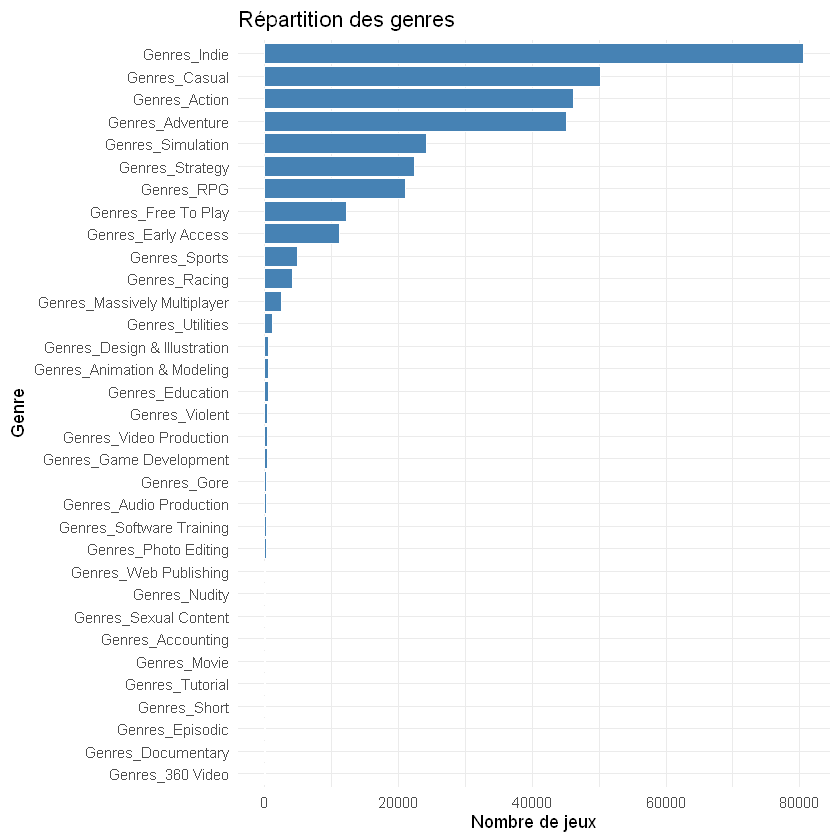

In [25]:
nbr_genre=df_genres %>%
  summarise(across(everything(), sum)) %>%
  pivot_longer(everything(), names_to = "Genre", values_to = "Nombre")

ggplot(nbr_genre,aes(x =reorder(Genre, Nombre) , y = Nombre)) +
  geom_col(fill = "steelblue", color = "white") +
  coord_flip() +
  theme_minimal() +
  labs(
    title = "Répartition des genres",
    x = "Genre",
    y = "Nombre de jeux"
  )

Cet histogramme nous permet de se rendre compte de deux choses: il y a majorité de genre qui ne concentrent la plupart des individus (jeux) avec en tête le Genre Indépendant (Indie). En revanche on se rend aussi compte de la présence de genre niche qui ne sont que très peu représentés.

In [26]:
df_genres_mca <- df_genres %>%
  mutate(across(everything(), as.factor))

  summary(df_genres_mca)

 Genres_Accounting Genres_Animation & Modeling Genres_Audio Production
 0:114483          0:114036                    0:114288               
 1:    30          1:   477                    1:   225               
 Genres_Design & Illustration Genres_Education Genres_Photo Editing
 0:113933                     0:114052         0:114333            
 1:   580                     1:   461         1:   180            
 Genres_Software Training Genres_Utilities Genres_Video Production
 0:114294                 0:113436         0:114175               
 1:   219                 1:  1077         1:   338               
 Genres_Web Publishing Genres_Game Development Genres_Early Access
 0:114401              0:114193                0:103422           
 1:   112              1:   320                1: 11091           
 Genres_Action Genres_Adventure Genres_Casual Genres_Free To Play Genres_Indie
 0:68358       0:69409          0:64321       0:102353            0:33903     
 1:46155       1:45104 

In [27]:
res.mca_genres <- MCA(df_genres_mca, graph = FALSE)

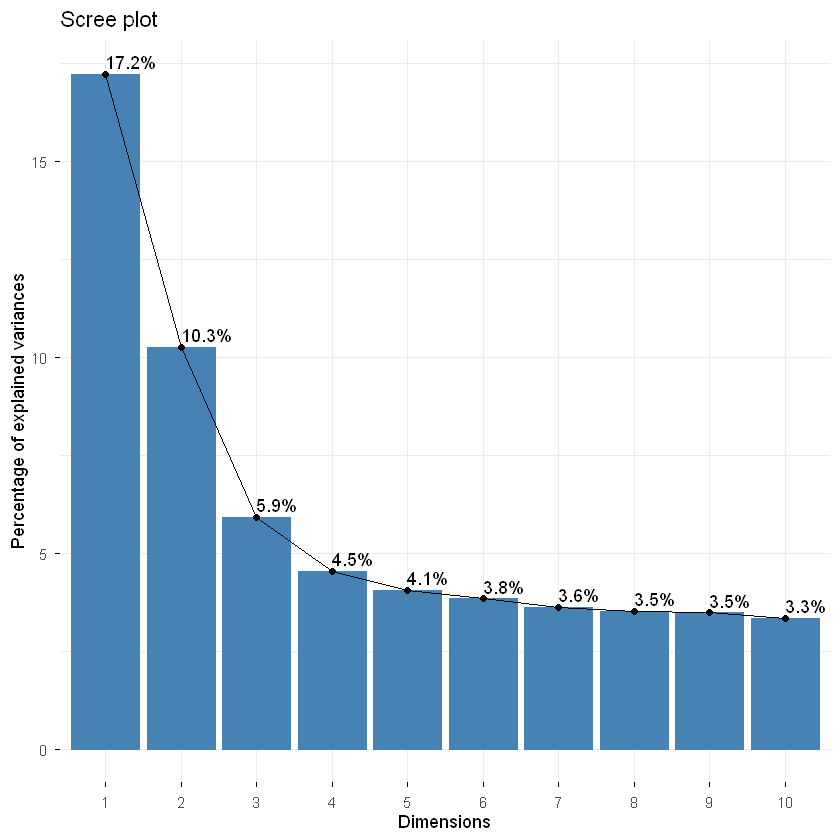

In [28]:
fviz_screeplot(res.mca_genres, addlabels=TRUE)

Les résultats de notre MCA sont intéressant les premiers axes principaux contiennent beaucoup d'informations, Le premier axe 17.2% de la variance expliquée, 10.3% pour la deuxième composante. A partir de la 4ieme composante principale on remarque un plateau on remarque donc un net coude à cet endroit là. On a donc décidé d'étudier nos genres à l'aide des 4 premiers axes de la MCA. 

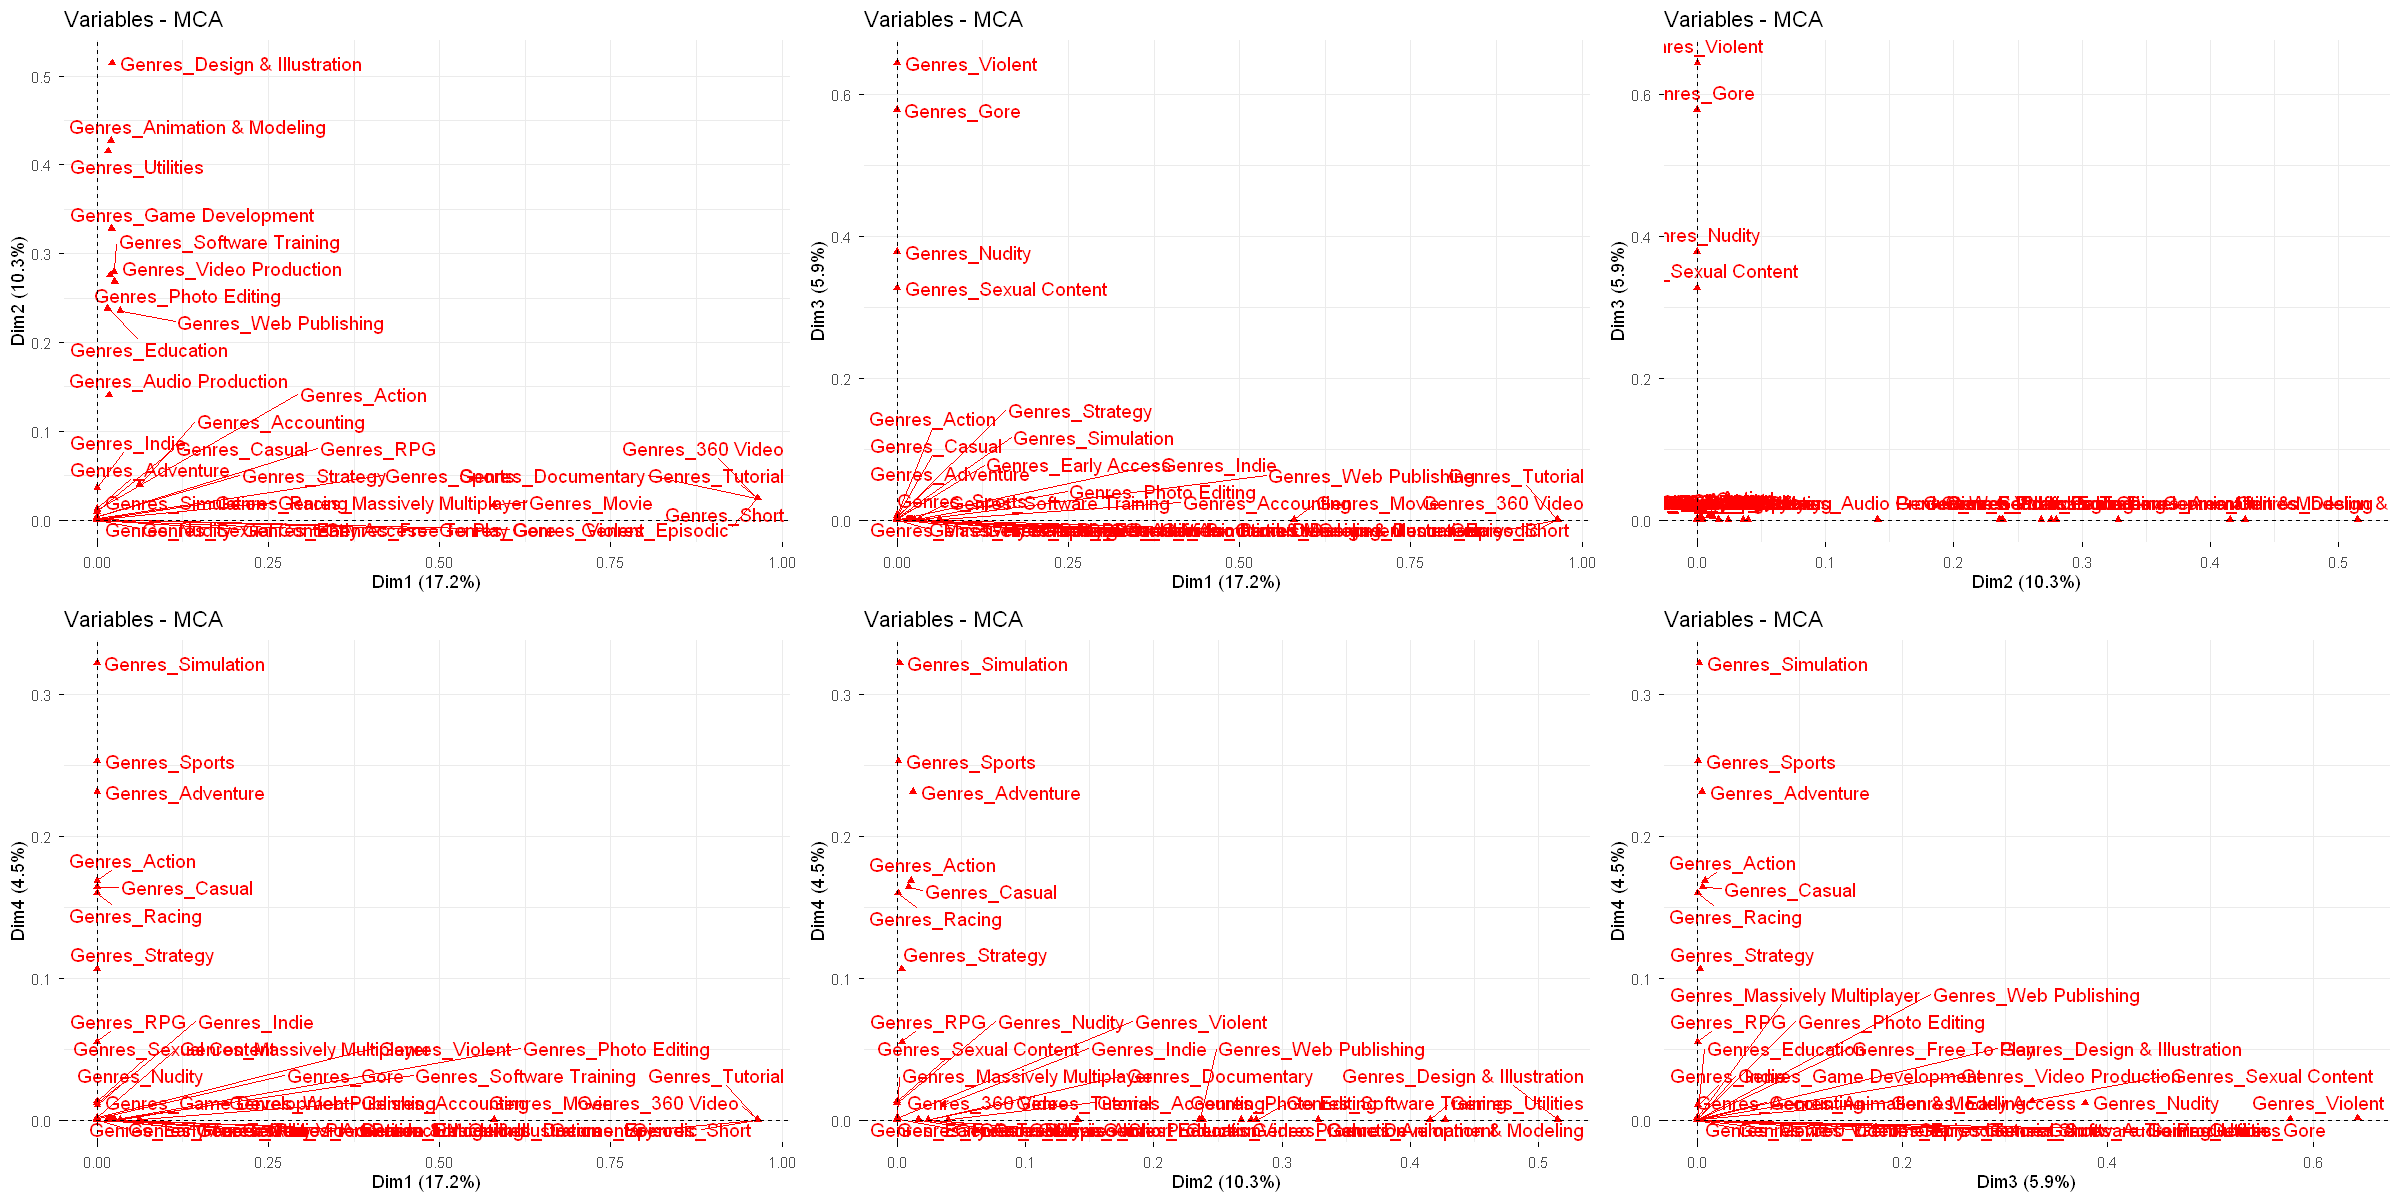

In [29]:
  options(repr.plot.width = 20, repr.plot.height = 10)
g1=fviz_mca_var(res.mca_genres,axes = c(1,2),repel=T,choice = "mca.cor")
g2=fviz_mca_var(res.mca_genres,axes = c(1,3),repel=TRUE,choice = "mca.cor")
g3=fviz_mca_var(res.mca_genres,axes = c(2,3),repel=F,choice = "mca.cor")
g4=fviz_mca_var(res.mca_genres,axes = c(1,4),repel=TRUE,choice = "mca.cor")
g5=fviz_mca_var(res.mca_genres,axes = c(2,4),repel=TRUE,choice = "mca.cor")
g6=fviz_mca_var(res.mca_genres,axes = c(3,4),repel=TRUE,choice = "mca.cor")

grid.arrange(g1,g2,g3,g4,g5,g6,ncol=3)

Sur ces représentations, on peut noter plusieurs choses:
- L'axe 1 semble être expliqué par des genre pour réaliser des vidéos comme *Tutorial*, *360.Video* etc... Ce qui regroupe un type d'applications qui partageraient les mêmes genres.
- On retrouve également  une agglomération de genres au niveau de l'axe 2, en effet, on retrouve plutôt des logiciels de création plutôt que des jeu vidéos.
- Sur l'axe 3 on retrouve un net écart entre des genres dits "mature" comme *Violent*, *Gore*, *Sexual* content ou encore *Nudity*. Ce qui pourra nous être utile pour les regrouper.
- Et enfin sur l'axe 4, expliqué seulement par 4.5% de la variance, on retrouve tous les genres plus "traditionnels" assez mélangé ce qui nous permet d'en déduire que nous ne pouvons pas forcément isoler d'autres groupes de genres ensemble.


Pour confirmer ce que nous venons d'affirmer on peut se pencher sur la contribution aux axes de chaque variable. Nous pouvons l'observer grâce aux histogrammes de la fonction *fviz_contrib*. C'est ce qui est fait dans la cellule suivante pour les quatre premiers axes de la MCA.


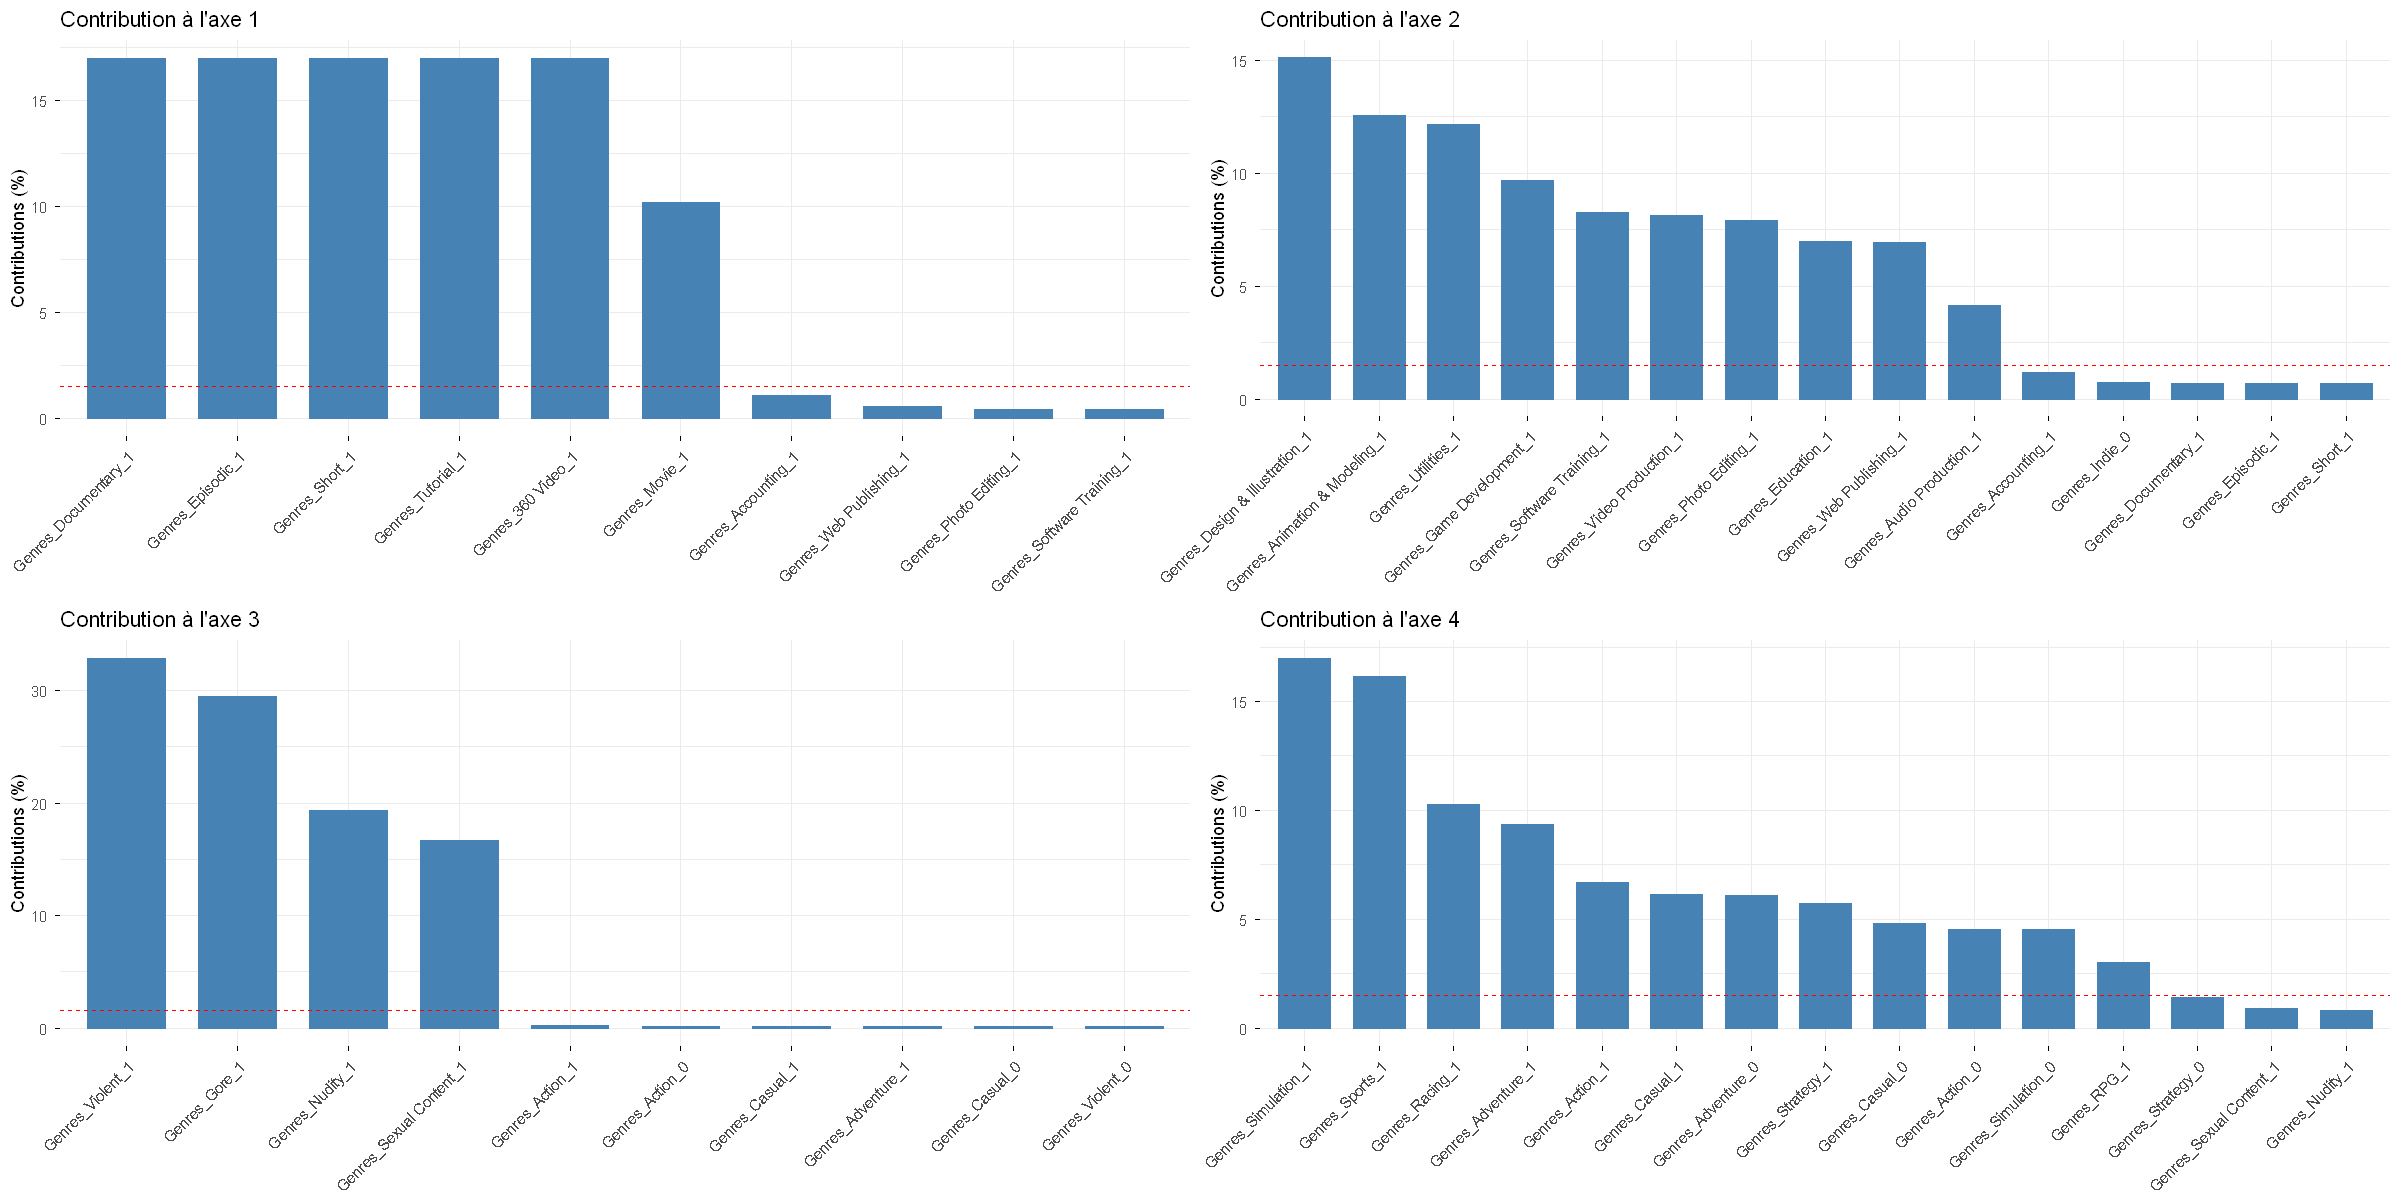

In [153]:
options(repr.plot.width = 20, repr.plot.height = 10)
c1<-fviz_contrib(res.mca_genres,choice = "var",axes = 1,top=10,title ="Contribution à l'axe 1")
c2<-fviz_contrib(res.mca_genres,choice = "var",axes = 2,top=15,title ="Contribution à l'axe 2")
c3<-fviz_contrib(res.mca_genres,choice = "var",axes = 3,top=10,title ="Contribution à l'axe 3")
c4<-fviz_contrib(res.mca_genres,choice = "var",axes = 4,top=15,title ="Contribution à l'axe 4")

grid.arrange(c1,c2,c3,c4,ncol=2)

L'analyse des contributions valide nos précédentes observations graphiques.Nous avons toutefois choisi de ne pas fusionner les genres qui contribuent à la quatrième dimension car elle regroupe tous les genres majeurs restants donc ça n'aurait pas de sens de faire une étude dessus si le nouveau genre ne représentait pas un type de genre précis. Aussi, chacun d'eux possède déjà un volume d'individus suffisant.
Nous avons voulu confirmer nos choix de regroupement en faisant du clustering sur les coordonnées des genres sur l'espace MCA. C'est ce que nous réalisons dans la partie suivante. 

### Clustering CAH sur l'espace de MCA

On va réaliser le clustering ascendant hiérarchique sur les coordonnées de la MCA grâce à la fonction de *factomineR*: *HCPC* qui utilise par défaut la fonction de lien **ward**.


In [34]:
coord_genres <- res.mca_genres$var$coord[,1:4]
res.hcpc_vars <- HCPC(as.data.frame(coord_genres), nb.clust = -1, graph = FALSE)

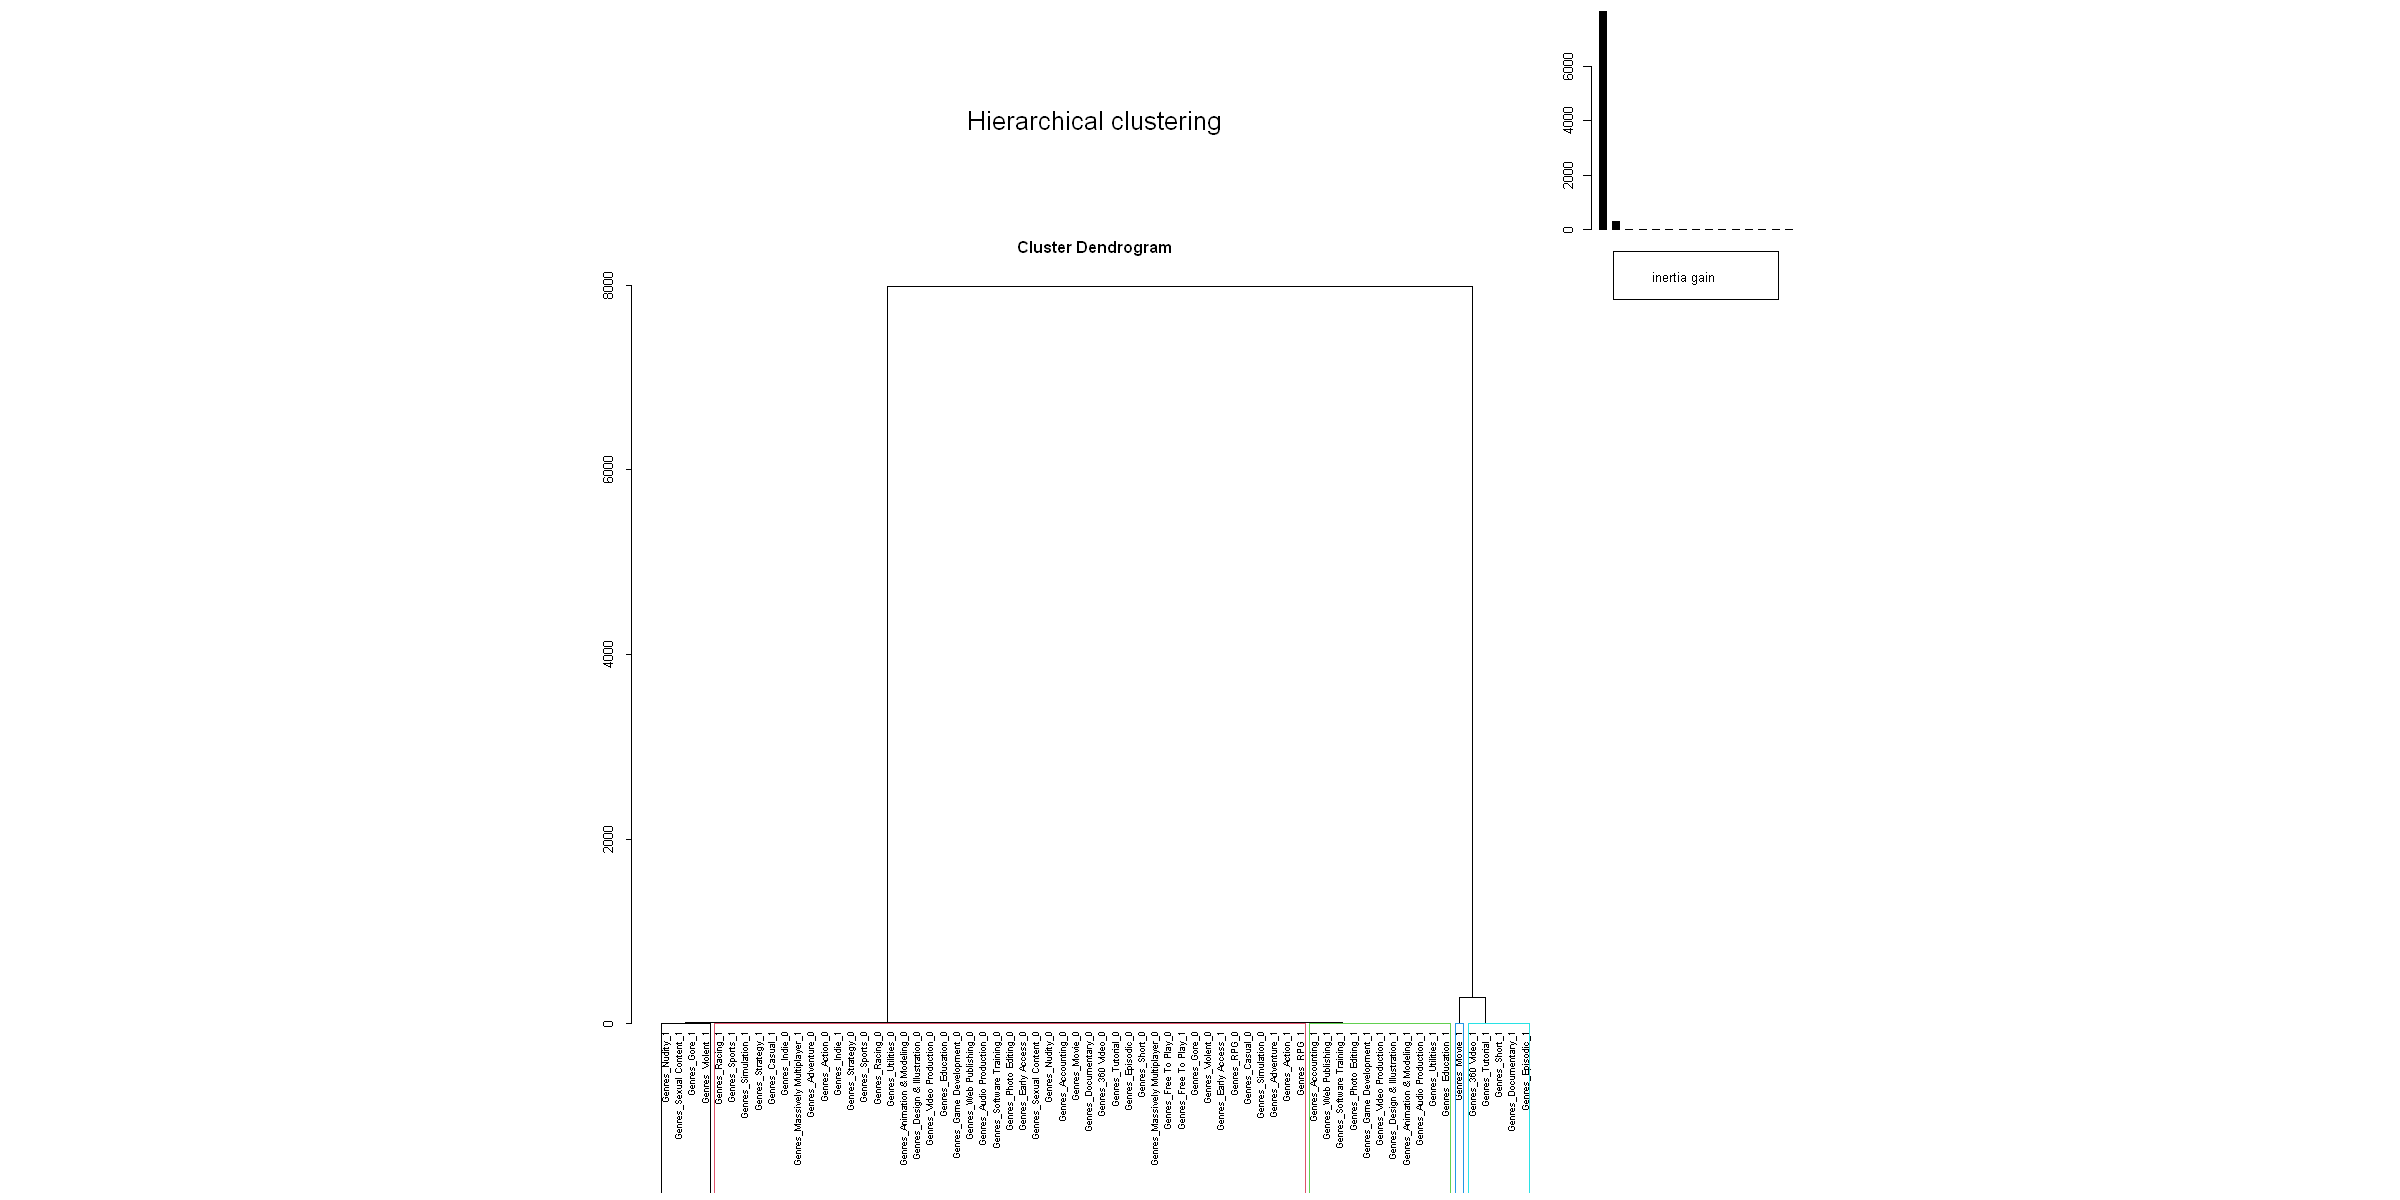

In [35]:
plot(res.hcpc_vars,choice = "tree",cex = 0.7,tcl = -0.3)

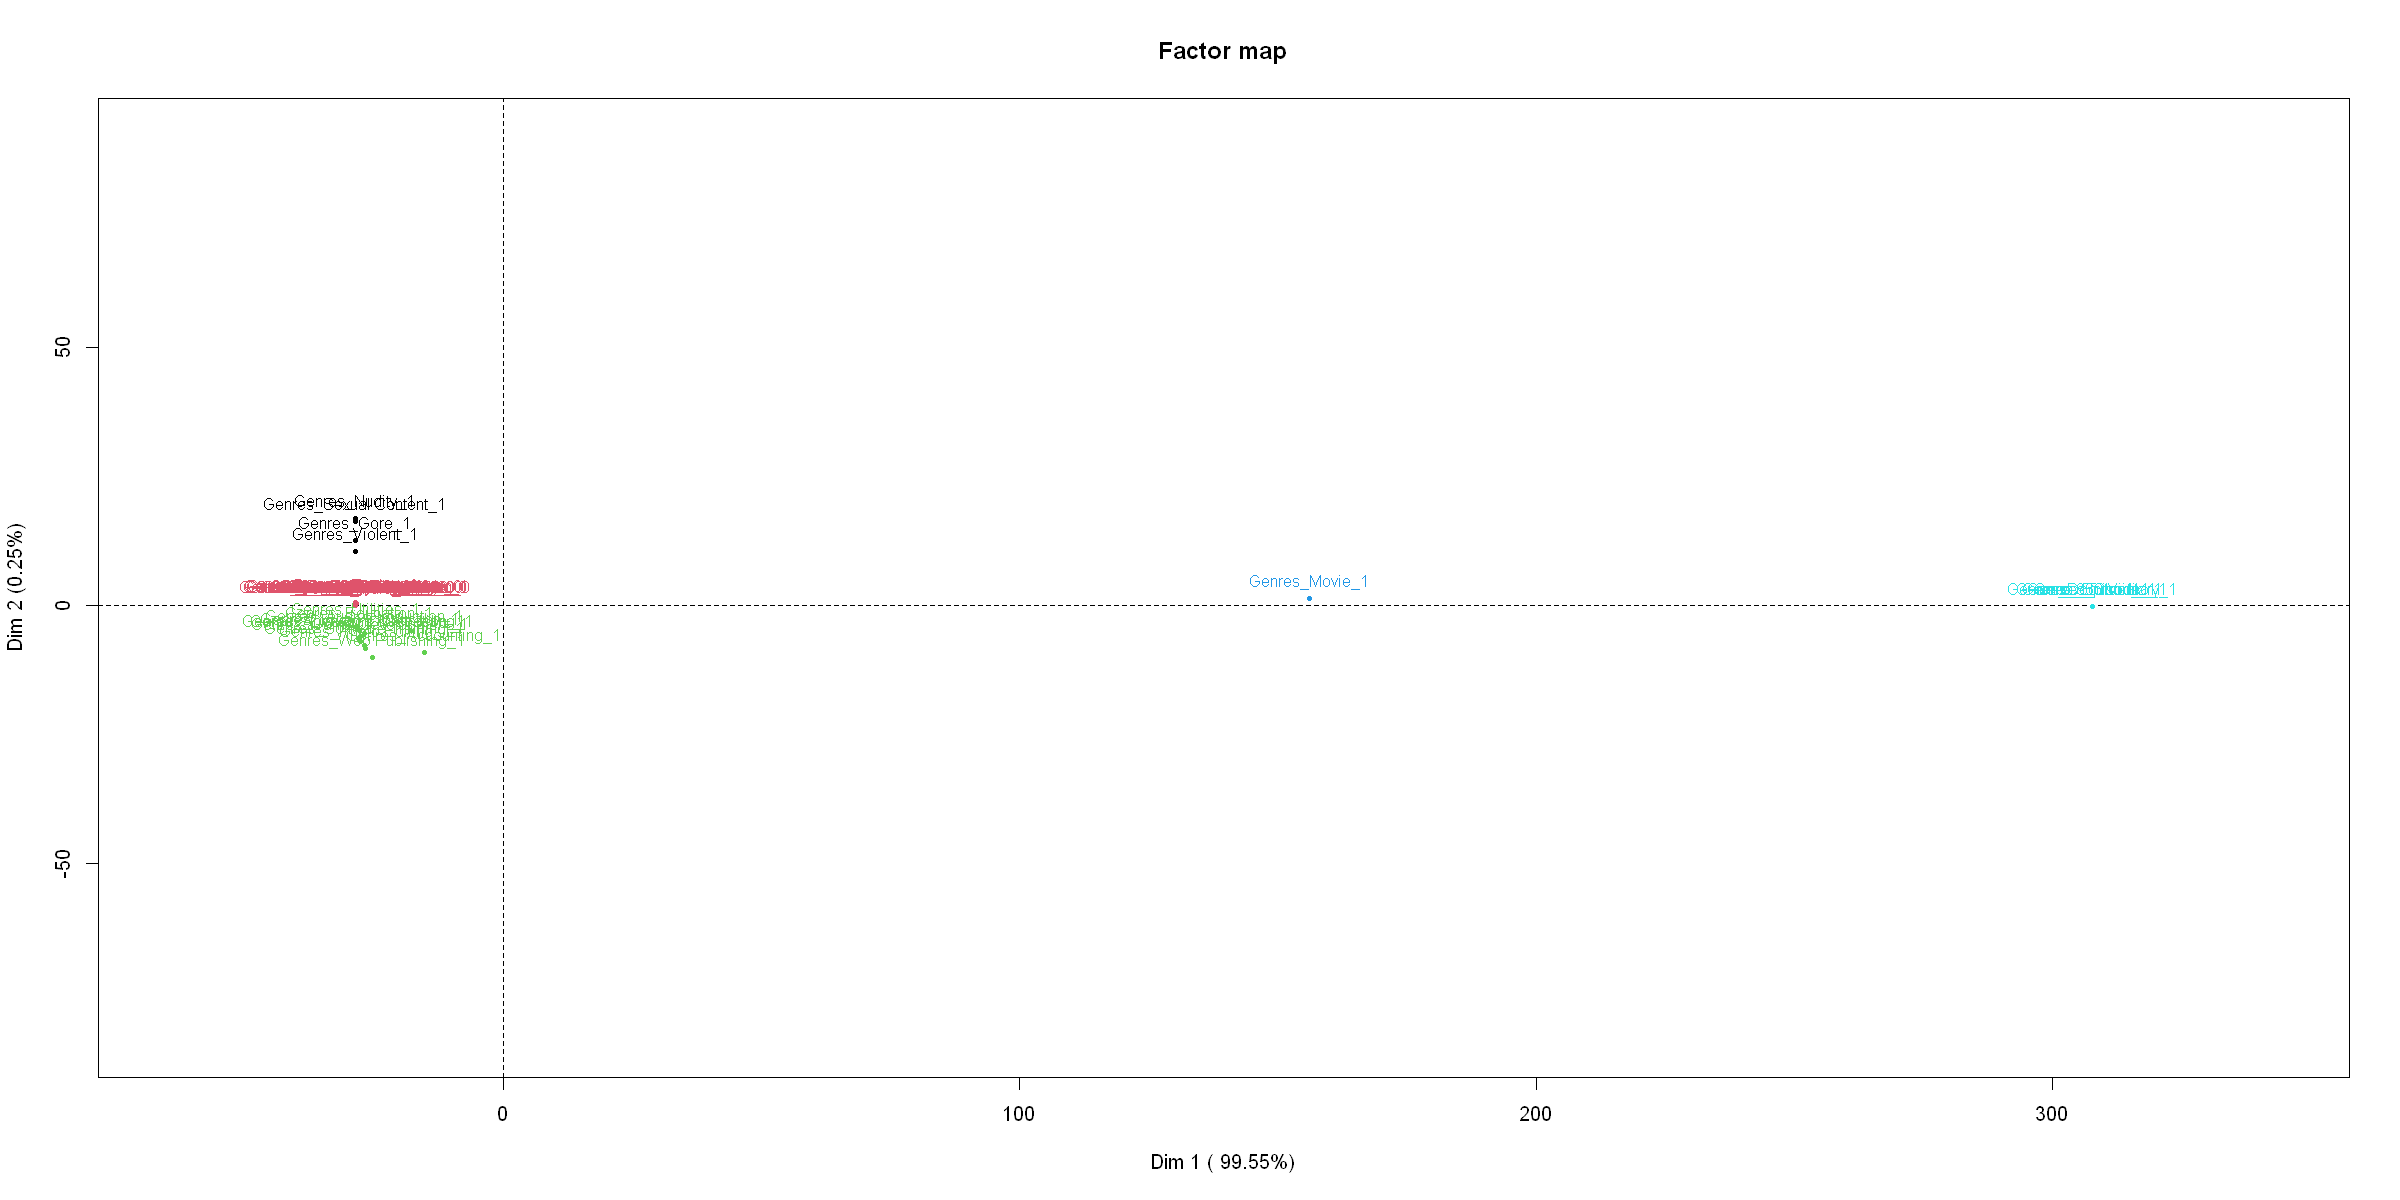

In [36]:
plot(res.hcpc_vars, choice = "map", draw.tree = FALSE)

On voit que la fontion *HCPC* a choisi  5 clusters dont un avec qu'un seul genre (Movie). On décide de le regrouper avec le groupe "Vidéo". Le reste des clusters représente ce que l'on a trouvé avec la MCA.

En résumé, la MCA et ce clustering a révélé que les genres ne sont pas des catégories isolées, mais des groupes liés par des similitudes. Nous avons en évidence trois pôles cohérents : les formats multimédias, les outils de création et les contenus adultes. Ces résultats justifient le regroupement de ces genres en trois nouveaux genres (Video, Outils et Mature). Cette simplification permet de réduire le nombre de variable de 33 à 15 genres.

### Création des nouveaux genres

In [37]:
df_final <- df_one_hot %>%
  mutate(
    # Création du genre "Mature"
    Genre_Mature = if_else(Genres_Gore == "1" |
                           Genres_Nudity == "1"|
                           `Genres_Sexual Content` == "1"|
                           Genres_Violent == "1", "1", "0"),
     # Création du genre "Video" 
     Genre_Video = if_else(Genres_Episodic == "1" |
                           Genres_Documentary == "1"|
                           Genres_Short == "1"|
                           Genres_Movie == "1"|
                           `Genres_360 Video` == "1"|
                           Genres_Tutorial == "1", "1", "0"),
    
    # Création du genre "Outils" 
    Genre_Outils = if_else( `Genres_Video Production` == "1" | 
                           `Genres_Design & Illustration` =="1"|
                           `Genres_Animation & Modeling` == "1" |
                           `Genres_Game Development` == "1"|
                           `Genres_Audio Production` == "1"|
                           `Genres_Photo Editing` == "1"|
                          `Genres_Software Training` == "1"|
                           Genres_Education == "1" |
                           Genres_Utilities == "1" |
                           `Genres_Web Publishing` == "1", "1", "0")
  ) %>%

  mutate(Genre_Mature = as.factor(Genre_Mature),
         Genre_Video = as.factor(Genre_Video),
        Genre_Outils = as.factor(Genre_Outils))


In [38]:
cols_to_remove <- c("Genres_Gore", "Genres_Violent", "Genres_Video Production","Genres_Sexual Content","Genres_Nudity", 
                    "Genres_Design & Illustration", "Genres_Animation & Modeling","Genres_Game Development", 
                    "Genres_Audio Production","Genres_Photo Editing", "Genres_Software Training", 
                    "Genres_Education", "Genres_Utilities", "Genres_Web Publishing","Genres_Episodic",
                   "Genres_Documentary","Genres_Short","Genres_Movie","Genres_360 Video","Genres_Tutorial")

df_mca_new <- df_final %>%
  dplyr::select(-all_of(cols_to_remove))
summary(df_mca_new)

     Name              Release.date    Estimated.owners  Required.age   
 Length:114513      2025-2026:21812   0-20K    :75337   0      :113288  
 Class :character   2024     :18104   0        :13649   17     :   782  
 Mode  :character   2023     :13337   20K-50K  :11395   13     :   175  
                    2022     :11403   50K-100K : 5349   18     :   164  
                    2021     :10441   100K-200K: 3450   16     :    31  
                    2020     : 8746   200K-500K: 2845   10     :    26  
                    (Other)  :30670   (Other)  : 2488   (Other):    47  
    Discount       Windows          Mac          Linux       Metacritic.score
 Min.   :  0.00   False:    44   False:93260   False:98841   Min.   : 0.000  
 1st Qu.:  0.00   True :114469   True :21253   True :15672   1st Qu.: 0.000  
 Median :  0.00                                              Median : 0.000  
 Mean   : 19.62                                              Mean   : 2.703  
 3rd Qu.: 45.00           

In [39]:
df_mca_ready <- df_mca_new%>%  dplyr::select(-Genre_Video) 
df_mca_ready[,-c(1:27,41:42)] <- lapply(df_mca_new[,-c(1:27,41:42)], as.factor)

data_quali_new=df_mca_ready%>%
  dplyr::select(where(is.factor)) 

In [41]:
summary(data_quali_new)

    Release.date    Estimated.owners  Required.age     Windows      
 2025-2026:21812   0-20K    :75337   0      :113288   False:    44  
 2024     :18104   0        :13649   17     :   782   True :114469  
 2023     :13337   20K-50K  :11395   13     :   175                 
 2022     :11403   50K-100K : 5349   18     :   164                 
 2021     :10441   100K-200K: 3450   16     :    31                 
 2020     : 8746   200K-500K: 2845   10     :    26                 
 (Other)  :30670   (Other)  : 2488   (Other):    47                 
    Mac          Linux       Genres_Accounting Genres_Early Access
 False:93260   False:98841   0:114483          0:103422           
 True :21253   True :15672   1:    30          1: 11091           
                                                                  
                                                                  
                                                                  
                                              

Même en réduisant le nombre de genres la MCA entre toutes les variables qualitatives reste très peu interprétable. C'est pour cela que nous avons etudié la relation entre les genres et les variables qualitatives une à une grâce à une CA (Correspondance Analysis).

### CA Genres-Realease.date

Pour cela, nous allons réaliser une table de contingence croisant les genres et les années de sortie. Initialement, nous avions mené cette analyse avec l'ensemble des genres. Cependant, la présence de catégories sous-représentées étirait nos axes factoriels, ce qui masquait les véritables relations sous-jacentes. Nous avons donc choisi de réaliser notre CA en excluant les genres *Mature*, *Video* et *Accounting*.

In [42]:
tab_contingence <- data_quali_new %>%
  group_by(Release.date) %>%
  summarise(across(starts_with("Genre"), 
                   ~ sum(as.numeric(as.character(.)), na.rm = TRUE))) %>%
  as.data.frame()

rownames(tab_contingence) <- tab_contingence$Release.date
tab_contingence$Release.date <- NULL

tab_filtre <- tab_contingence[, !(colnames(tab_contingence) %in% c("Genre_Mature", "Genres_Accounting")), drop = FALSE]

Pour savoir si les variables sont dépendantes et ainsi savoir si notre analyse par correspondance à du sens d'être fait nous réalisons un test d'indépendance du Khi-deux.

In [43]:
test_khi2 <- chisq.test(tab_filtre)
print(test_khi2)



	Pearson's Chi-squared test

data:  tab_filtre
X-squared = 3197.2, df = 144, p-value < 2.2e-16



On obtient une p-value $< 2.2 \times 10^{-16}$, ce qui indique que les genres et les dates de sortie sont statistiquement liés ; réaliser une CA est donc justifié. Avant de passer à la réduction de dimensions, nous pouvons étudier les résidus du test, ce qui nous donnera un avant-goût des résultats de la CA.

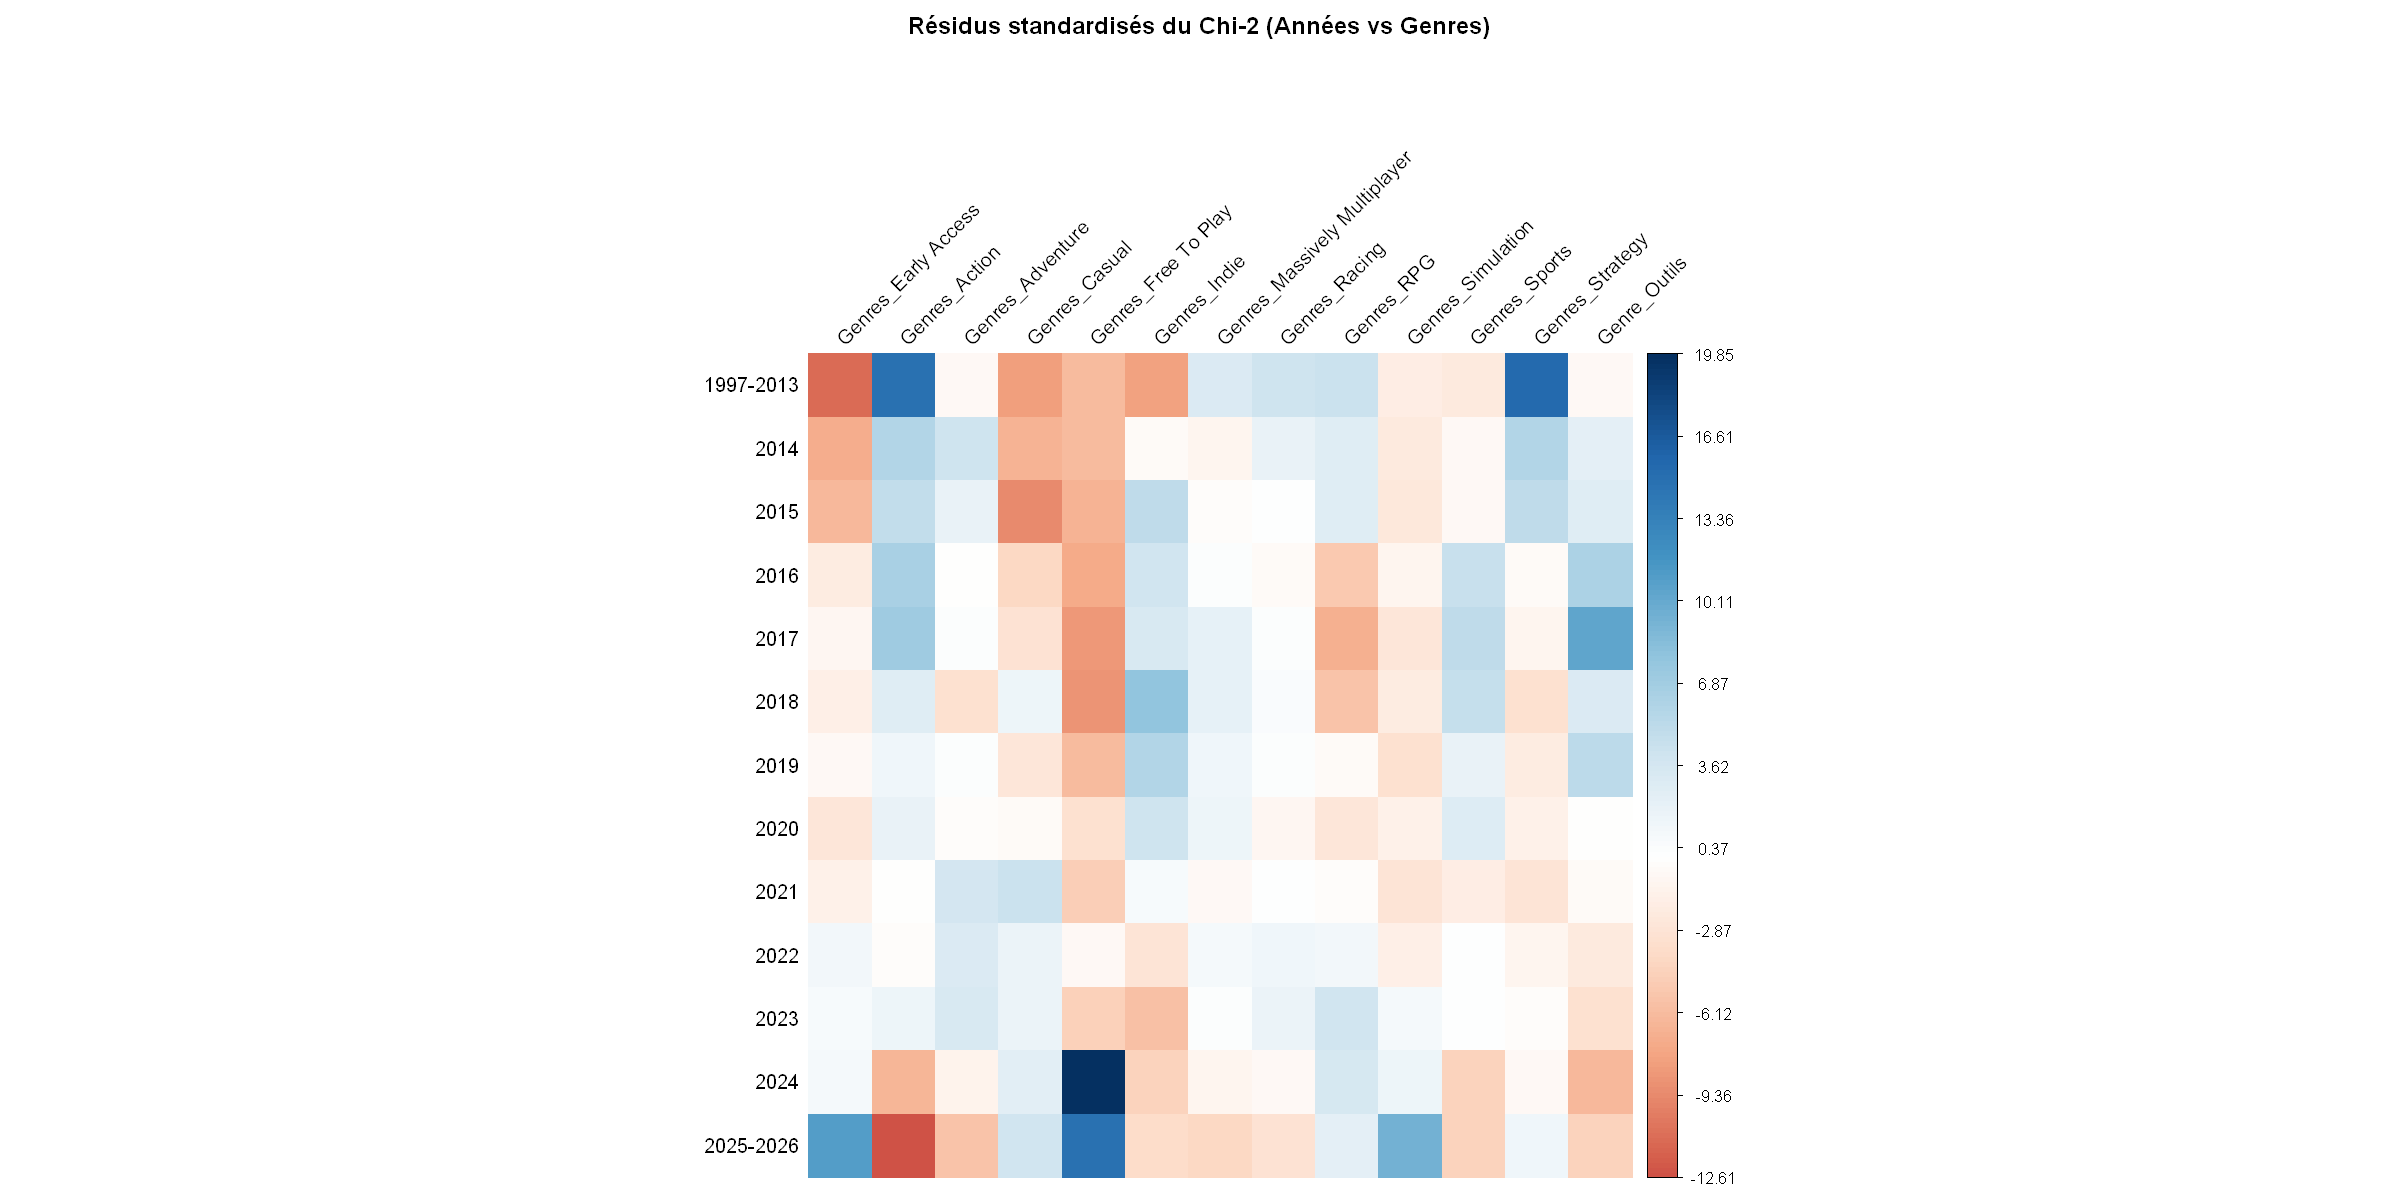

In [44]:
residus <- test_khi2$stdres
corrplot(residus, 
         is.cor = FALSE,method = "color",tl.srt = 45,tl.col = "black",mar = c(0,0,2,0),title = "Résidus standardisés du Chi-2 (Années vs Genres)")

Pour interpréter ces résidus, il faut regarder l'intensité des couleurs présentes. Plus la case est bleu foncé, plus l'association est positive (sur-représentation) et, inversement, plus la case est orange, plus la sous-représentation est marquée. Les conclusions sur les résidus sont détaillées dans la cellule Markdown suivante avec celles de la CA.

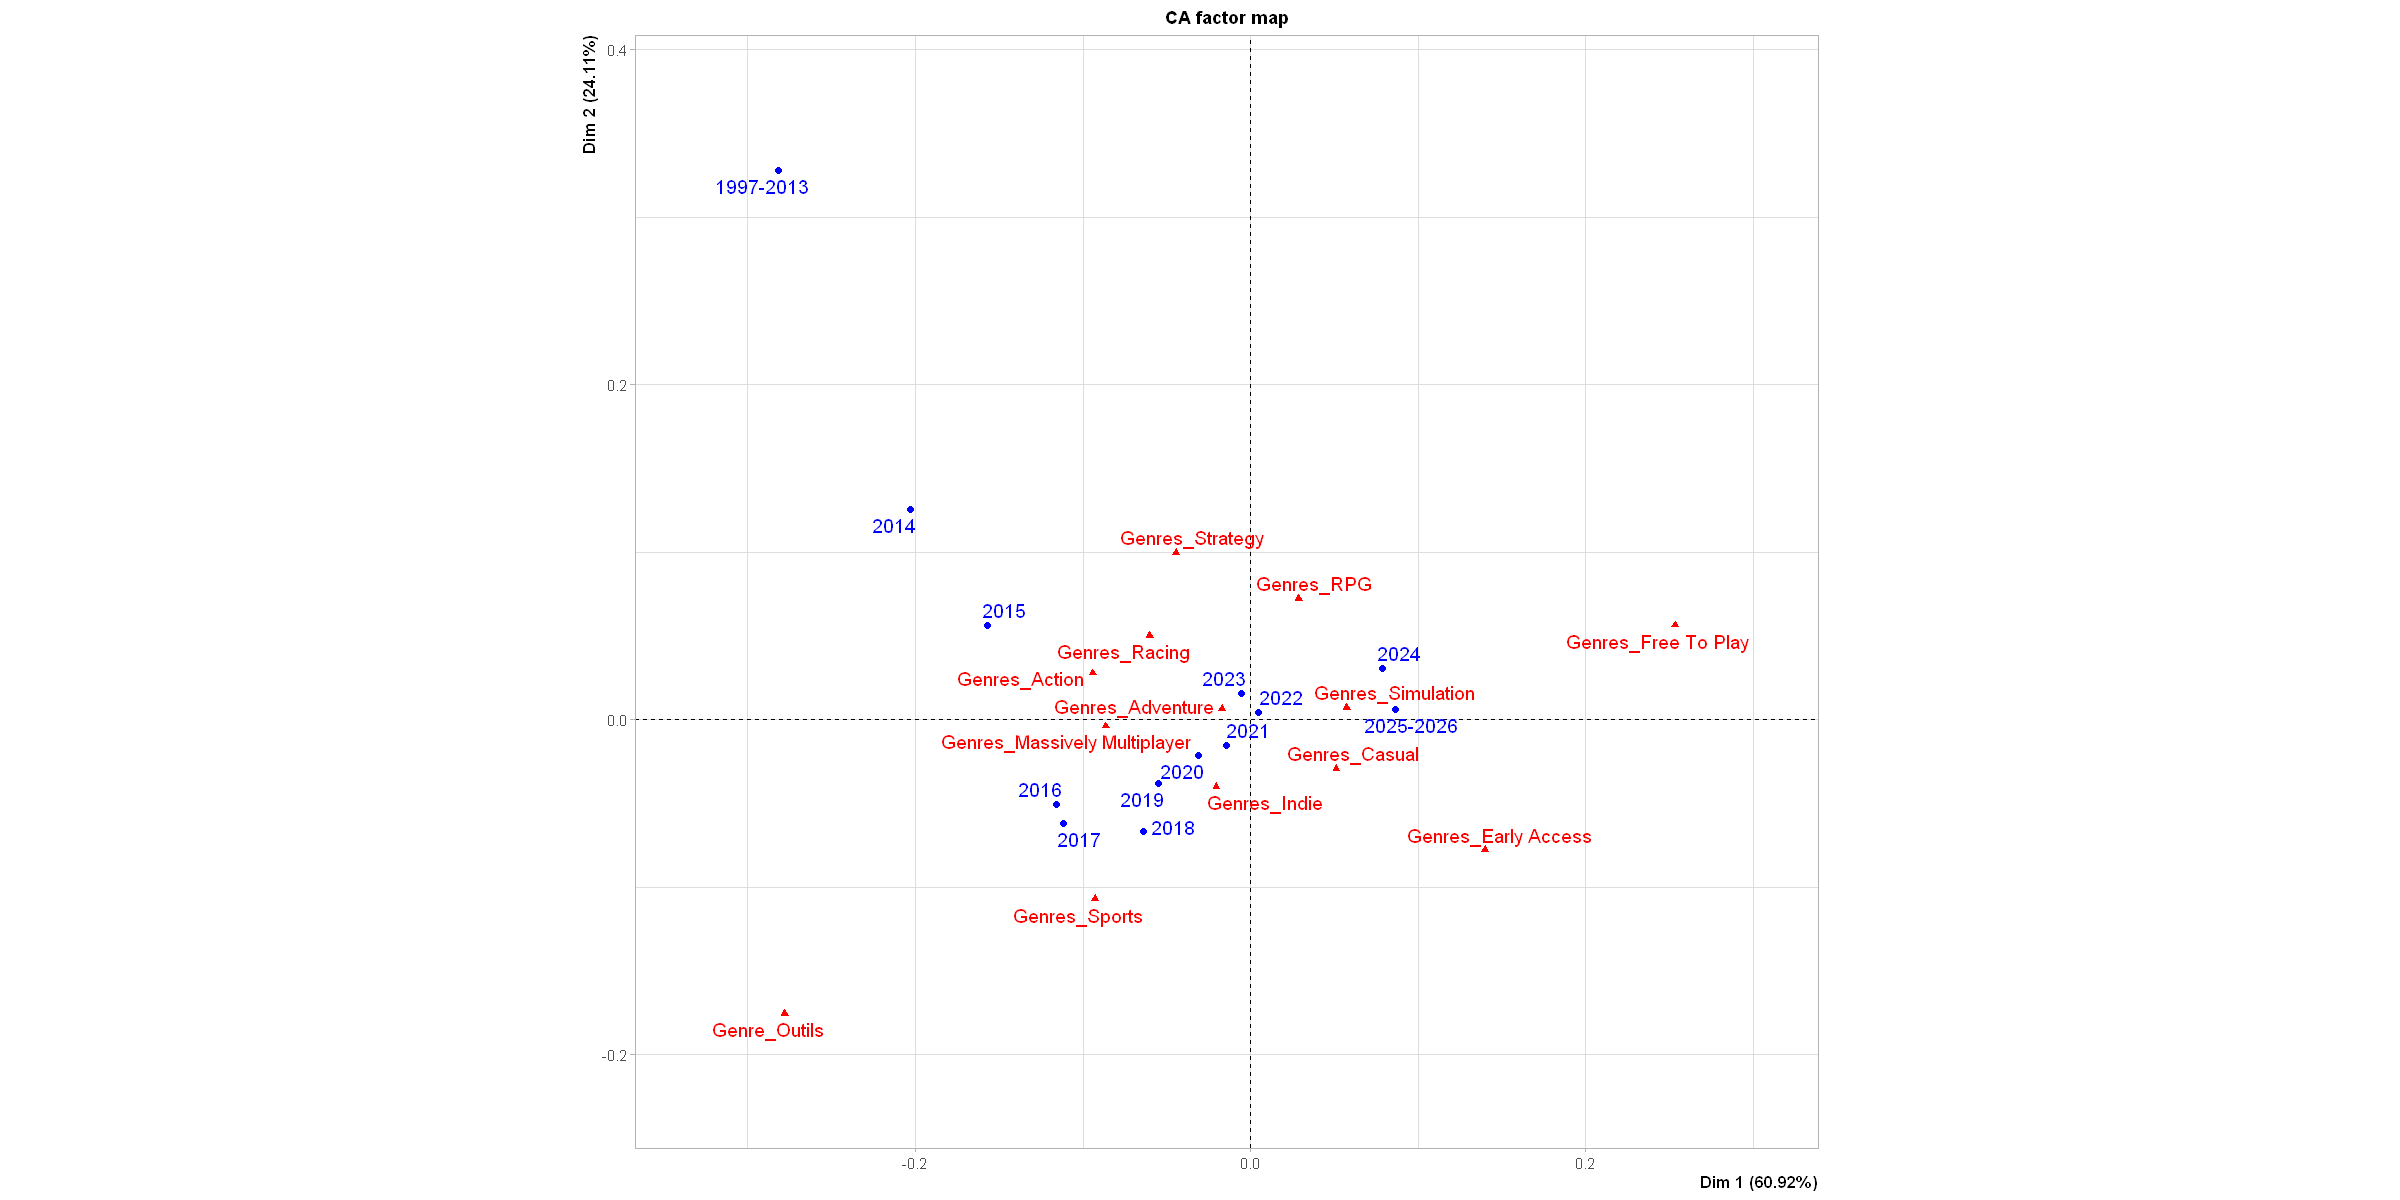

In [45]:
res.ca_zoom <- CA(tab_filtre)

L’analyse des résidus du test d'indépendance khi-deux et du graphe de l'analyse par correspondance montre que la manière dont les jeux sont publiés sur Steam a bien changé en 20 ans :

**1997 - 2013**: Durant cette période, la majorité des nouveaux jeux publiés appartiennent aux genres *Action* et *Strategy*. Ces catégories présentent les résidus les plus élevés, ce qui montre que la publication se concentrait alors sur ces genres de jeux traditionnels.

**2016 - 2020**: On observe un changement avec une augmentation nette de la publication de jeux Indie (indépendants). C'est aussi à ce moment que la publication de logiciels et outils se distingue le plus, montrant que Steam a commencé à publier autre chose que de simples jeux vidéo.

**2024 - 2026**: De nos jours, la publication est massivement dominée par le *Free to Play* et l'*Early Access*. Le résidu pour le *Free to Play* atteint son maximum en 2024 (19.85), prouvant que ce modèle de publication est devenu prioritaire. Cela permet de publier des jeux gratuitement pour attirer beaucoup de monde, ou de les sortir avant qu'ils ne soient finis (*Early Access*) afin de limiter les risques financiers.

### CA Genres-Estimated.owners

Nous allons aussi réaliser les mêmes étapes entre le nombre de possesseurs du jeu et les genres: c'est à dire, faire un test d'indépendance du khi-deux pour voir si les variables sont bien dépendantes pour justifier notre analyse par corréspondance. Pour cette analyse, nous l'avons réalisé avec le jeu de donnée avec tous les genres. Cependant, le Genre *Free_To Play* présentait un comportement extrême qui écrasait le reste du plan factoriel et empêchait de distinguer les tendances secondaires. Nous l'avons donc retirée pour mettre en évidence les relations plus subtiles entre les autres variables

In [46]:
tab_contingence_owners <- data_quali_new %>%
  group_by(Estimated.owners) %>%
  summarise(across(starts_with("Genre"), 
                   ~ sum(as.numeric(as.character(.)), na.rm = TRUE))) %>%
  as.data.frame()%>%
  dplyr::select(-`Genres_Free To Play`)

# Définition des noms de lignes et nettoyage
rownames(tab_contingence_owners) <- tab_contingence_owners$Estimated.owners
tab_contingence_owners$Estimated.owners <- NULL

In [47]:
test_khi2_owners <- chisq.test(tab_contingence_owners)
print(test_khi2_owners)


	Pearson's Chi-squared test

data:  tab_contingence_owners
X-squared = 4771, df = 169, p-value < 2.2e-16



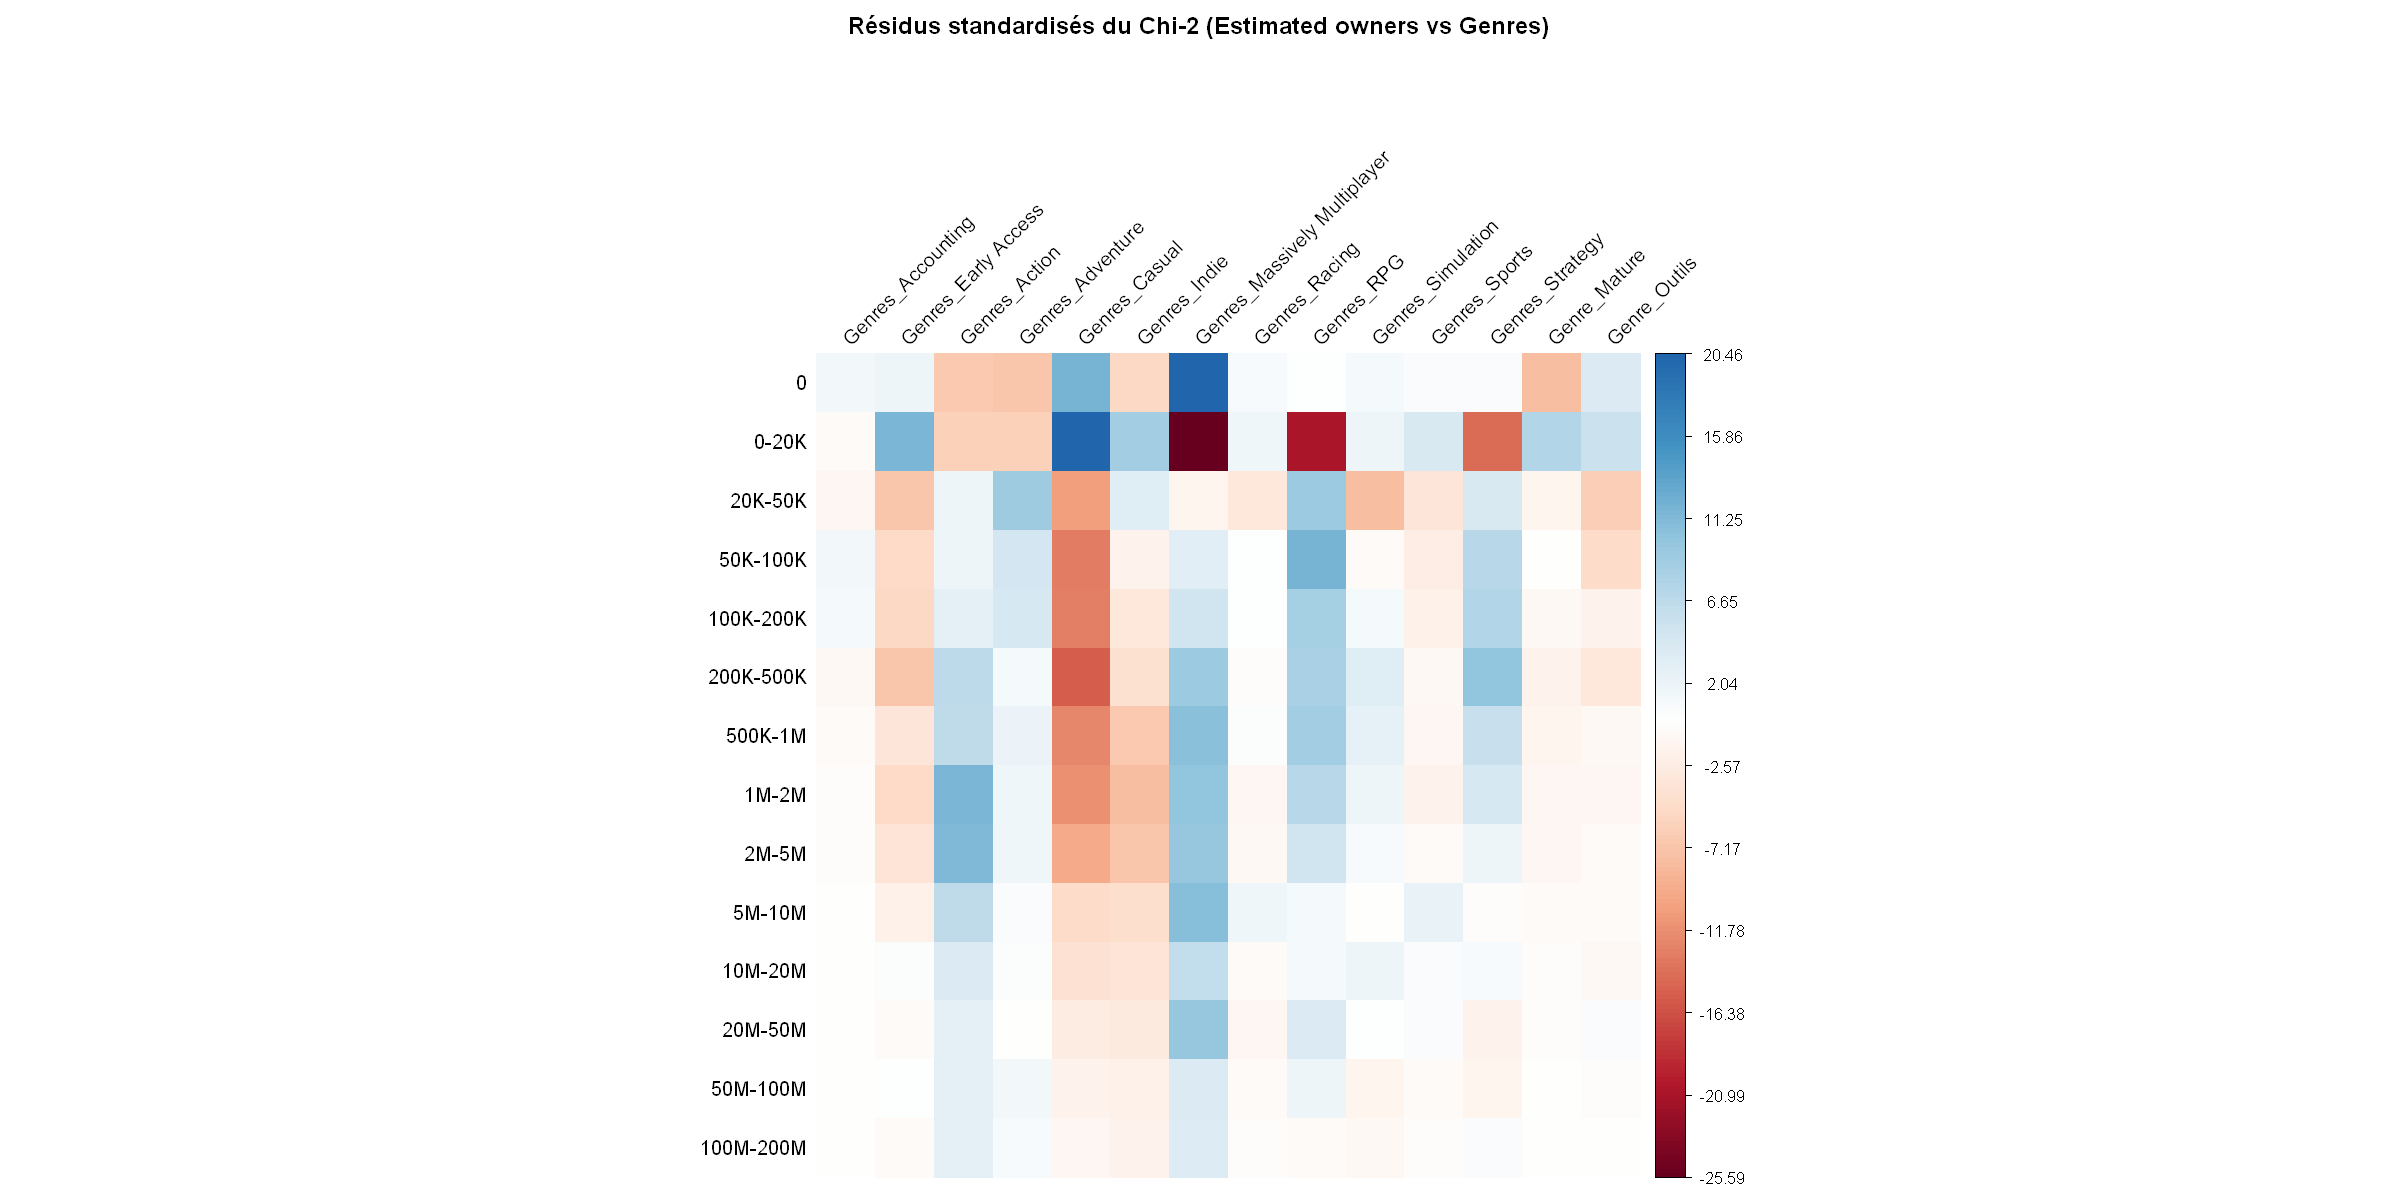

In [48]:
residus_owners <- test_khi2_owners$stdres
corrplot(residus_owners, 
         is.cor = FALSE,method = "color",tl.srt = 45,tl.col = "black"
         ,mar = c(0,0,2,0),title = "Résidus standardisés du Chi-2 (Estimated owners vs Genres)")

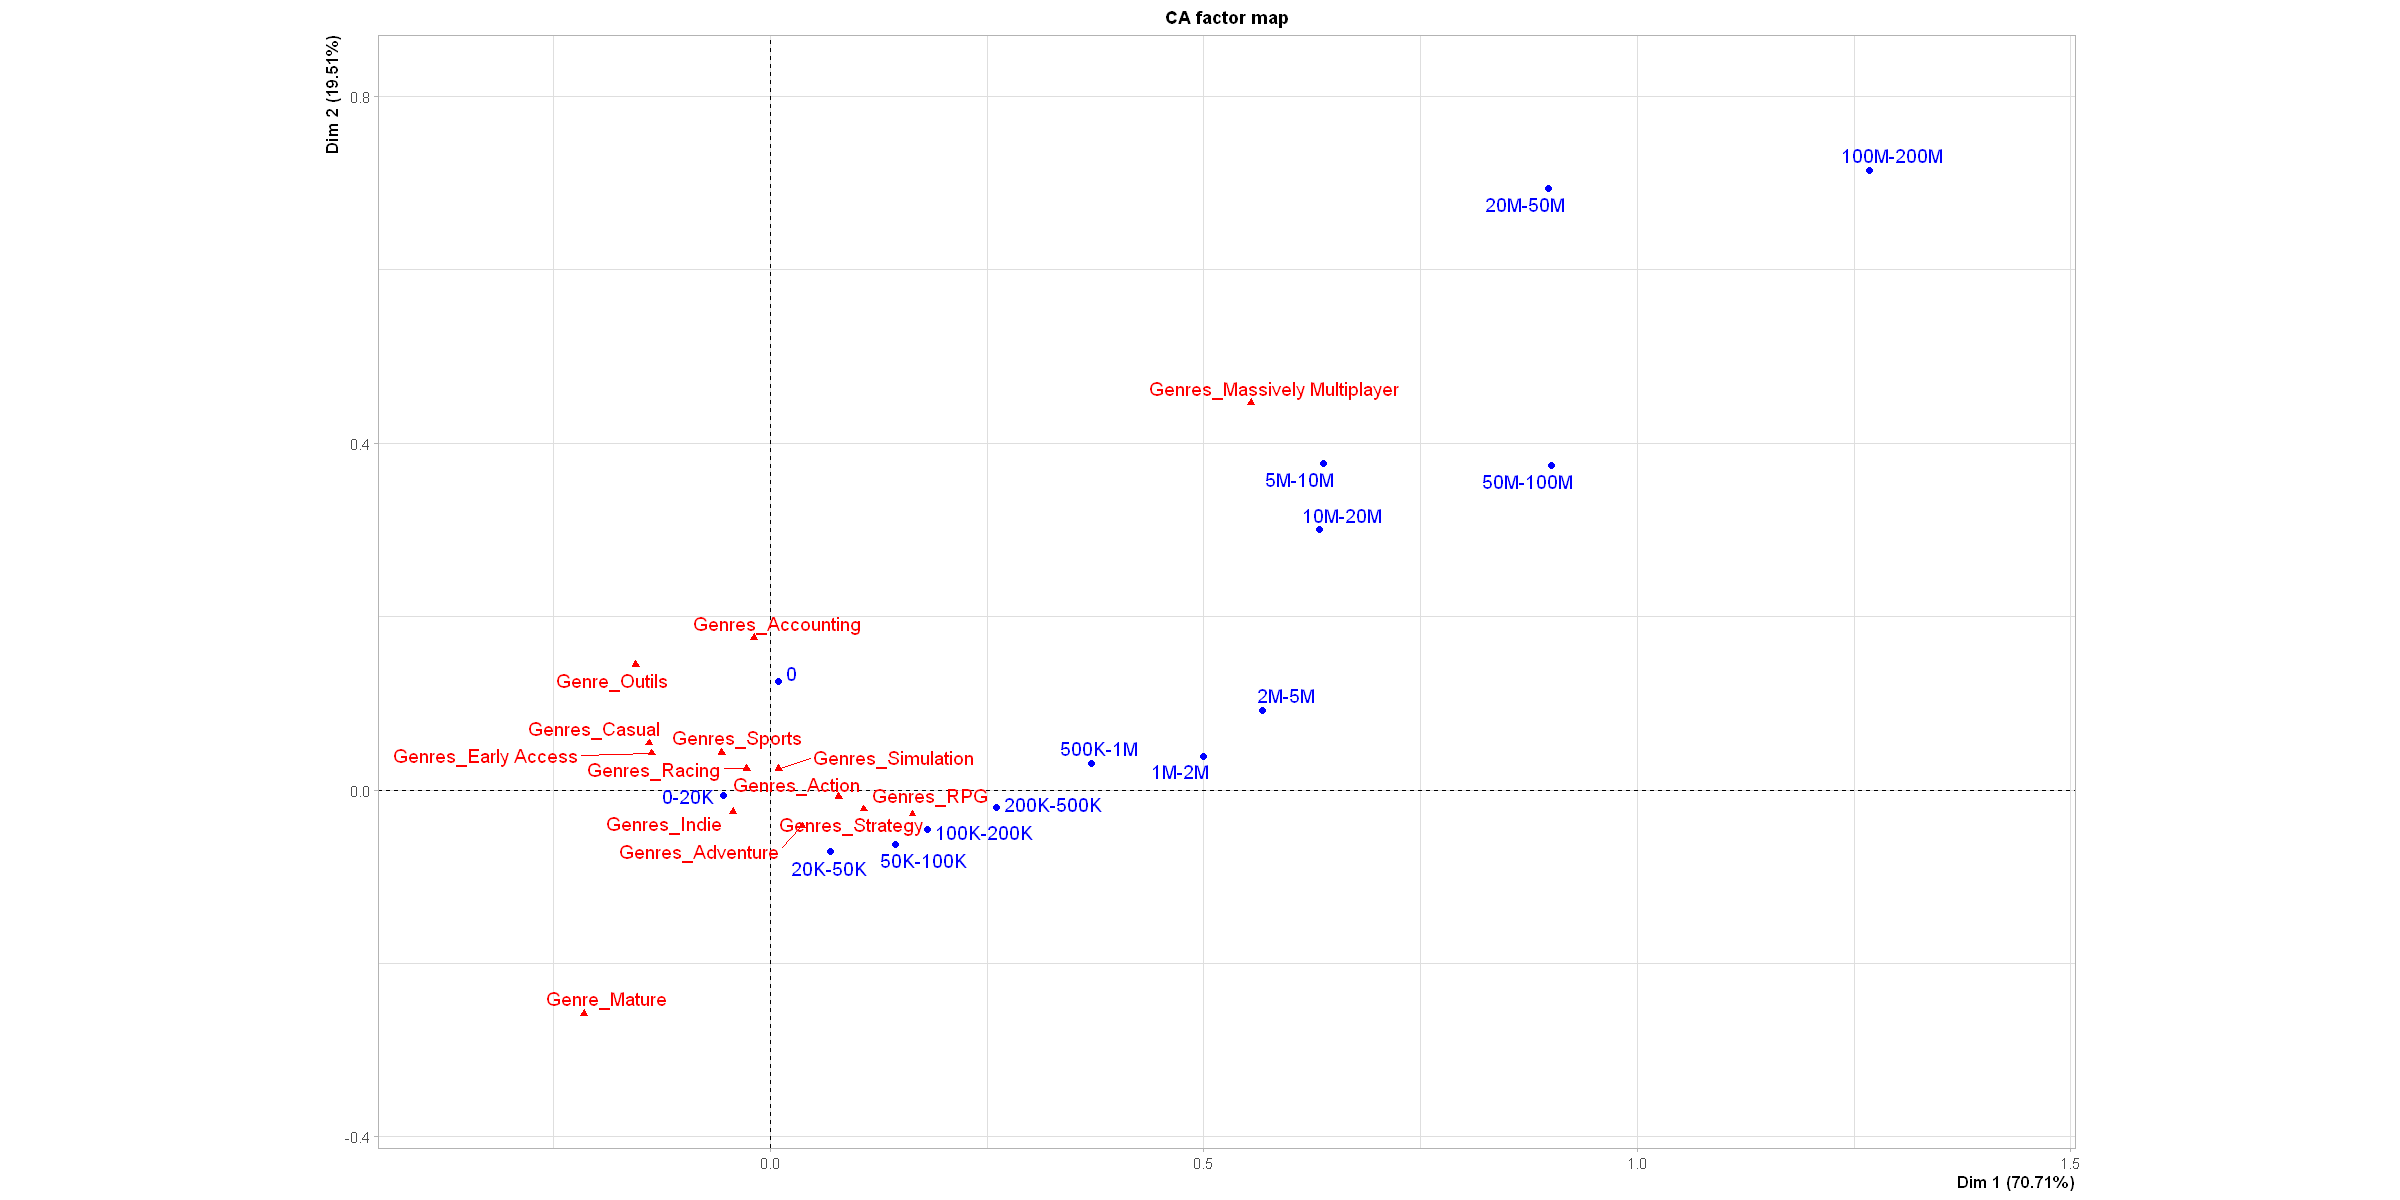

In [49]:
res.ca_age<-CA(tab_contingence_owners)

Le retrait du genre *Free_To Play* révèle que les volumes inférieurs à 50K possesseurs sont portés par les genres *Indie*, *Adventure* et *Casual*. À l'inverse, les succès massifs (au-delà de 1M de possesseurs) sont la spécificité des genres *Action*, *RPG* et *Massively Multiplayer*.

### CA Genres-Required.Age

Nous allons réaliser encore une fois le même processus entre la restriction d'age et les genres.

In [50]:
tab_contingence_age <- data_quali_new %>%
  group_by(Required.age) %>%
  summarise(across(starts_with("Genre"), 
                   ~ sum(as.numeric(as.character(.)), na.rm = TRUE))) %>%
  as.data.frame()

# Définition des noms de lignes et nettoyage
rownames(tab_contingence_age) <- tab_contingence_age$Required.age
tab_contingence_age$Required.age <- NULL


In [51]:
test_khi2_age <- chisq.test(tab_contingence_age)
print(test_khi2_age)


	Pearson's Chi-squared test

data:  tab_contingence_age
X-squared = 1844.8, df = 196, p-value < 2.2e-16



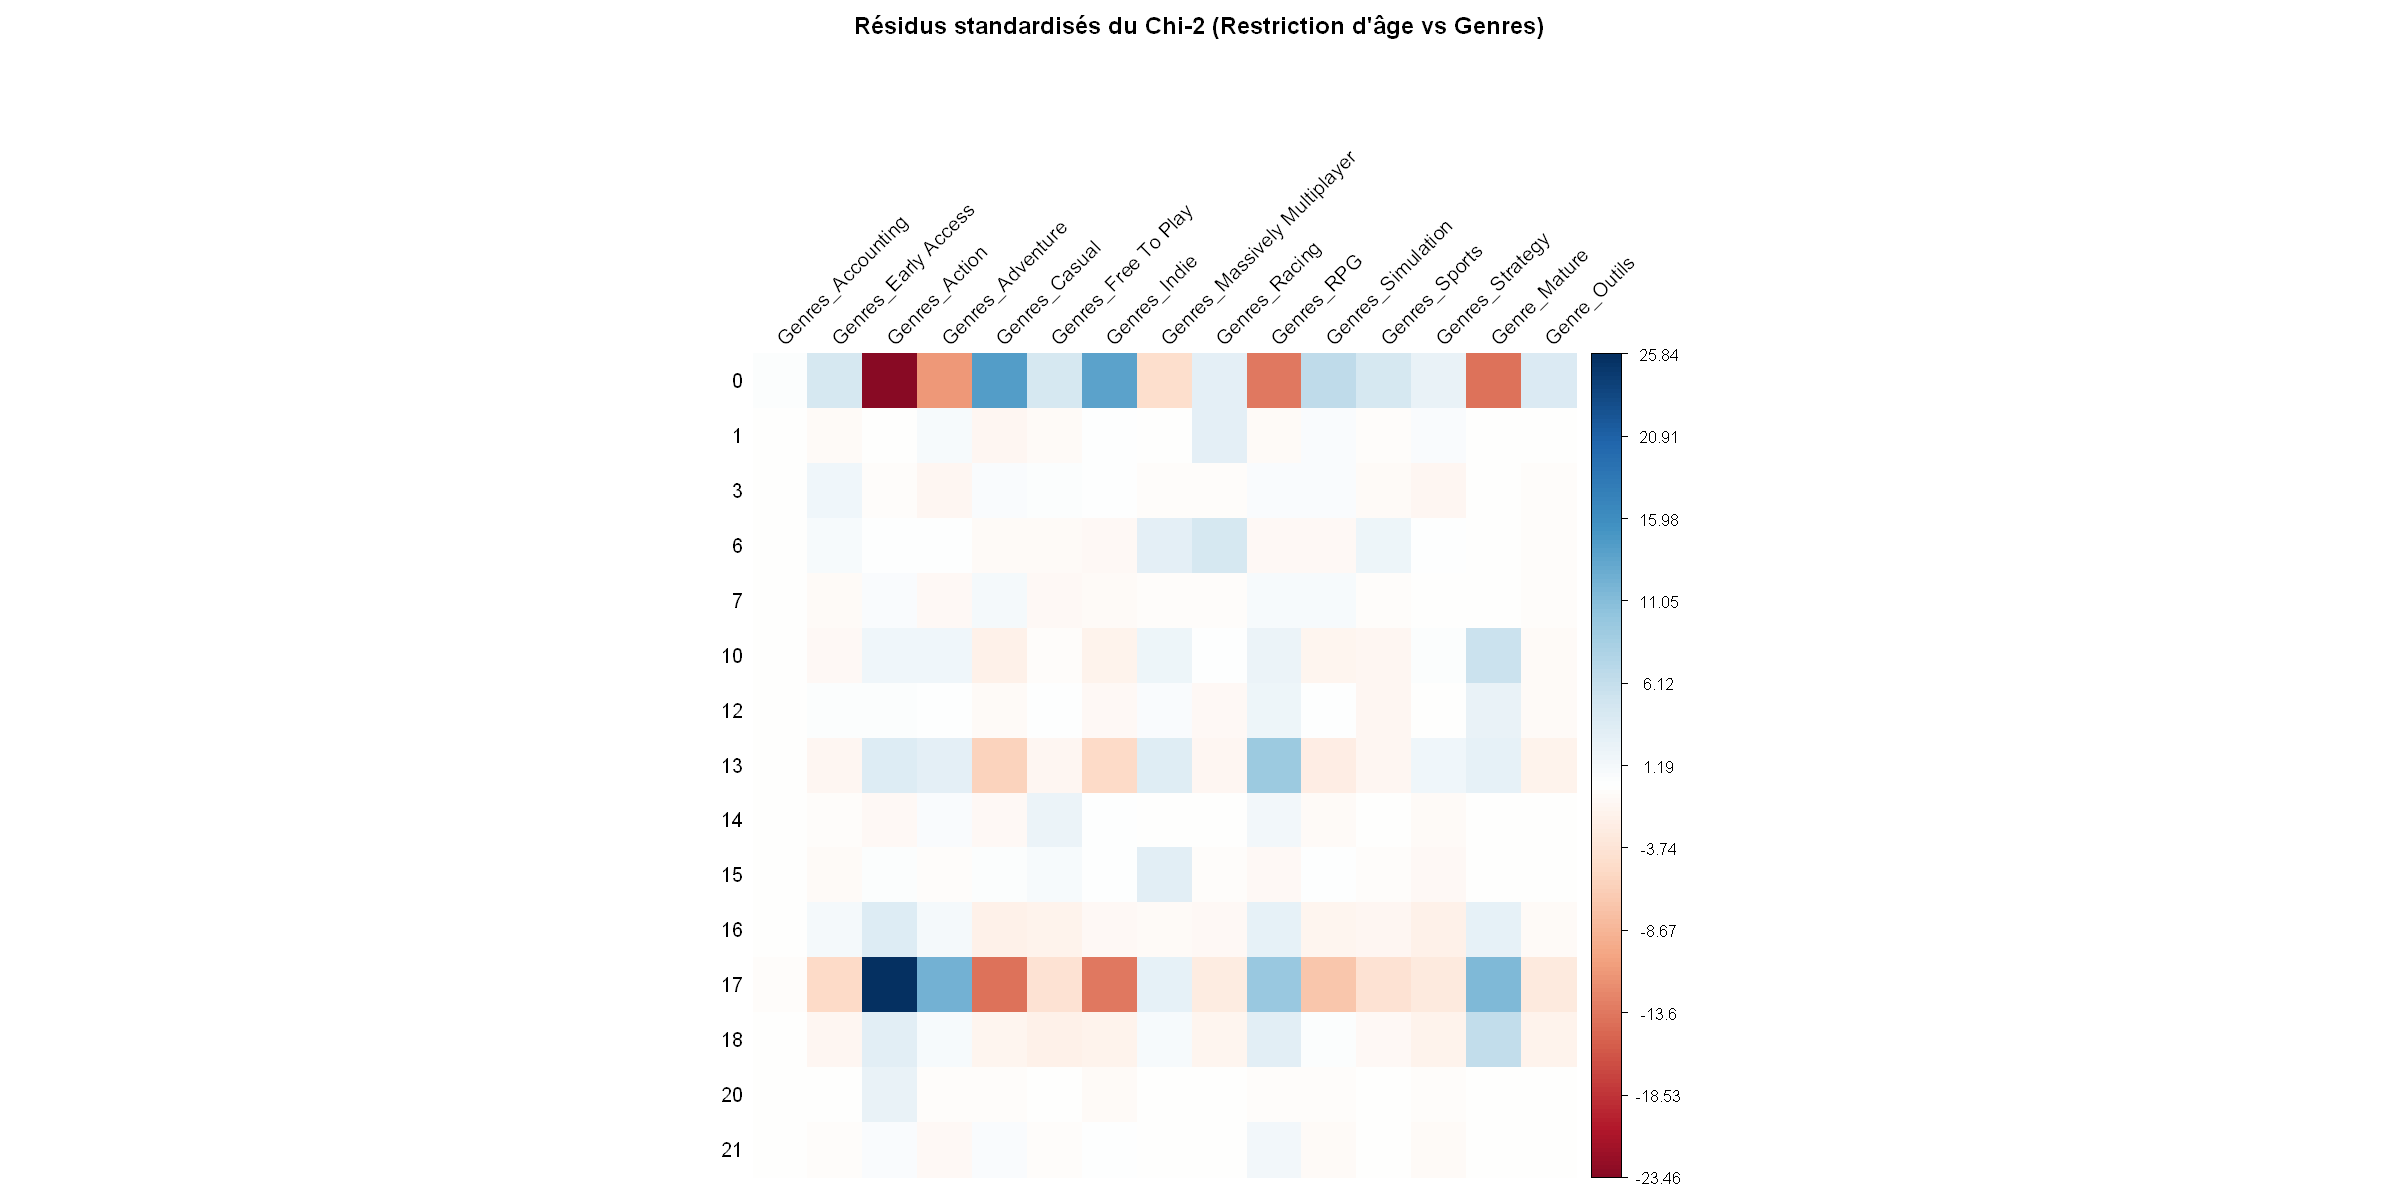

In [52]:
residus_age <- test_khi2_age$stdres
corrplot(residus_age, 
         is.cor = FALSE,method = "color",tl.srt = 45,tl.col = "black"
         ,mar = c(0,0,2,0),title = "Résidus standardisés du Chi-2 (Restriction d'âge vs Genres)")

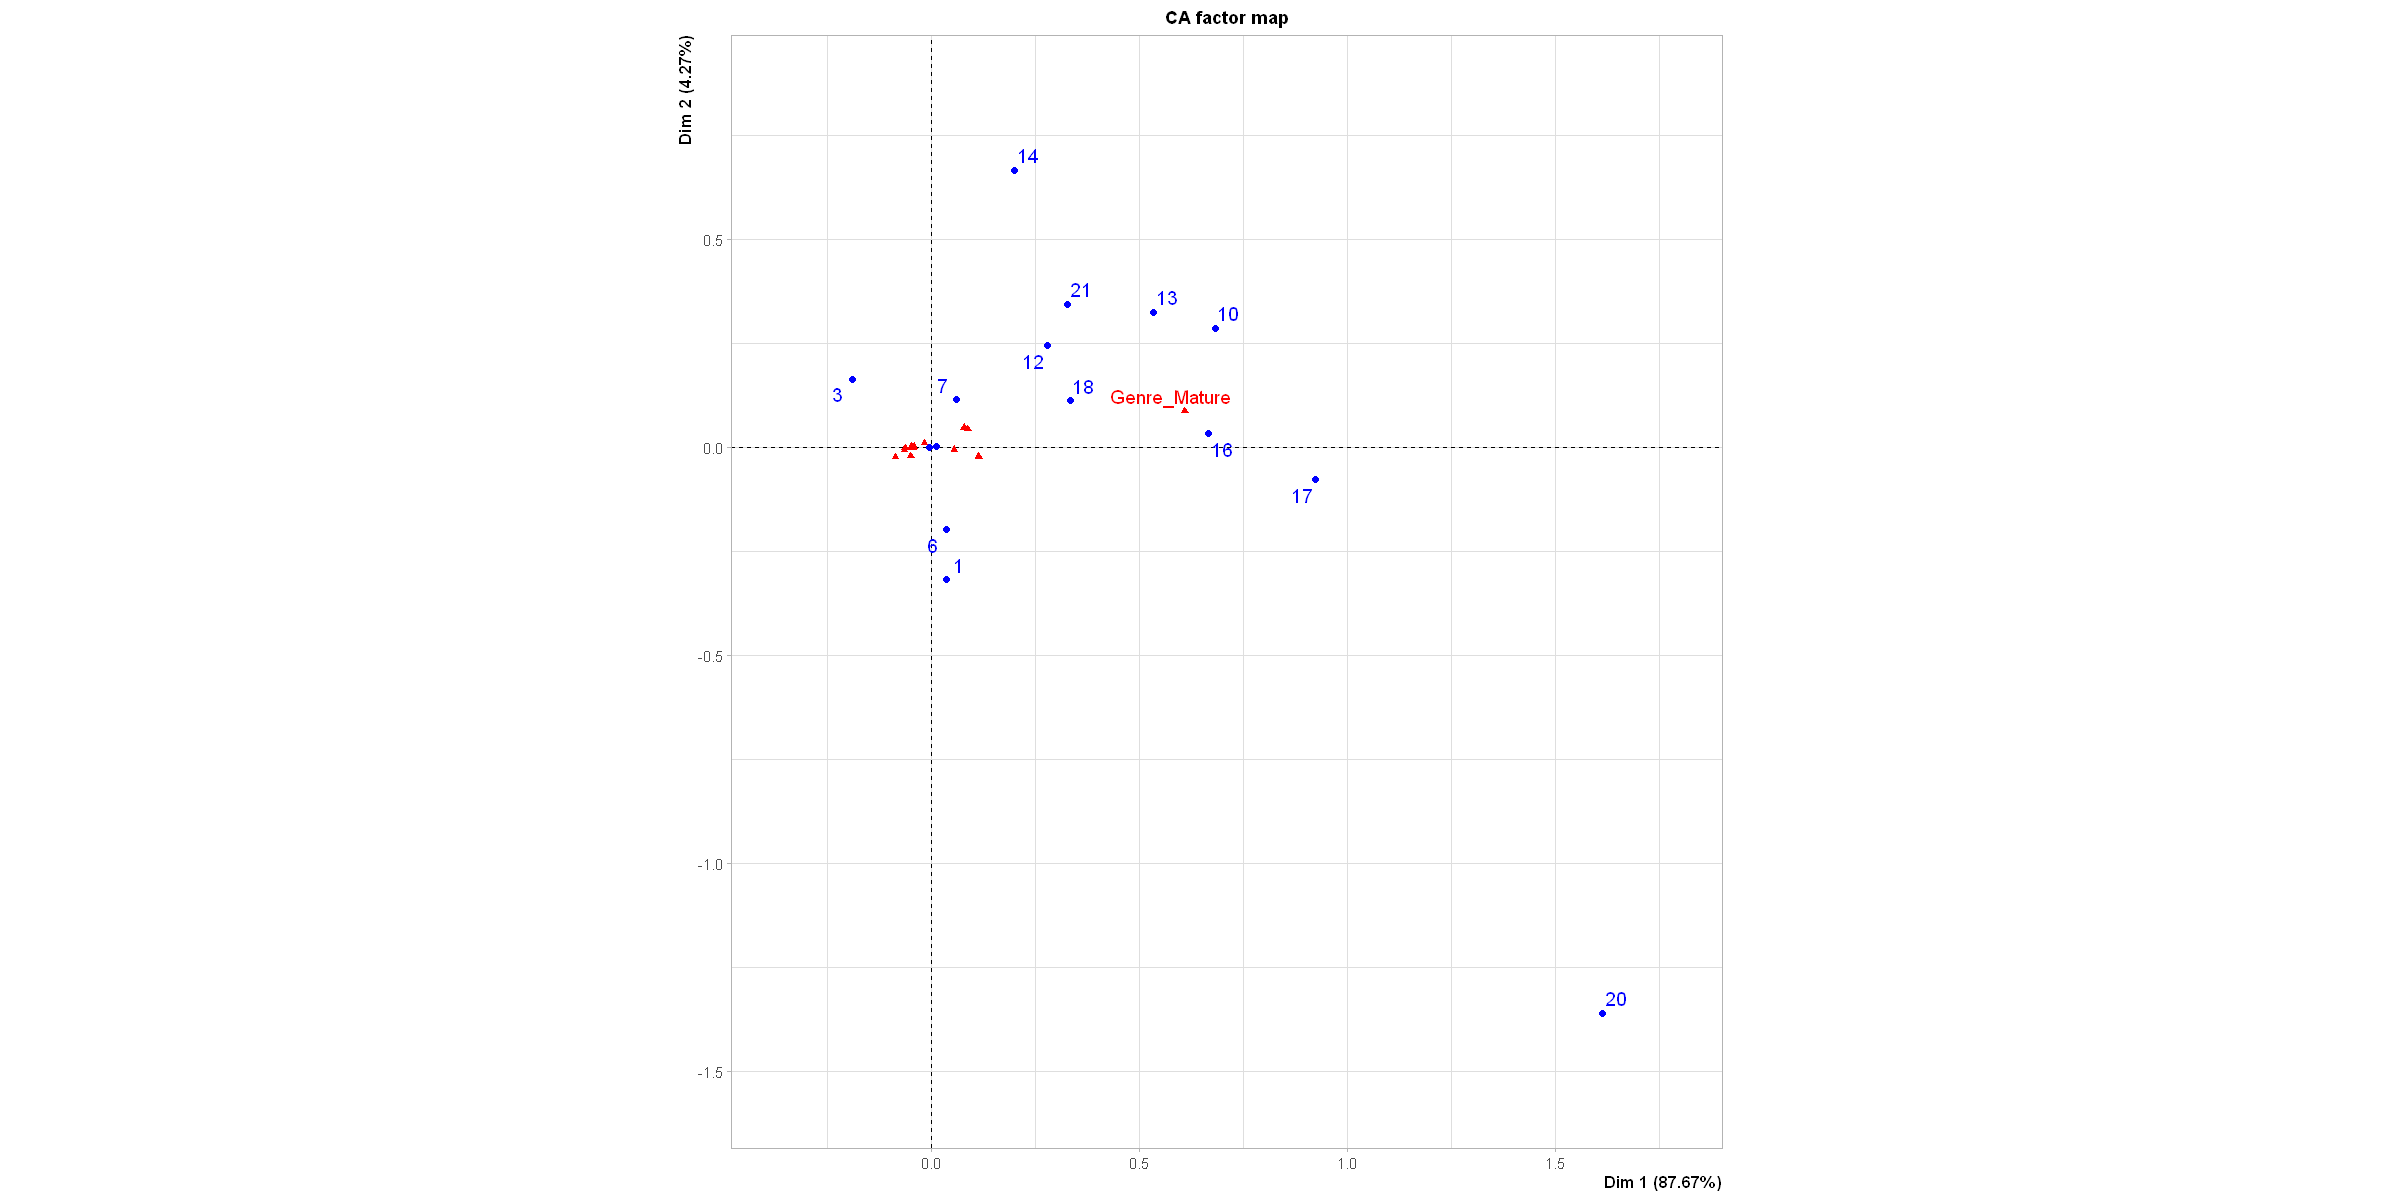

In [53]:
res.ca_age<-CA(tab_contingence_age)

Comme nous le voyons dans l'analyse unidimensionnelle de la variable *Required.age*, la majorité des jeux n'ont pas de restrictions d'age et l'analyse le confirme. Cependant, on remarque quelques cas intéressants, les genres **Action** et **RPG** sont fortement associés aux restrictions 17+ et 18+, alors que les genres **Casual** et **Indie** y sont très peu présents. Aussi,en toute logique, le genre **Mature** se situe à l'extrémité du graphique, confirmant son lien exclusif avec les limites d'âge les plus hautes.

### CA Genres-Systeme d'exploitation

Nous appliquons ensuite la même démarche analytique pour étudier la relation entre les genres et les systèmes d'exploitation (Linux, Mac, Windows). Le processus reste toujours identique : création du tableau de contingence, réalisation du test d'indépendance du Khi-deux, puis exécution de l'Analyse des Correspondances (CA).

In [54]:
cols_genres <- c( "Genres_Early Access", "Genres_Action", 
                 "Genres_Adventure", "Genres_Casual", "Genres_Free To Play", 
                 "Genres_Indie", "Genres_Massively Multiplayer", "Genres_Racing", 
                 "Genres_RPG", "Genres_Simulation", "Genres_Sports", 
                 "Genres_Strategy", "Genre_Mature")

cols_os <- c("Windows", "Mac", "Linux")

# 2. Construction du tableau de contingence
# On cherche directement la valeur "TRUE" (qu'elle soit un texte ou un label de factor)
tab_contingence_os <- sapply(cols_os, function(os) {
  sapply(cols_genres, function(genre) {
    # On compare au label "TRUE"
    sum(as.character(data_quali_new[[genre]]) == "1" & 
        as.character(data_quali_new[[os]]) == "True", na.rm = TRUE)
  })
})

rownames(tab_contingence_os) <- cols_genres
colnames(tab_contingence_os) <- cols_os



In [55]:
test_khi2_os <- chisq.test(tab_contingence_os)
print(test_khi2_os)


	Pearson's Chi-squared test

data:  tab_contingence_os
X-squared = 1009, df = 24, p-value < 2.2e-16



La p-valeur étant inférieure à $0.05$, nous rejetons l'hypothèse d'indépendance. Les variables sont statistiquement liées, ce qui justifie l'utilisation d'une CA.

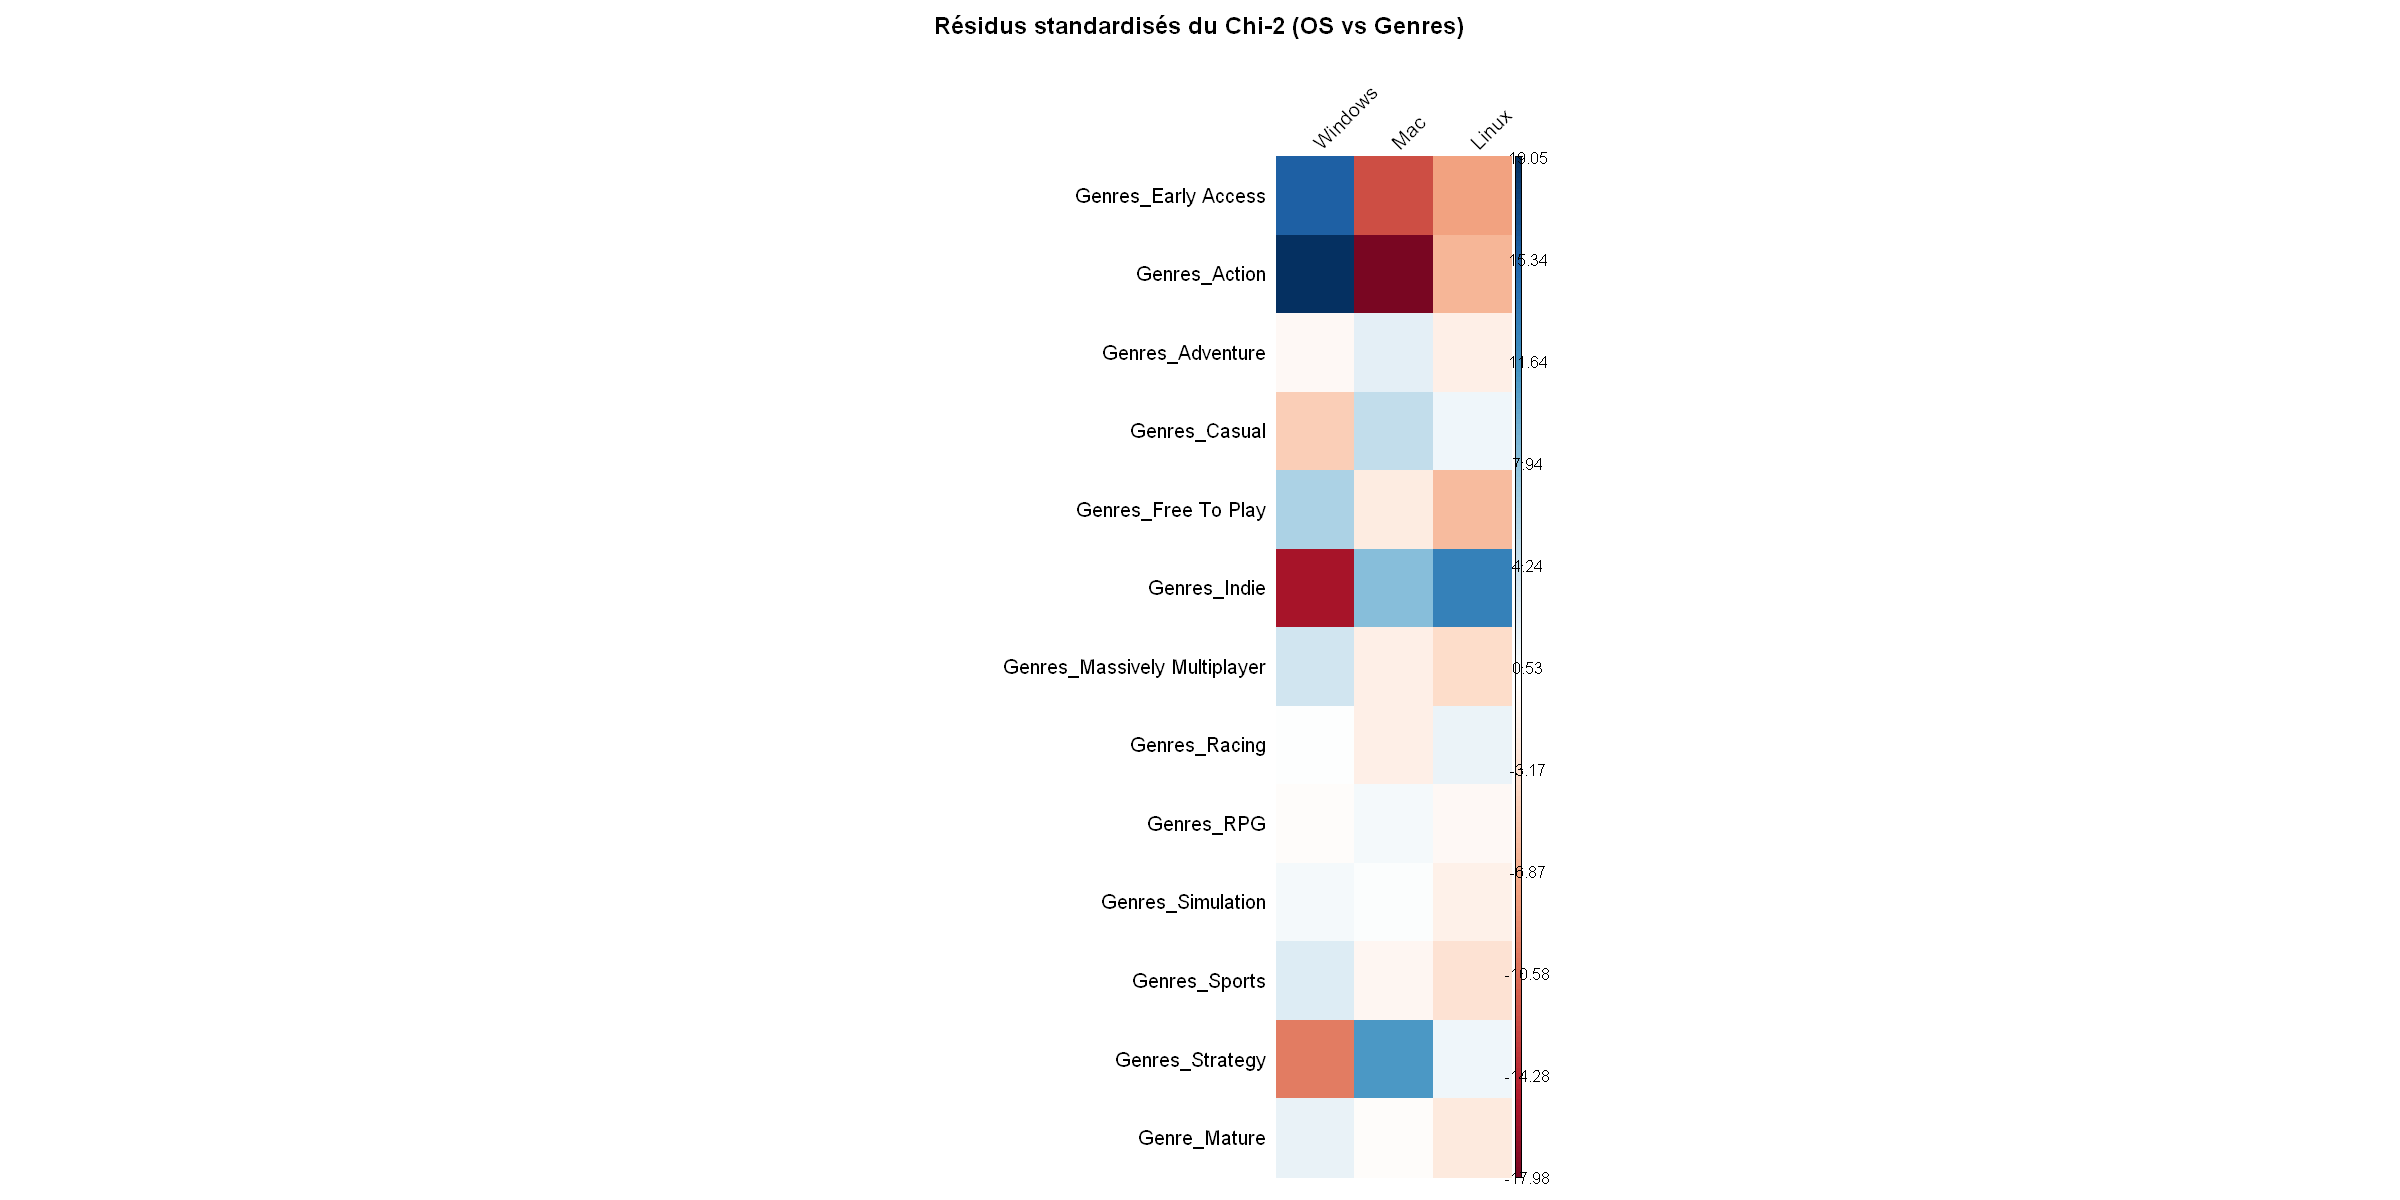

In [56]:
residus_os <- test_khi2_os$stdres
corrplot(residus_os, 
         is.cor = FALSE,method = "color",tl.srt = 45,tl.col = "black",mar = c(0,0,2,0),title = "Résidus standardisés du Chi-2 (OS vs Genres)")

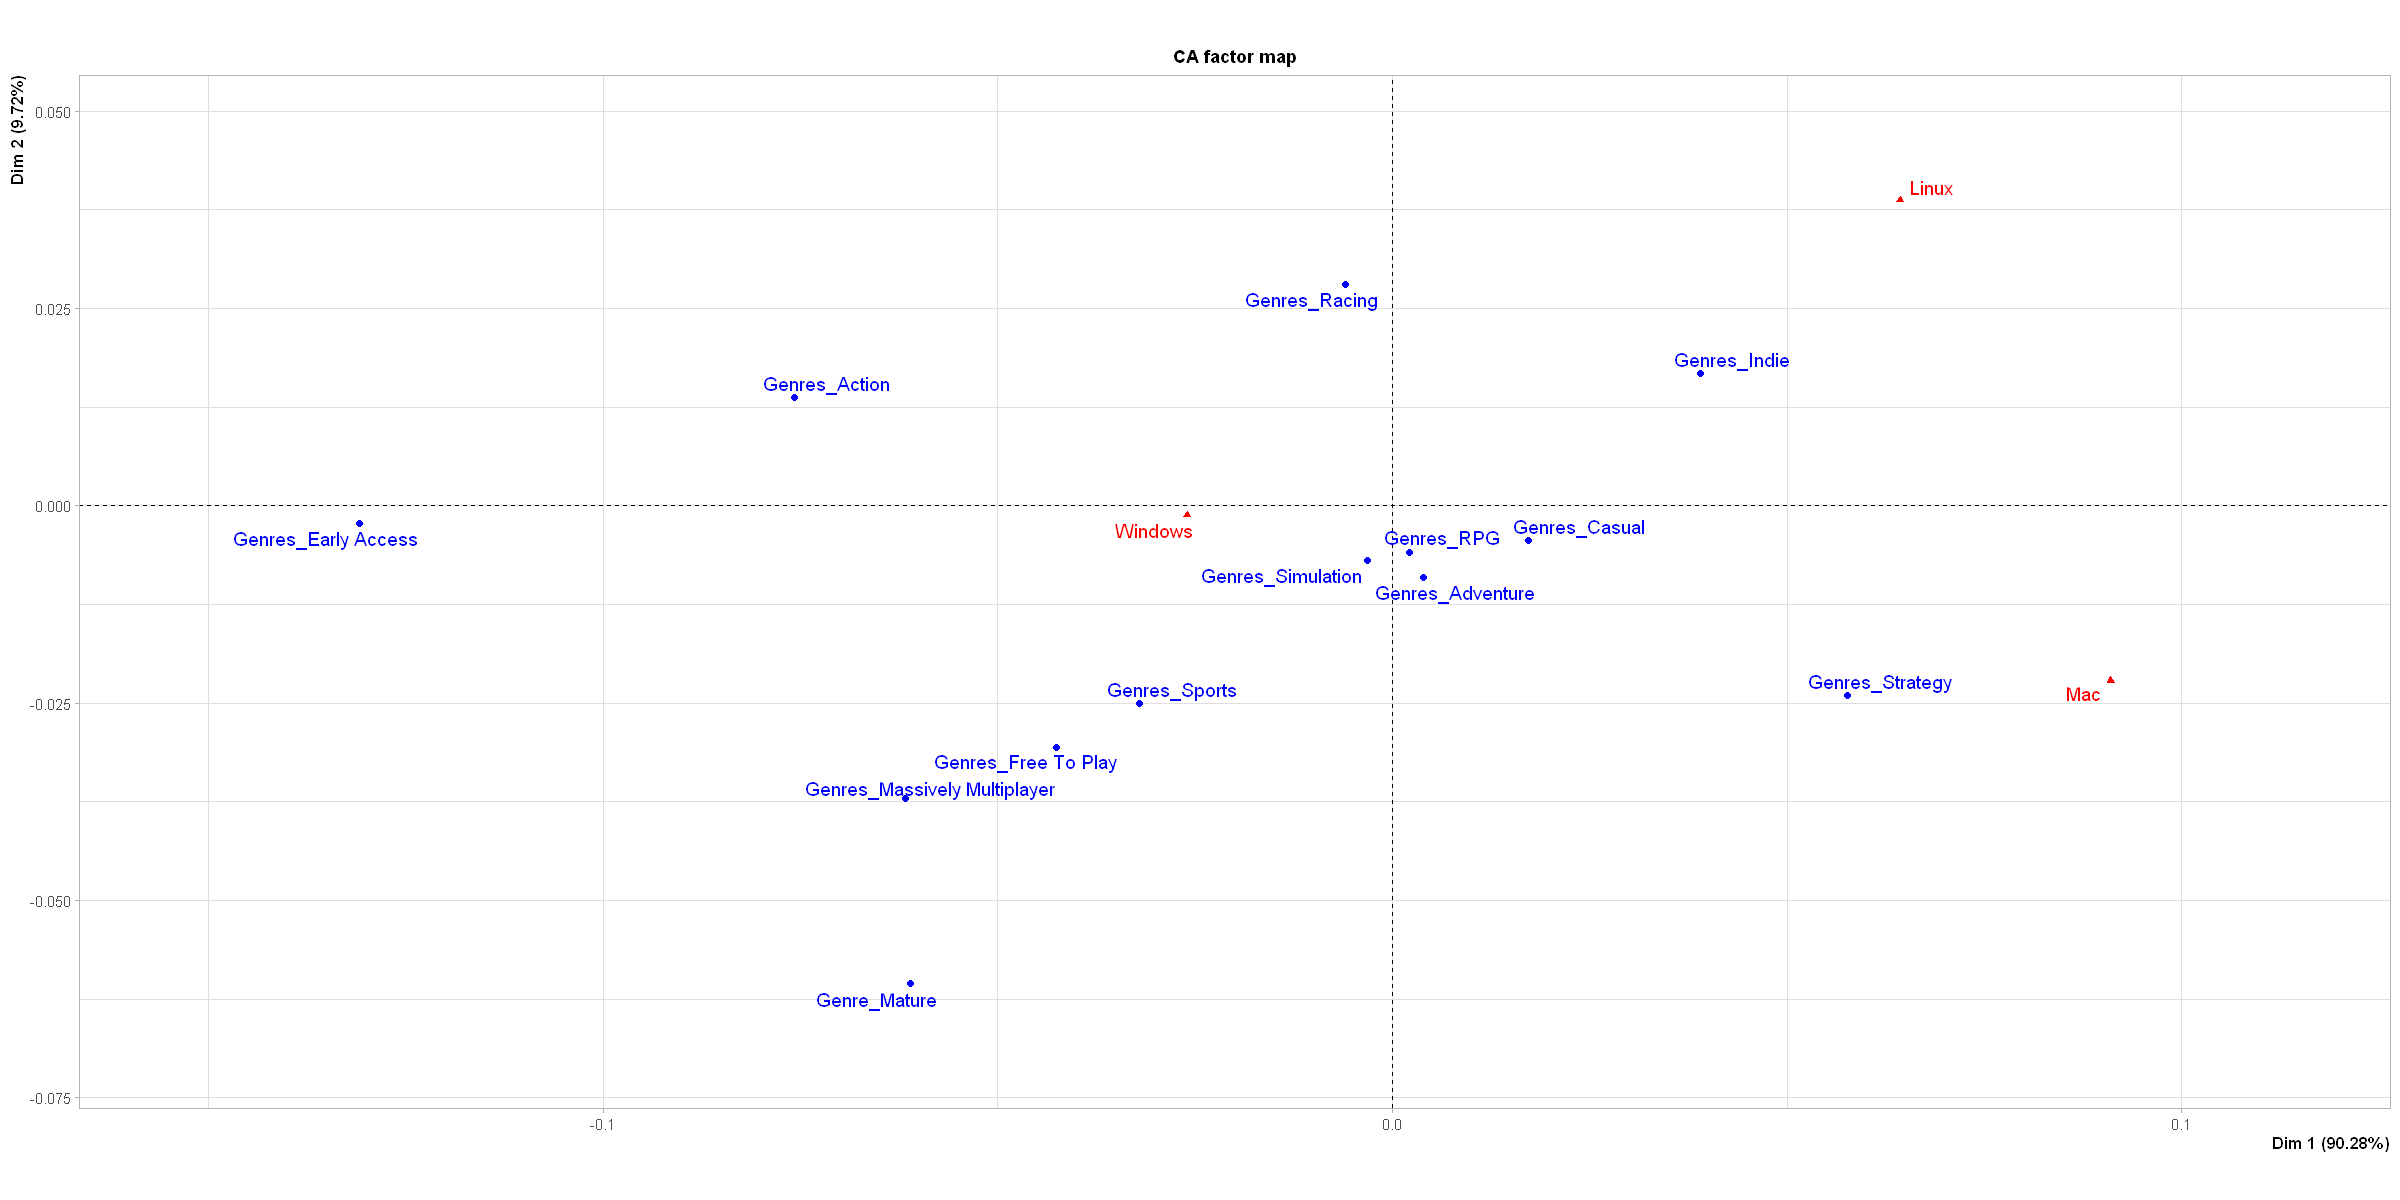

In [57]:
res.ca_os<- CA(tab_contingence_os)

L'observation conjointe de la carte des résidus et de la CA montre que la modalité Windows, située au centre du plan factoriel, représente la norme de publication des jeux. L'axe principal (90,28 % de la variance) sépare logiquement ces jeux standards des jeux multiplateformes : on y observe que les genres Indie et Strategy sont significativement sur-représentés sur Mac et Linux, tandis que les genres Action et Early Access y affichent une forte sous-représentation.

En résumé, l’analyse des variables qualitatives montre que le catalogue Steam est divisé en deux grands profils, en plus d'avoir fortement évolué dans le temps. D'un côté, les jeux indépendants (*Indie*, *Casual*) touchent un public large (pas de restriction d'âge), fonctionnent souvent sur Mac/Linux, mais cumulent de faibles audiences (moins de 50K possesseurs). À l'opposé, les genres traditionnels comme *Action* et *RPG* représentent les plus grands succès commerciaux (plus de 1M de possesseurs), sont plutôt réservés aux adultes (17+/18+) et restent exclusifs à Windows. Enfin, l'évolution chronologique montre que la période historique (1997-2013) centrée sur l'Action et la Stratégie a laissé place à une explosion de l'Indie (2016-2020), pour finir aujourd'hui (2024-2026) par une domination du Free to Play et de l'Early Access. Ces liens évidents entre les catégories justifient le passage à la **FAMD** (Factor Analysis of Mixed Data), qui va maintenant nous permettre d'ajouter les données numériques (prix, notes) à ces profils.


## FAMD Genres-variables quantitatives

Définnisson d'abord notre jeux de données pour réalisé notre FAMD, nous gardons donc toutes les variables qualitatives et pour observer comment les autres variables qualitatives se projettent sur l’espace de la FAMD, nous les intégrons en tant que variables supplémentaires. De plus, le genre *Mature* est également passé en variable supplémentaire en raison de sa sous-représentation. Nous sommes arrivés à ces conclusions de manière empirique, à la suite des FAMD successives que nous avons réalisées.

In [60]:
df_famd<-df_mca_ready %>% dplyr::select(-Name,- Categories,-Tags,-Language,- Developers,-Publishers)

In [61]:
summary(df_famd)

    Release.date    Estimated.owners  Required.age       Discount     
 2025-2026:21812   0-20K    :75337   0      :113288   Min.   :  0.00  
 2024     :18104   0        :13649   17     :   782   1st Qu.:  0.00  
 2023     :13337   20K-50K  :11395   13     :   175   Median :  0.00  
 2022     :11403   50K-100K : 5349   18     :   164   Mean   : 19.62  
 2021     :10441   100K-200K: 3450   16     :    31   3rd Qu.: 45.00  
 2020     : 8746   200K-500K: 2845   10     :    26   Max.   :100.00  
 (Other)  :30670   (Other)  : 2488   (Other):    47                   
  Windows          Mac          Linux       Metacritic.score
 False:    44   False:93260   False:98841   Min.   : 0.000  
 True :114469   True :21253   True :15672   1st Qu.: 0.000  
                                            Median : 0.000  
                                            Mean   : 2.703  
                                            3rd Qu.: 0.000  
                                            Max.   :97.000  
     

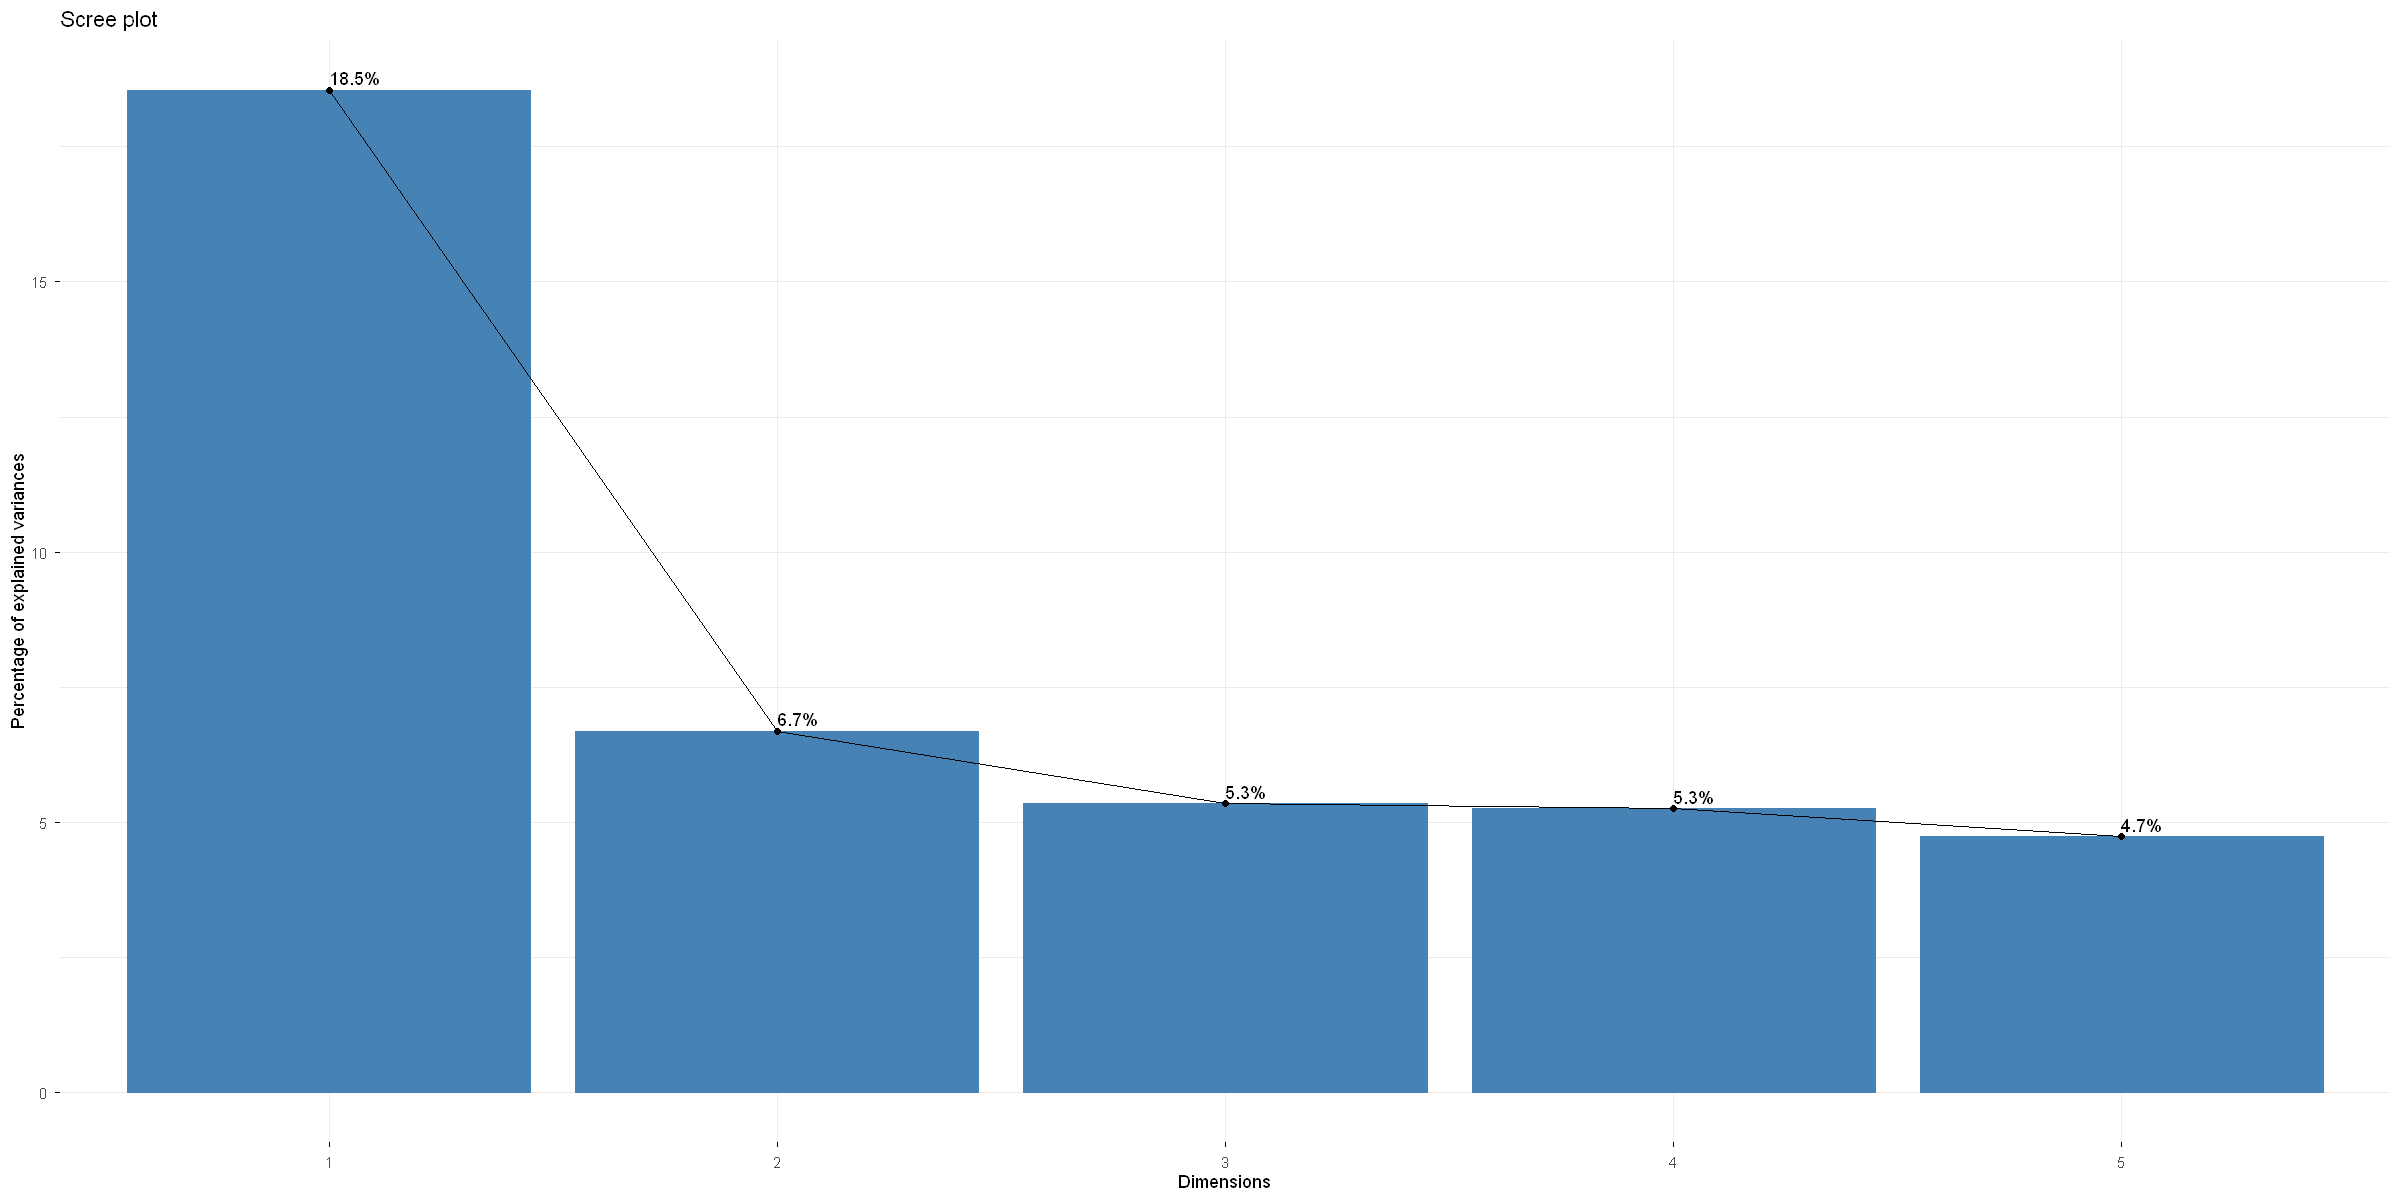

In [62]:

res.famd <- FAMD(df_famd,sup.var=c(1:3,5:7,36), graph = FALSE)
fviz_eig(res.famd,addlabels = T)

Nous retenons les deux premières dimensions de la FAMD car, dès la troisième, un plateau est visible. Cela indique que l'ajout de dimensions supplémentaires n'apporte plus d'informations significatives pour l'analyse.

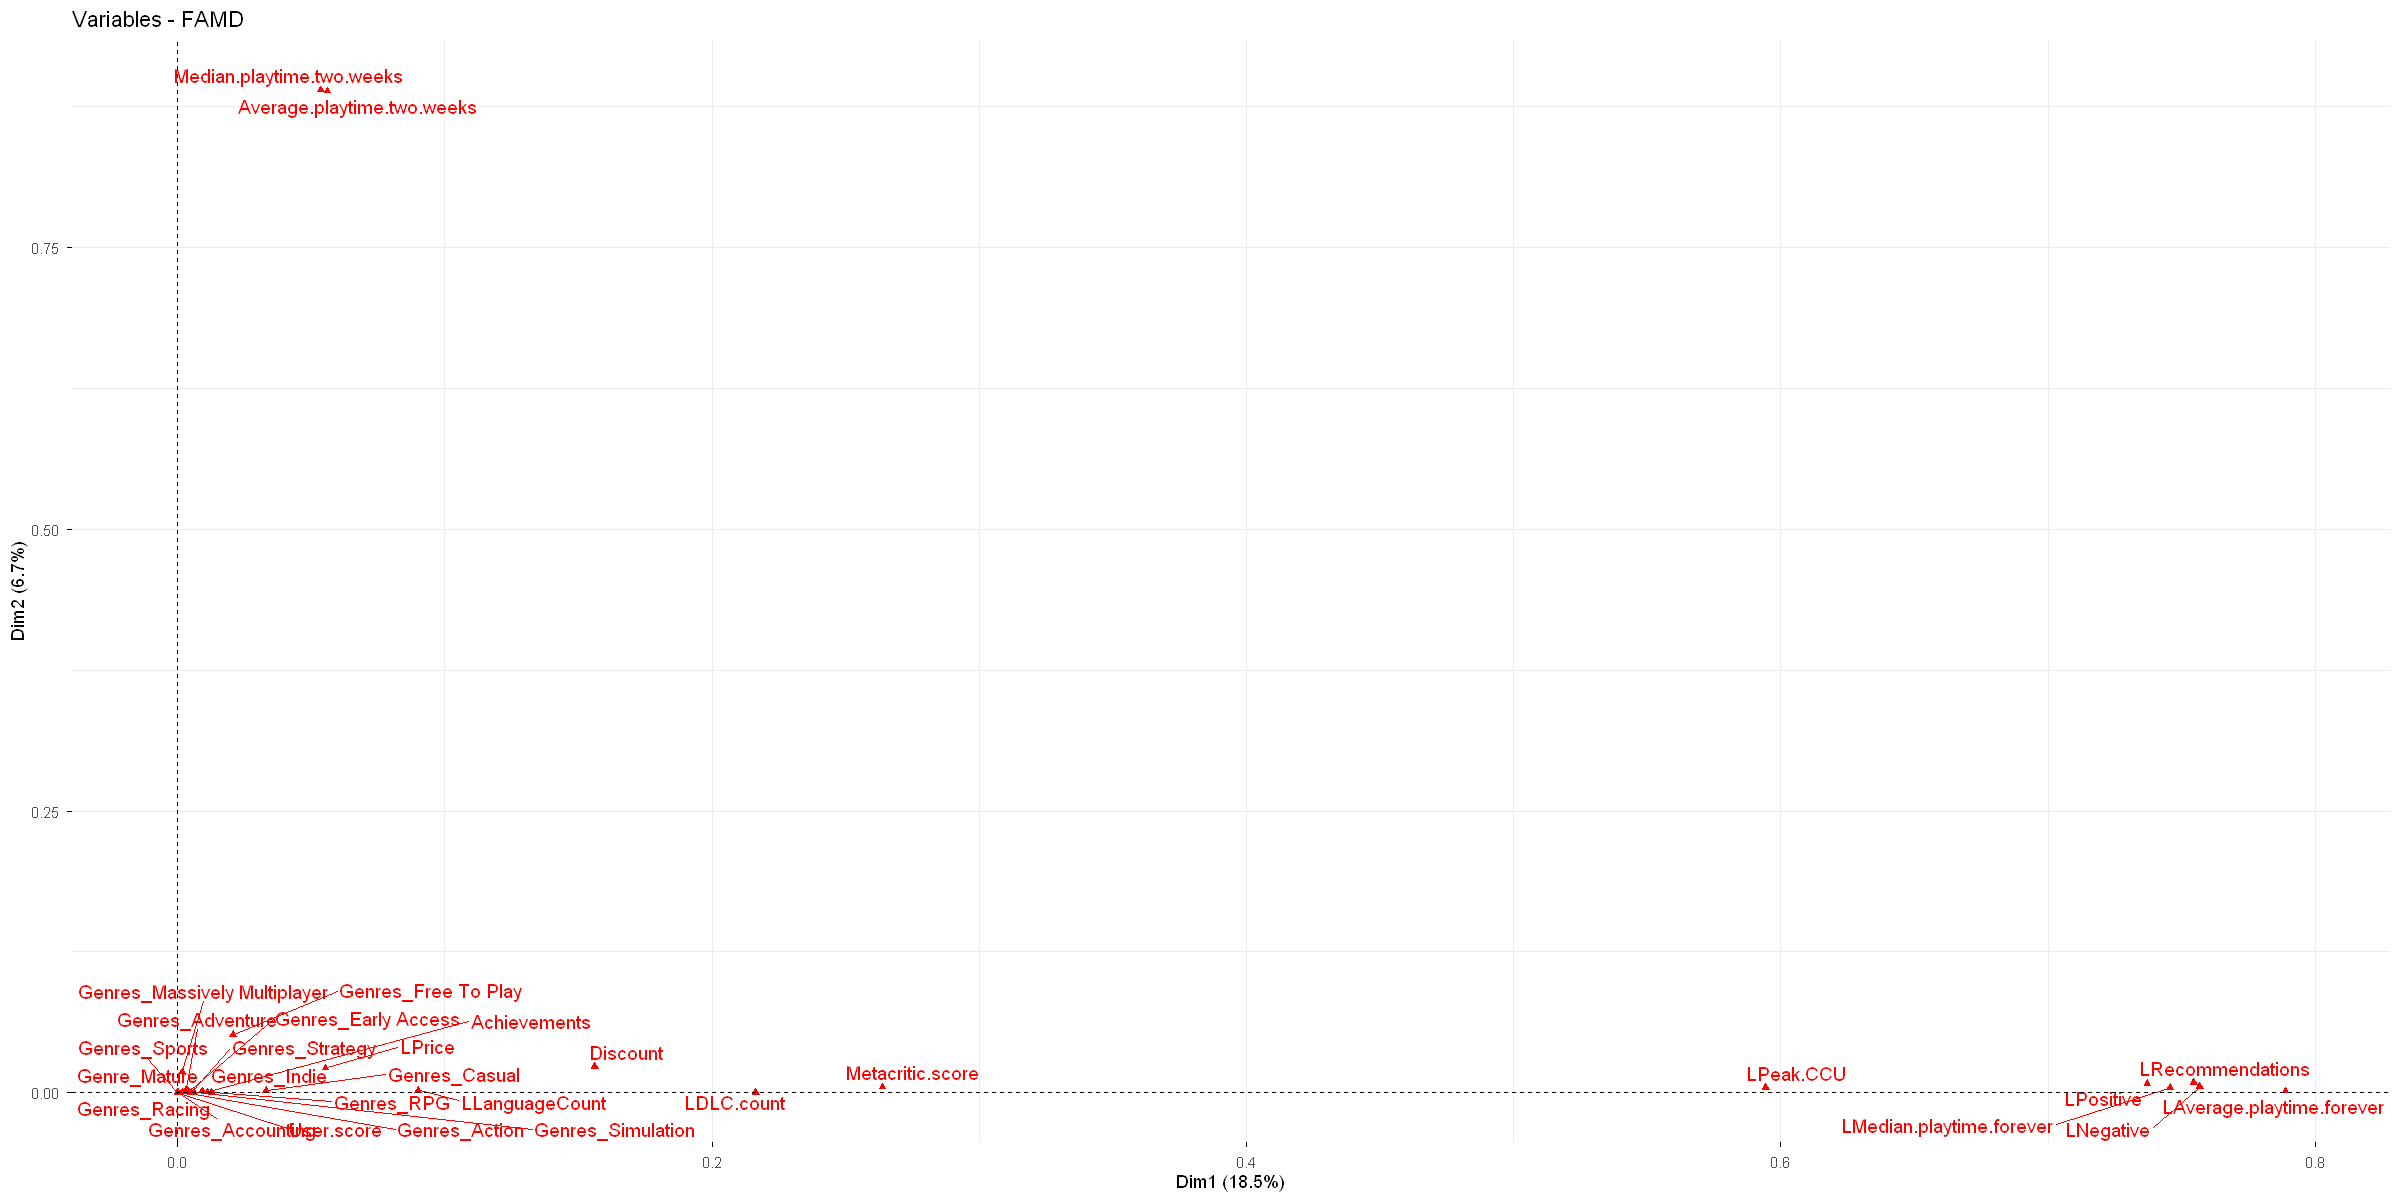

In [63]:
fviz_famd_var(res.famd, repel = T,axes=c(1,2))

#### Contribution aux axes

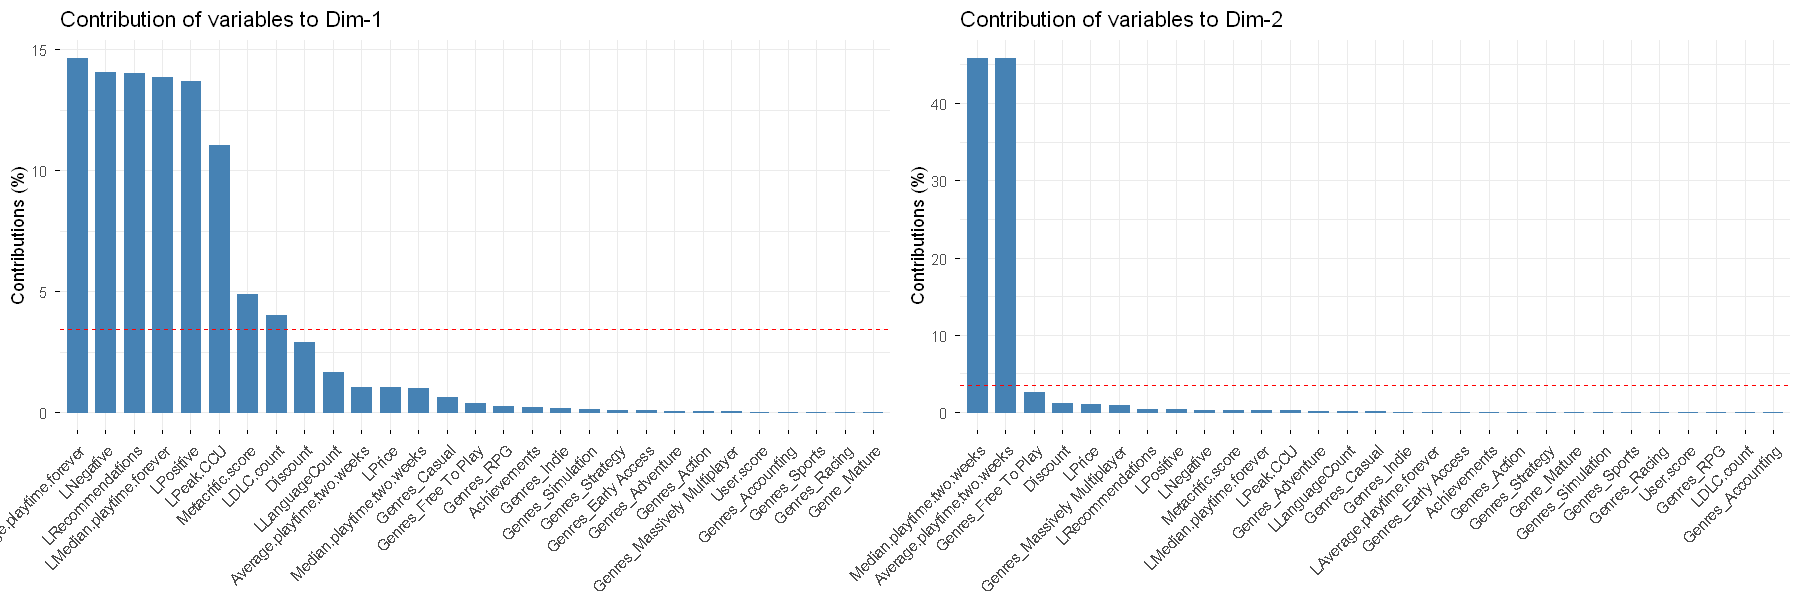

In [157]:
options(repr.plot.width = 15, repr.plot.height = 5)
co1<-fviz_contrib(res.famd, choice = "var", axes = 1) 
co2<-fviz_contrib(res.famd, choice = "var", axes = 2)

grid.arrange(co1,co2,ncol=2)


Cette **FAMD** permet d'identifier deux axes principaux qui expliquent l'ensemble des jeux sur Steam :

**Axe 1** (18,5%): Elle regroupe les variables de réussite massive (nombre de recommandations, évaluations positives et temps de jeu total). Cet axe montre que le succès ne dépend pas d'un genre spécifique, car tous les genres restent regroupés au centre de cette dimension.

**Axe 2** (6,7%): Cette dimension isole les jeux récemment joués (temps de jeu sur les deux dernières semaines). Elle différencie les jeux qui génèrent une activité intense en ce moment de ceux qui ont un succès historique mais sont moins pratiqués ces deux dernières semaines.

On peut donc conclure qu'il n'existe pas de genre intrinsèquement lié au "succès".


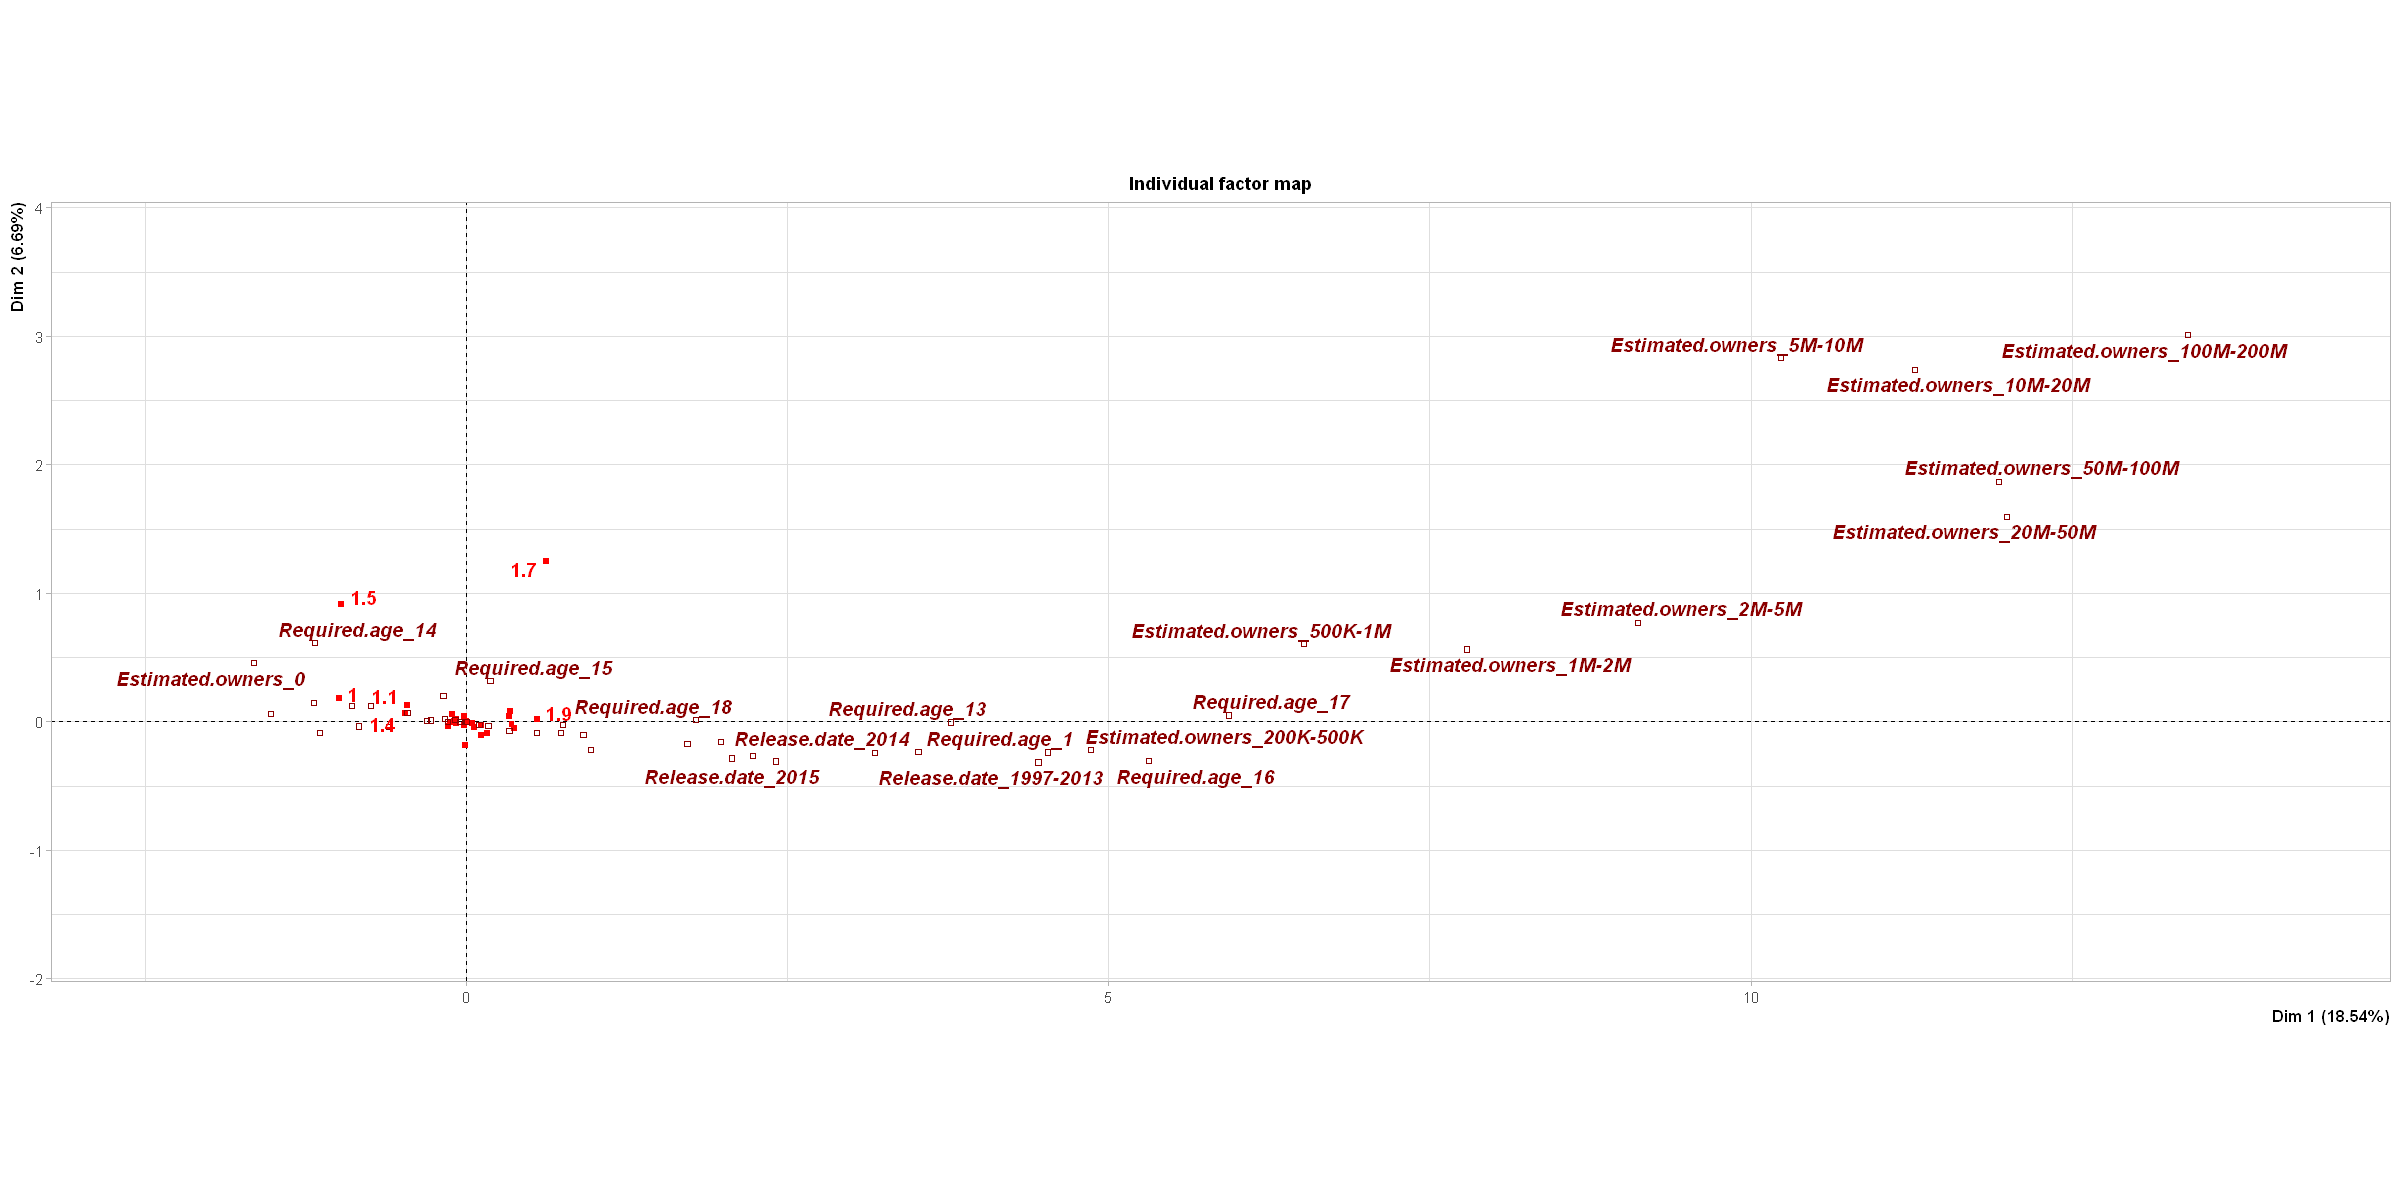

In [64]:

options(repr.plot.width = 20, repr.plot.height = 10)
plot(res.famd, choice = "quali", invisible = "ind")


La projection des **variables supplémentaires** valide la cohérence de l'analyse : l'axe 1 montre bien que plus on va vers la droite, plus les jeux ont de succès (*Estimated.owners*), tout en révélant que ces individus sont souvent des jeux pour adultes (Required.age 17 ou 16). L'axe 2 montre que les plus gros succès commerciaux sont aussi les jeux les plus joués en ce moment, ce qui permet de les distinguer des vieux succès historiques qui ont beaucoup de possesseurs mais moins de joueurs actifs. L'ancienneté joue aussi un rôle dans le succès, car les jeux sortis il y a longtemps (*Release.date* avant 2013) ont eu plus de temps pour accumuler des millions de joueurs et se placer le plus à droite de l'axe 1.

### Clustering GMM

À la suite de cette réduction de dimension, nous utilisons un modèle de mélange gaussien (GMM) pour regrouper les jeux et vérifier si des profils types se dessinent parmi les précédentes observations.

In [65]:
set.seed(123)
#on récupère les coordonnées des 2 premières dimensions de la FAMD
donnees_gmm <- res.famd$ind$coord[, 1:2]
mod_gmm <- Mclust(donnees_gmm)

In [66]:
summary(mod_gmm)

---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VVV (ellipsoidal, varying volume, shape, and orientation) model with 4
components: 

 log-likelihood      n df       BIC       ICL
      -171014.8 114513 23 -342297.6 -353949.7

Clustering table:
    1     2     3     4 
71259  4624 27691 10939 

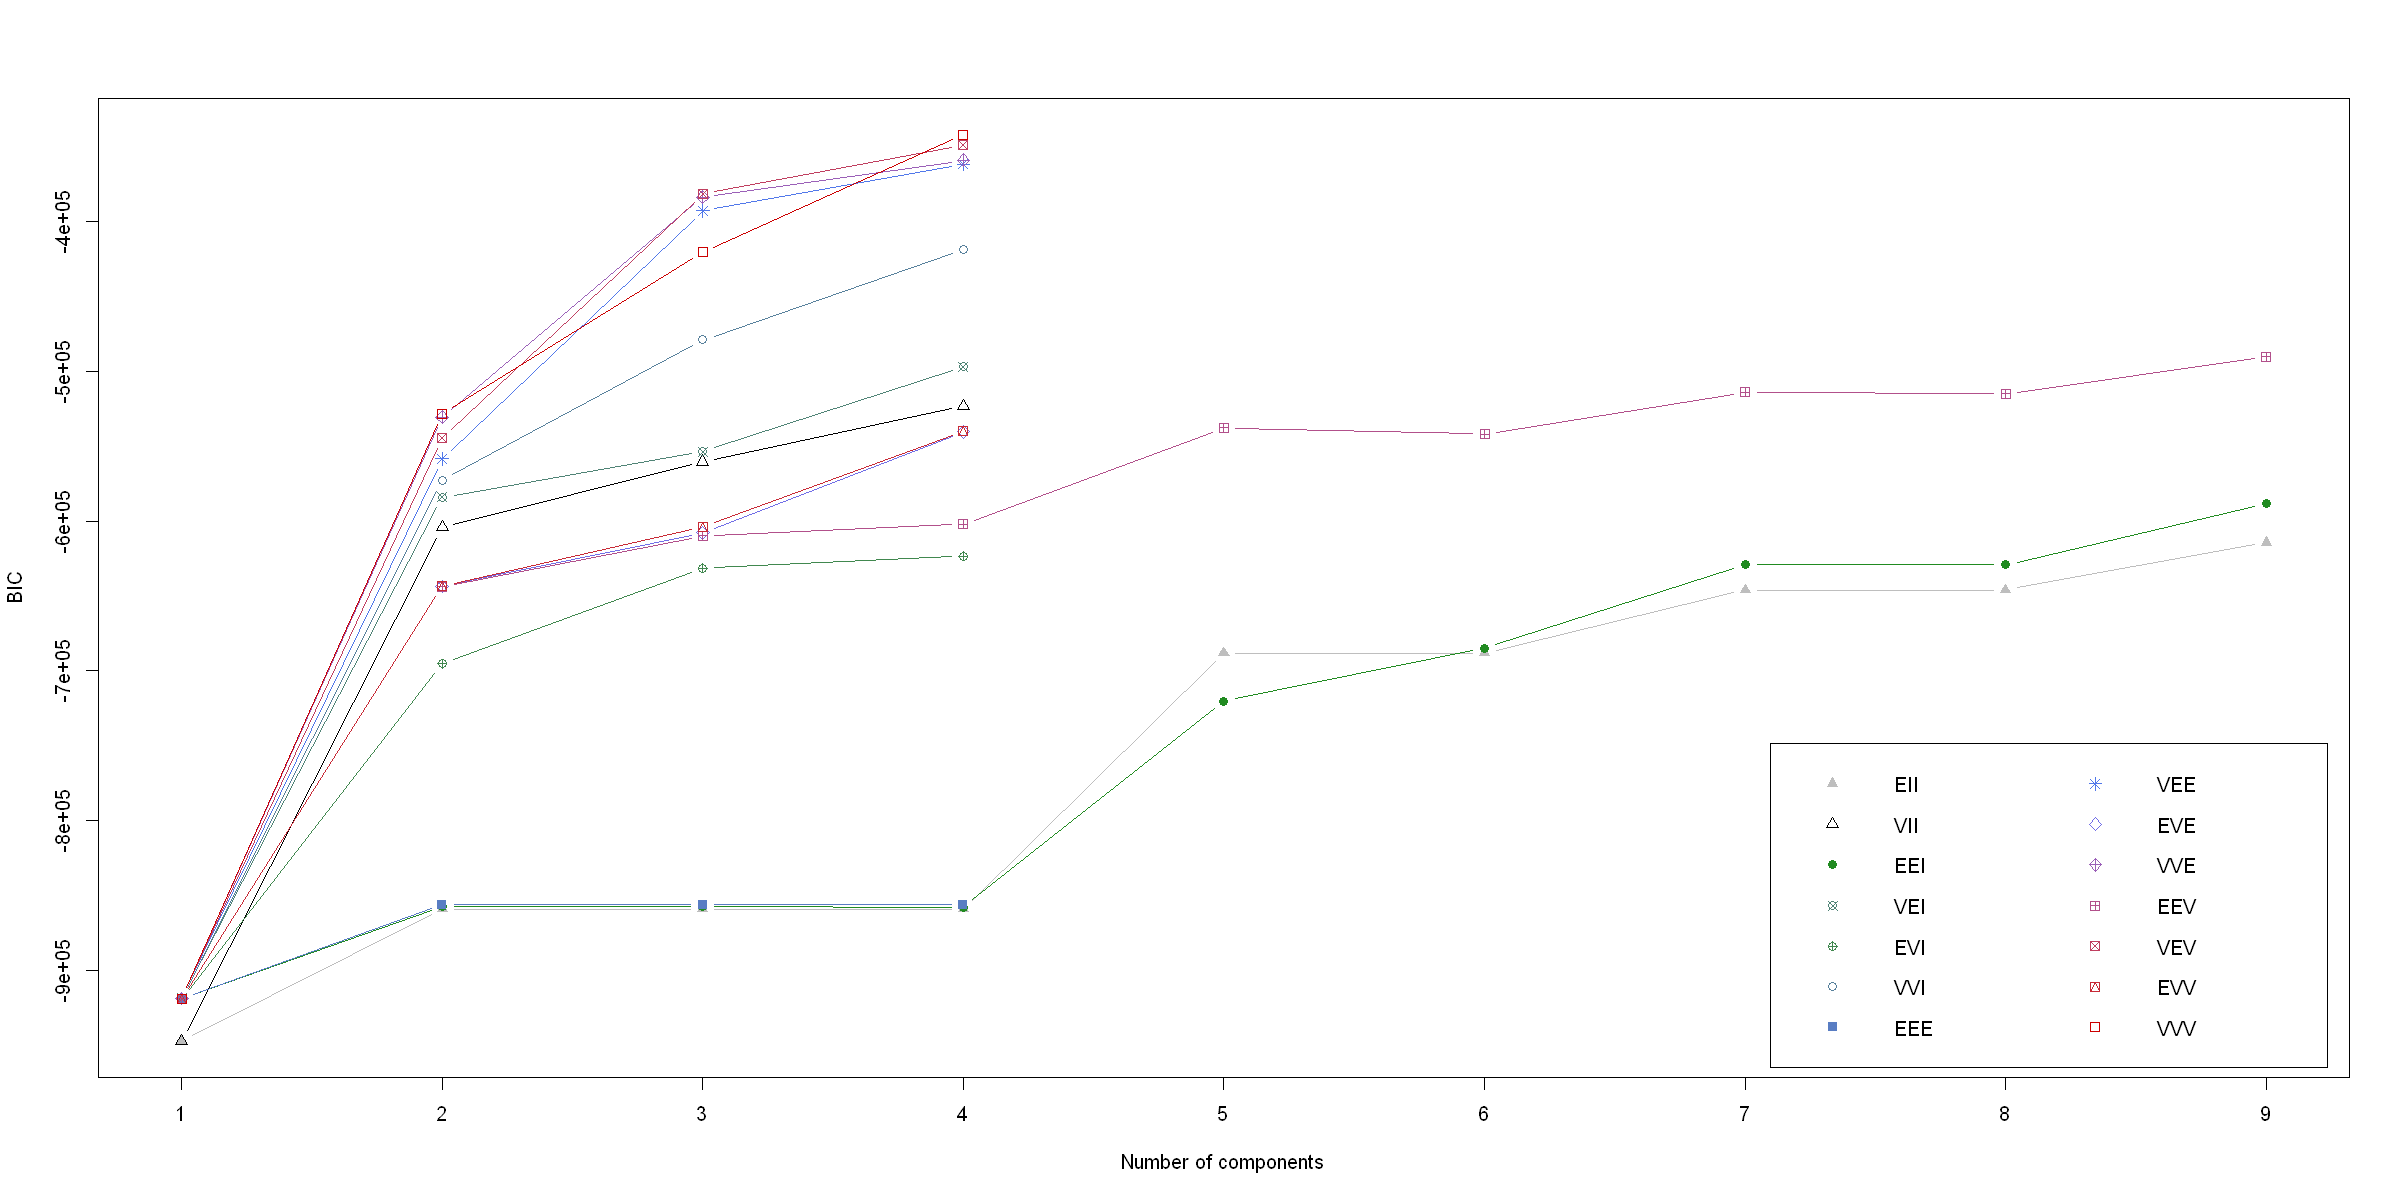

In [67]:
plot(mod_gmm, what = "BIC")

Pour définir le nombre de clusters, on a utilisé le critère BIC avec la fonction *Mclust*, on observe que le modèle VVV (courbe rouge supérieure), définie avec des clusters avec une structure ellipsoïdale à volume, forme et orientation variables, est la plus adaptée pour nos données de FAMD. On constate que la courbe atteint son maximum à 4 clusters.


In [70]:
# Ajouter le numéro de cluster aux données d'origine
donnees_finales <- df_famd
donnees_finales$cluster_gmm <- mod_gmm$classification

La prochaine cellule établi le profil des variables quantitatives de chacun des 4 clusters.

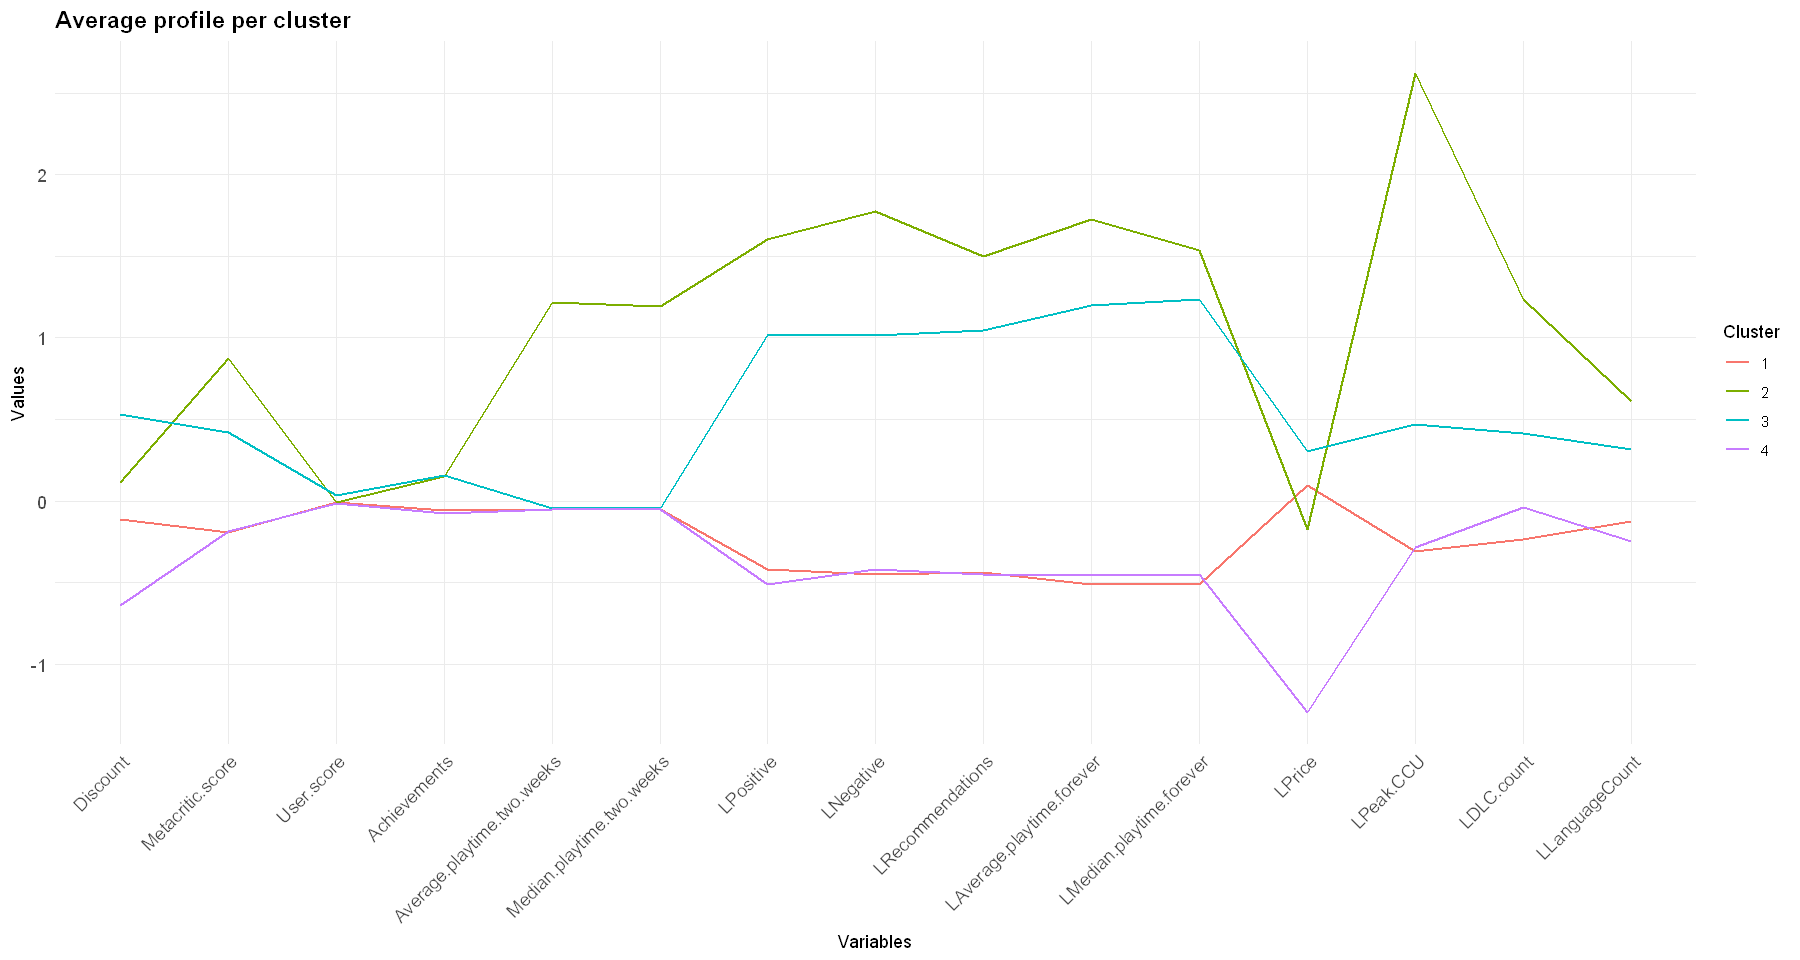

In [74]:
options(repr.plot.width = 15, repr.plot.height = 8)

# On sélectionne uniquement les variables numériques de départ ET la colonne cluster
donnees_quanti_cluster <- donnees_finales %>%
  dplyr::select(where(is.numeric), cluster_gmm)

# On centre-réduit uniquement les variables numériques pour pouvoir les comparer
variables_a_scale <- sapply(donnees_quanti_cluster, is.numeric) & names(donnees_quanti_cluster) != "cluster_gmm"
donnees_quanti_cluster[, variables_a_scale] <- scale(donnees_quanti_cluster[, variables_a_scale])

# Calcul des profils moyens par cluster GMM
mean_profiles_gmm <- aggregate(. ~ cluster_gmm, data = donnees_quanti_cluster, FUN = mean)
mean_profiles_gmm_melt <- melt(mean_profiles_gmm, id.vars = "cluster_gmm")


ggplot(mean_profiles_gmm_melt, aes(x = variable, y = value, color = factor(cluster_gmm), group = cluster_gmm)) +
  geom_line(linewidth = 0.8) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, size = 11),
    axis.text.y = element_text(size = 11),
    plot.title = element_text(size = 14, face = "bold"),
    legend.position = "right"
  ) +
  labs(
    title = "Average profile per cluster", 
    x = "Variables", 
    y = "Values",
    color = "Cluster"
  )

Nous pouvons noter ces conclusion à partir du profils moyen des variables quantitatives:

**Cluster 1** (Rouge): Ce groupe représente la norme basse de la plateforme. Toutes ses variables numériques se situent légèrement en dessous de 0 (la moyenne globale). Les jeux de ce cluster ont un prix faible, très peu d'évaluations (positives ou négatives), un temps de jeu réduit et un pic de joueurs simultanés bas. Ce sont des titres qui passent globalement inaperçus et génèrent peu d'activité.

**Cluster 2** (Vert): Ce cluster rassemble les plus grands succès de Steam. Il affiche des valeurs très hautes sur la quasi-totalité des indicateurs : un pic de joueurs simultanés (*LPeak.CCU*) extrêmement élevé, un nombre important de recommandations et d'évaluations, ainsi qu'un temps de jeu très conséquent. On peut aussi noter que leur prix (*LPrice*) est proche de la moyenne ou légèrement en dessous, et ils bénéficient d'une très bonne note Metacritic.

**Cluster 3 (Bleu)**: Ce groupe se caractérise par des jeux au prix moyen mais qui se vendent bien. Ils se situent nettement au-dessus de la moyenne pour le nombre d'avis positifs/négatifs, les recommandations et le temps de jeu global. Sans atteindre les valeurs du Cluster 2 en termes de pic de joueurs ou de popularité brute, ces jeux bénéficient d'un engagement fort et d'une base de joueurs solide.

**Cluster 4 (Violet)**: Ce cluster se distingue principalement par sa valeur très basse sur l'axe du prix (*LPrice*), ce qui indique un groupe composé de jeux gratuits ou très peu chers. Ils affichent également un taux de réduction (*Discount*) très bas. Pour tout le reste (temps de jeu, évaluations, joueurs en ligne), leurs valeurs sont négatives et collées à celles du Cluster 1, ce qui montre qu'ils ne parviennent pas à attirer le public malgré leur gratuité ou leur bas prix.

Les analyses précédentes ayant déjà détaillé le rôle des variables comme *Required.age* ou *Estimated.owners* sur les genres des jeux viéos, nous choisissons donc ici de concentrer l'étude qualitative de nos clusters uniquement sur la variable Genres, qui constitue le fil conducteur de notre étude. Pour avoir une représentation graphique lisible pour la répartition des genres on peut faire l'affichage en barplot.

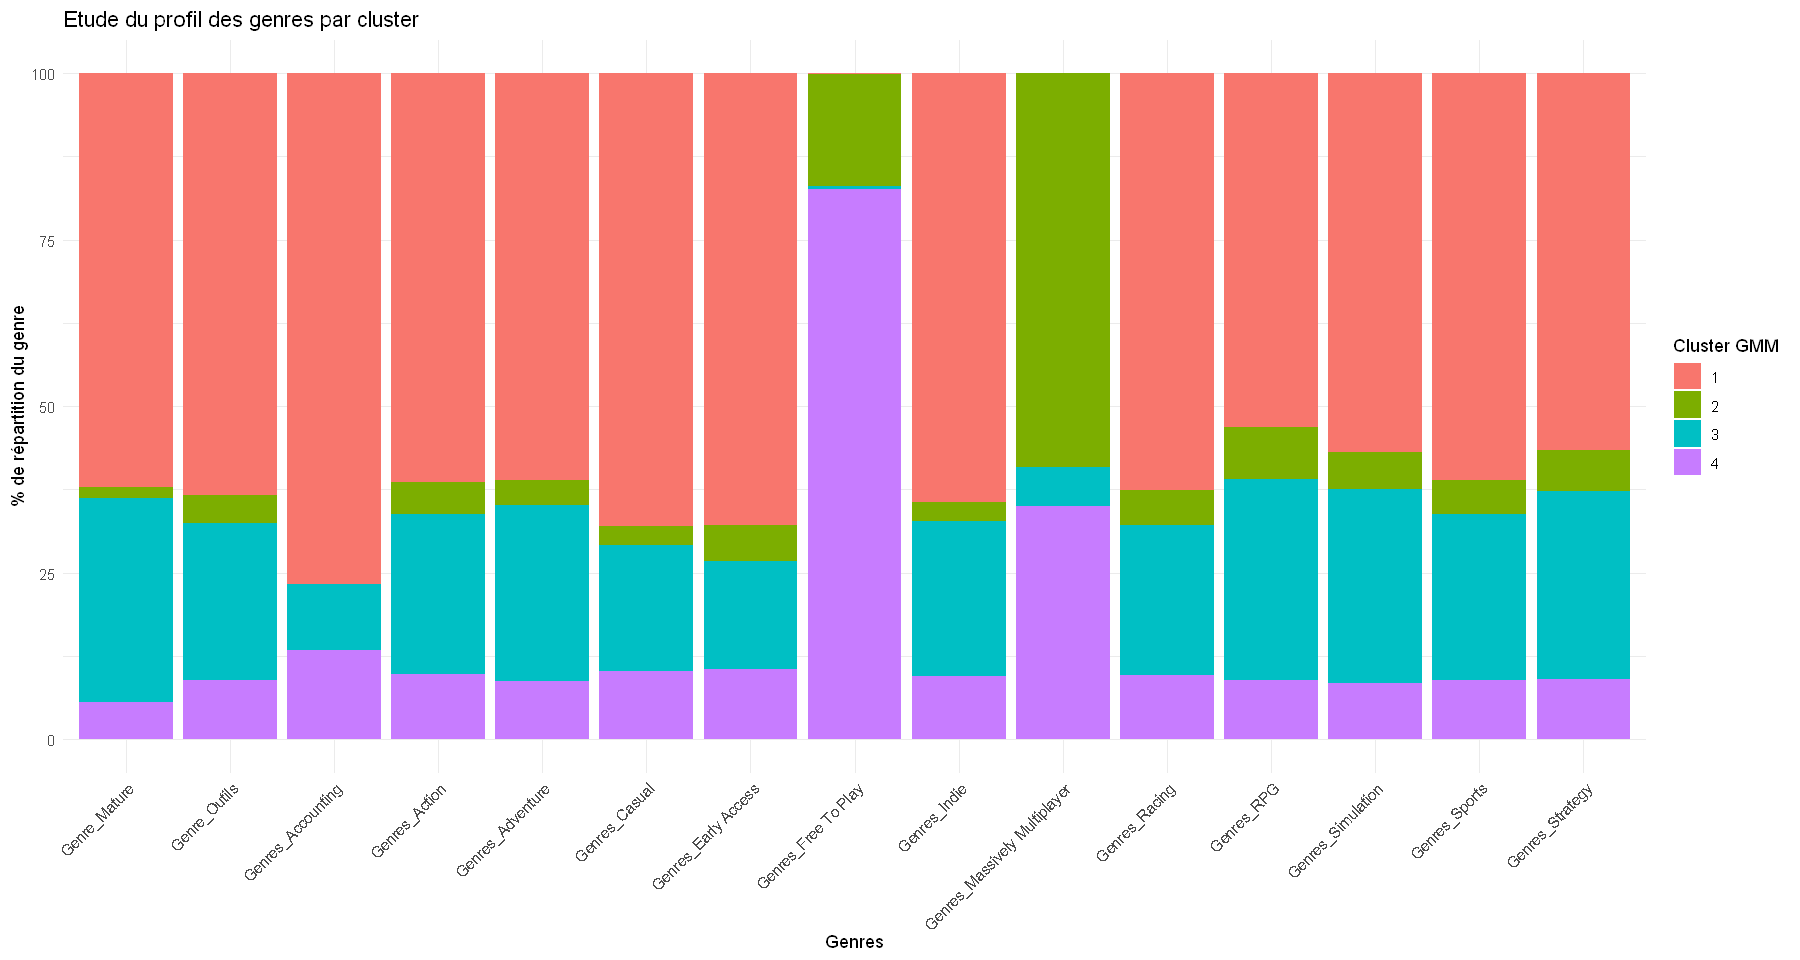

In [94]:
#  Calcul du pourcentage de répartition de CHAQUE genre à travers les clusters
df_prop_equilibre <- donnees_finales %>%
  # Isole les colonnes de genres et celle du cluster
  dplyr::select(dplyr::contains("Genre"), cluster_gmm) %>%
  
  # Aligne tous les genres sur une seule colonne pour faciliter le tri
  pivot_longer(-cluster_gmm, names_to = "Genre") %>%
  
  # Garde uniquement les lignes où le genre est présent
  filter(value == 1 | value == TRUE) %>%
  
  # Compte le nombre de jeux par genre dans chaque cluster
  dplyr::count(cluster_gmm, Genre) %>% 
  
  # Isole les calculs pour travailler genre par genre
  group_by(Genre) %>% 
  
  # Calcule la part de chaque cluster par rapport au total de ce genre
  mutate(Pourcentage = n / sum(n) * 100)


ggplot(df_prop_equilibre, aes(x = Genre, y = Pourcentage, fill = factor(cluster_gmm))) +
  geom_bar(stat = "identity", position = "stack") + # Barres empilées pour atteindre 100%
  labs(title = "Etude du profil des genres par cluster", 
       x = "Genres", 
       y = "% de répartition du genre",
       fill = "Cluster GMM") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**Le Cluster 1** (Rouge): C'est le groupe le plusgrand du catalogue. Il capte plus de la moitié de presque tous les genres traditionnels (Indie, Casual, Action, RPG, Stratégie, etc.). Cela confirme qu'il s'agit du cluster des jeux "standards" qui forment la base de la plateforme Steam.

**Le Cluster 2** (Vert): Ce groupe est très ciblé. Sa présence est anecdotique pour la majorité des genres, sauf pour le genre *Massively Multiplayer* dont il capte plus de la moitié des titres. On y trouve également une part visible de jeux de rôle (RPG).

**Le Cluster 3** (Bleu): Ce cluster absorbe environ 25 % à 30 % de la quasi-totalité des genres de manière très homogène (Mature, Outils, Action, Aventure, Simulation, etc.). Il représente une catégorie intermédiaire qui ne dépend pas d'un genre en particulier.

**Le Cluster 4** (Violet): C'est le résultat le plus marquant du graphique. Le cluster 4 aspire plus de 80 % de la totalité des jeux Free To Play de Steam, ainsi qu'une part importante des jeux Massively Multiplayer. C'est la preuve que ce cluster est spécifiquement défini par ce modèle économique gratuit.

**Conclusion:**

En combinant le profil des courbes numériques et la répartition des genres, le clustering GMM valide nos analyses précédentes en opposant la masse du catalogue à deux modèles économiques bien distincts. Les **Clusters 1 et 3** représentent le modèle payant traditionnel qui regroupe la majorité des jeux standards de la plateforme (*Indie*, *Action*, *RPG*...), ce qui explique leurs courbes proches de la moyenne. À l'opposé, le **Cluster 2** regroupe les jeux qui affichent les plus forts niveaux d'audience et d'engagement sur Steam. De plus, il isole spécifiquement le genre *Massively Multiplayer* (qui y trouve plus de la moitié de ses jeux). Enfin, le **Cluster 4** matérialise la rupture économique récente (2024-2026) en monopolisant plus de 80 % des jeux *Free To Play* ; sa courbe montre un prix nul mais une audience globale très faible, confirmant que ce modèle sert à publier pour limiter le risque financier, sans pour autant égaler le succès populaire des grands jeux du **Cluster 2**.

Pour vérifier les conclusions précédentes sur le succès nous nous sommes ensuite demandés quelles étaient les caractéristiques intrinsèques à un jeux pour avoir du succès sur Steam. Nous passons donc à notre deuxième étude:

 **Quelles sont les variables intrinsèques à un jeu qui caractérisent le succès sur Steam? Et parmi les jeux à succès, peut-on etablir des classes de succès?**

## Quelles sont les variables intrinsèques d'un jeu qui caractérisent le succès?

Afin de repondre à cette question nous allons réaliser une FAMD sur les variables qui définissent une jeux comme son nombre de langues, son prix, son genre etc... Pour cette étude nous avons don restreint nos variables en supprimant tous les attributs liés aux conséquence qu'un jeu marche ou non comme *LPositive* ou *Average.playtime* amis aussi la variable *Windows* car ce système d'exploitation est commun à pratiquement l'entièreté des jeux sur Steam mais aussi la date de sortie car on ne peux pas sortir des jeux autrement que cette année. Et enfin nous n'avons pas pris en compte certaines variable car nous ne trouvons pas utile de les étudier. Pour voir si un axe expliquait le succès nous avons gardé en variables supplémentaires les variables *Estimated.owners* et *LRecommendations* car nous considérons que c'est ces variables la qui définissent le succès à l'échelle d'un jeux vidéos.

In [98]:
data_famd_succes<- df_mca_ready %>% dplyr::select(-c(Required.age,Windows,Release.date,Name,Metacritic.score,Achievements,Average.playtime.two.weeks,User.score,Median.playtime.two.weeks,Developers,Publishers,
                                     Categories,Tags,Language,LPositive,LNegative,LAverage.playtime.forever,LMedian.playtime.forever,LPeak.CCU))

summary(data_famd_succes)


  Estimated.owners    Discount         Mac          Linux      
 0-20K    :75337   Min.   :  0.00   False:93260   False:98841  
 0        :13649   1st Qu.:  0.00   True :21253   True :15672  
 20K-50K  :11395   Median :  0.00                              
 50K-100K : 5349   Mean   : 19.62                              
 100K-200K: 3450   3rd Qu.: 45.00                              
 200K-500K: 2845   Max.   :100.00                              
 (Other)  : 2488                                               
 LRecommendations     LPrice         LDLC.count     LLanguageCount  
 Min.   : 0.000   Min.   :0.0000   Min.   :0.0000   Min.   :0.0000  
 1st Qu.: 0.000   1st Qu.:0.6366   1st Qu.:0.0000   1st Qu.:0.6931  
 Median : 0.000   Median :1.3056   Median :0.0000   Median :0.6931  
 Mean   : 1.169   Mean   :1.3083   Mean   :0.1583   Mean   :1.2921  
 3rd Qu.: 0.000   3rd Qu.:1.9445   3rd Qu.:0.0000   3rd Qu.:1.7918  
 Max.   :15.390   Max.   :6.9087   Max.   :8.2172   Max.   :4.6444  
     

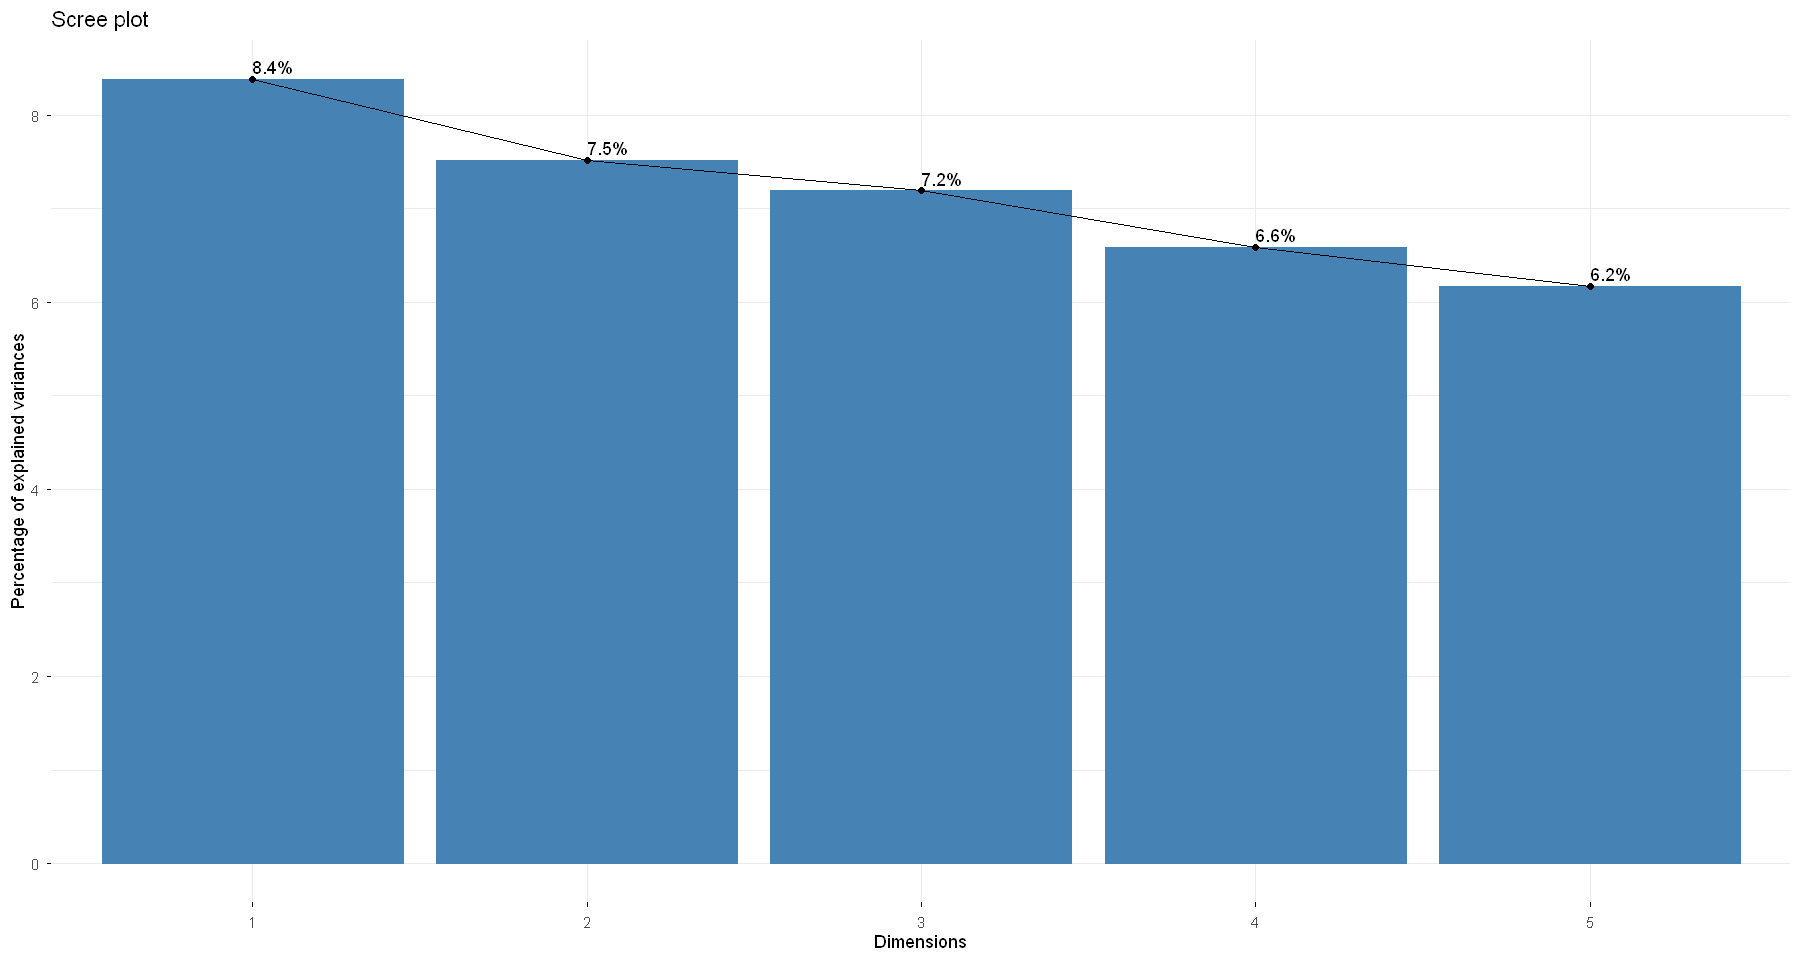

In [99]:
res_famd_succes=FAMD(data_famd_succes,sup.var=c(1,5),graph=F)
fviz_eig(res_famd_succes,addlabels = T)

Nous avons chois de garder uniquement 3 composantes principales. Etudions comment nos variables qualitatives et quantitatives  sont projeté sur le plan de la FAMD.

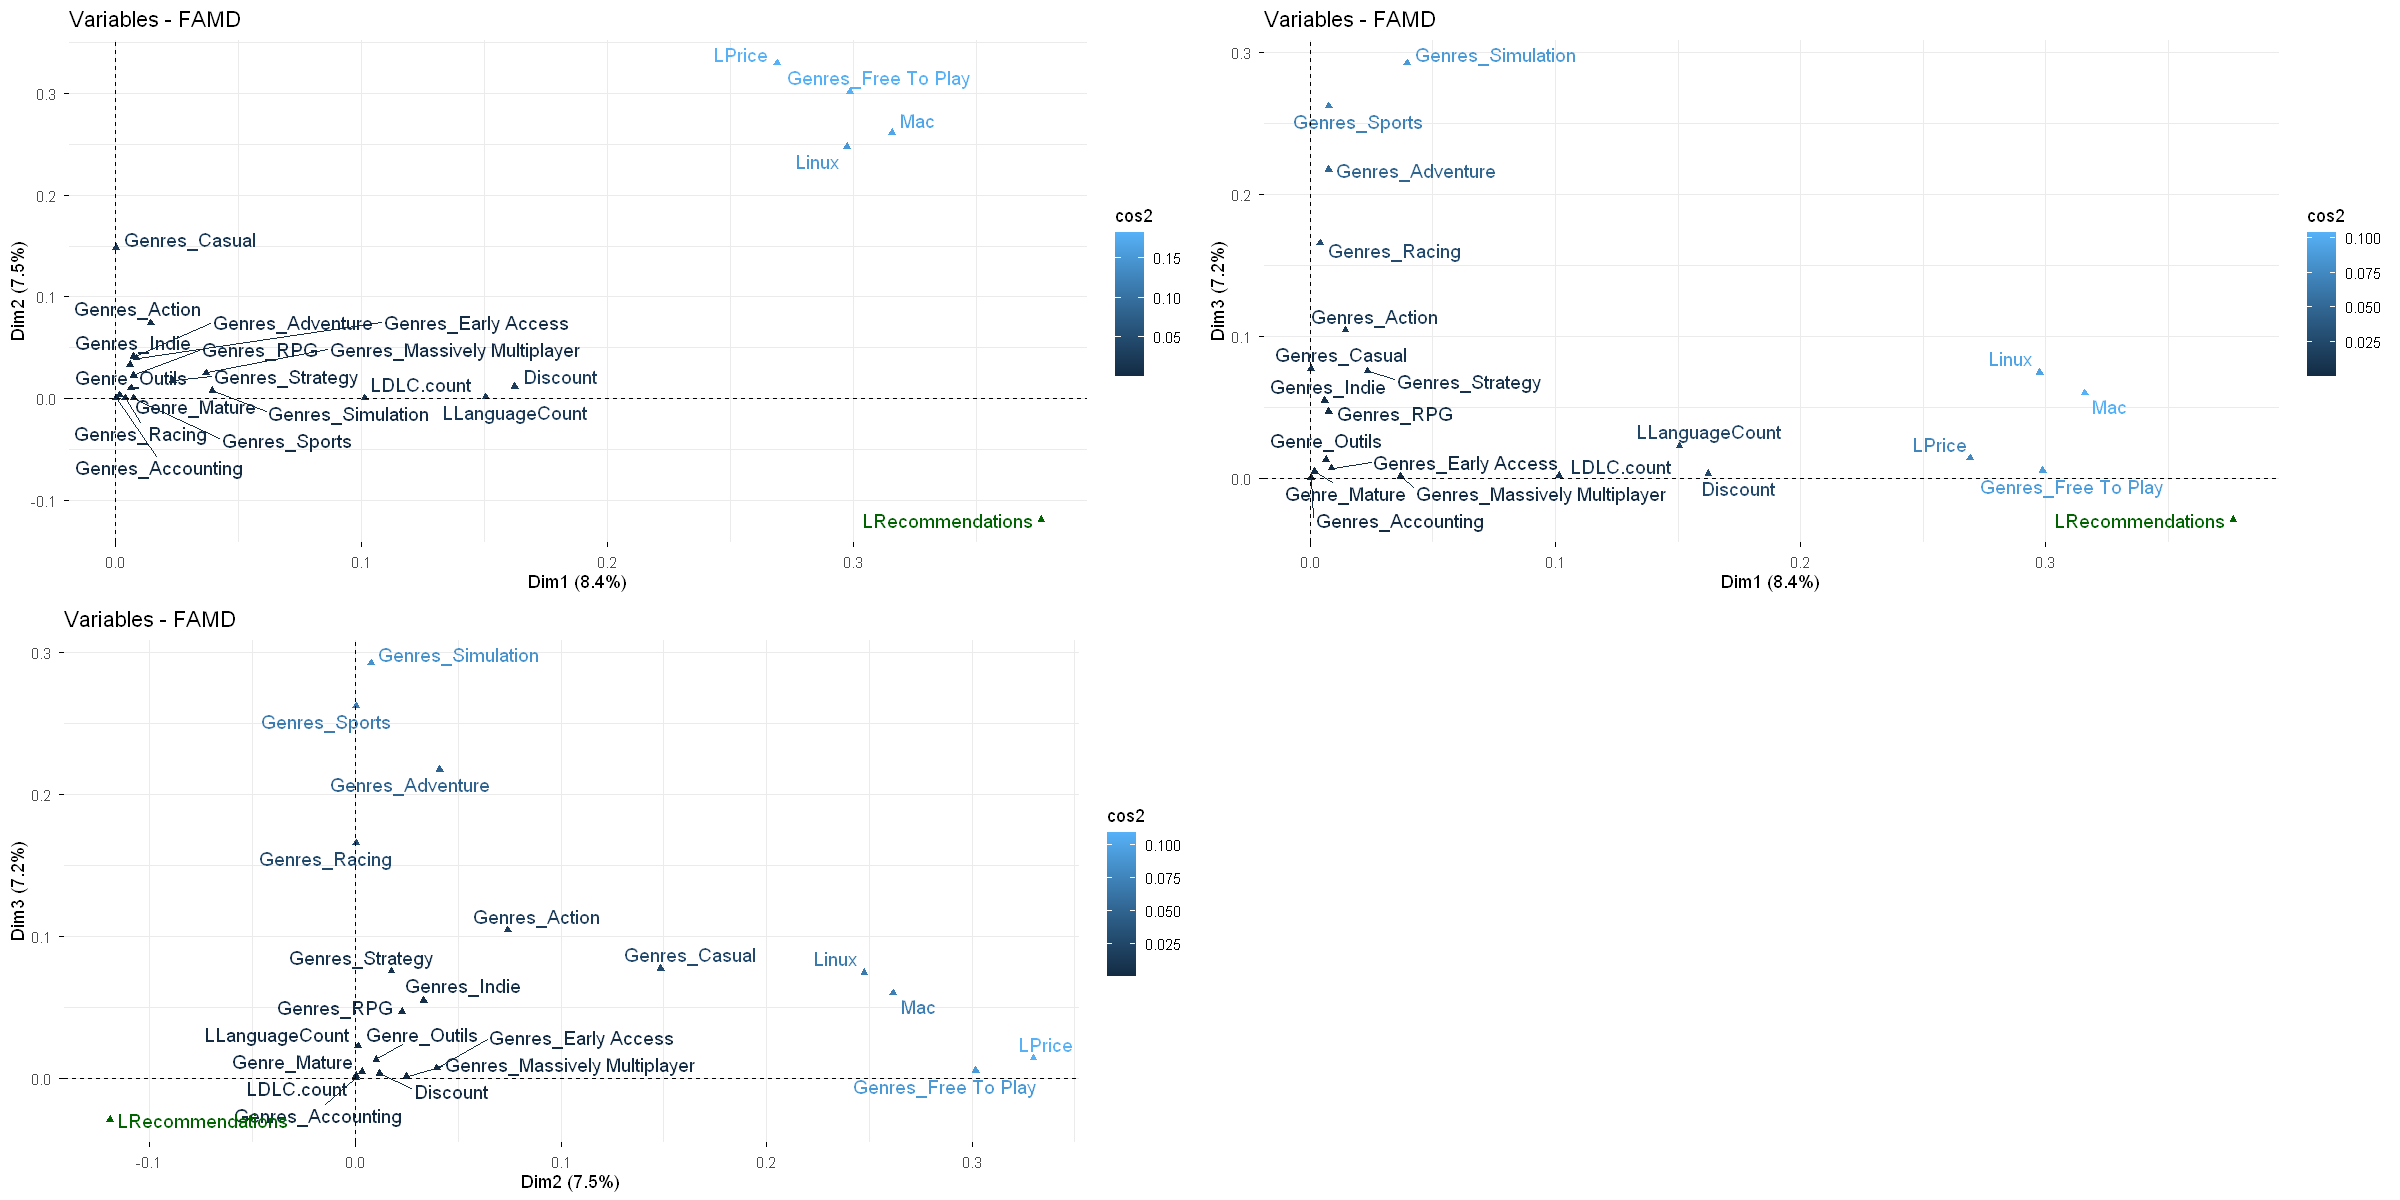

In [160]:
options(repr.plot.width = 20, repr.plot.height =10)
vq1<-fviz_famd_var(res_famd_succes,axes=c(1,2),repel=T,col.var = "cos2")
vq2<-fviz_famd_var(res_famd_succes,axes=c(1,3),repel=T,col.var = "cos2")
vq3<-fviz_famd_var(res_famd_succes,axes=c(2,3),repel=T,col.var = "cos2")

grid.arrange(vq1,vq2,vq3,ncol=2)

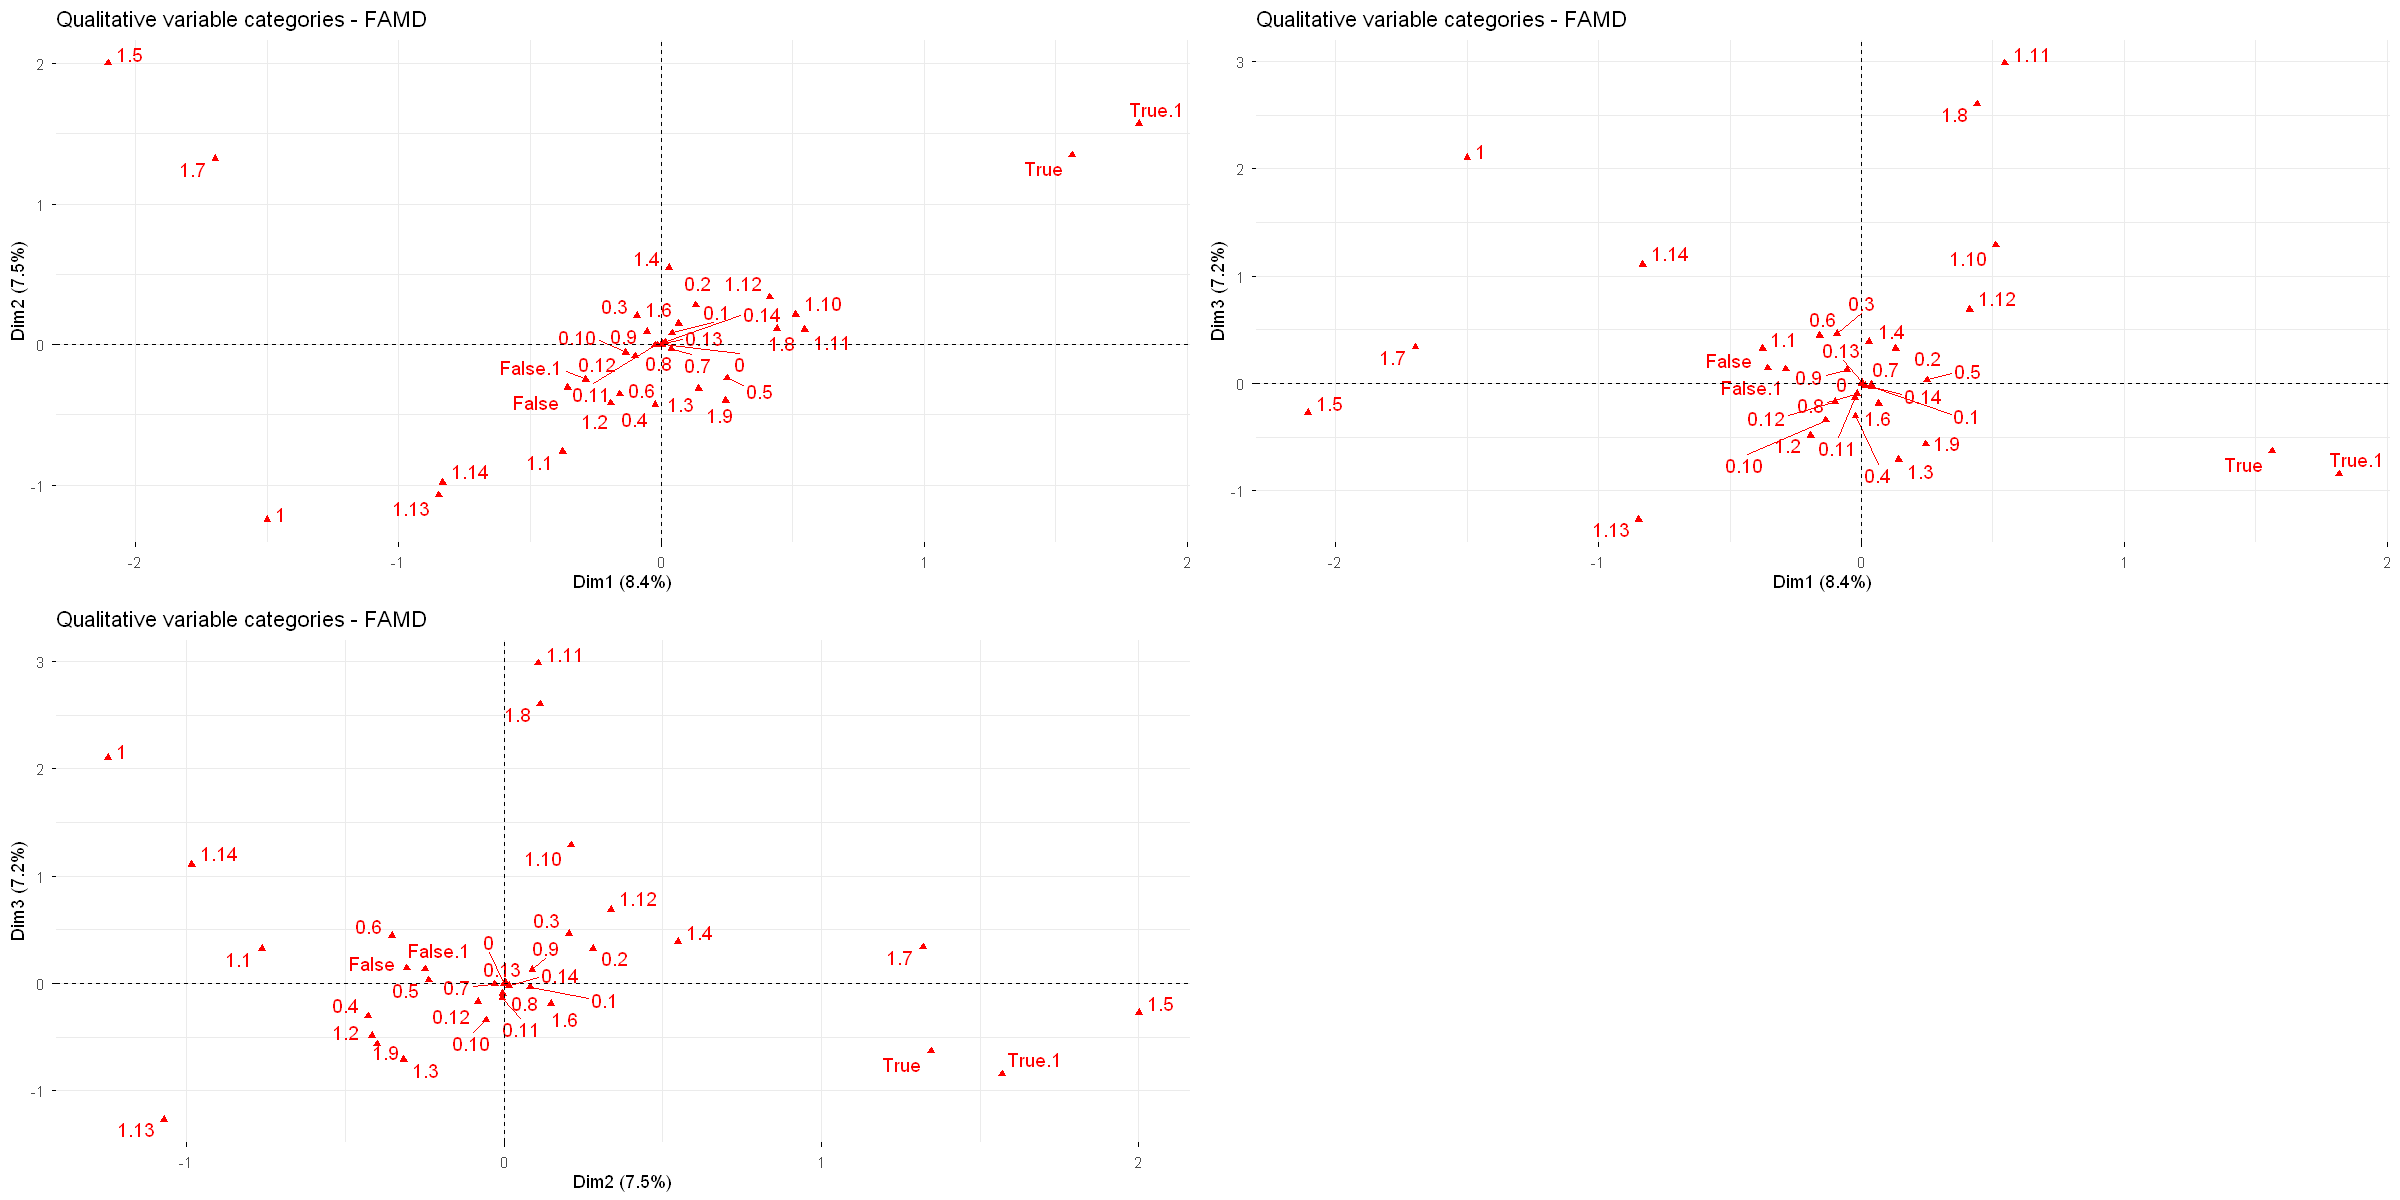

In [161]:
options(repr.plot.width = 20, repr.plot.height = 10)
vql1<-fviz_famd_var(res_famd_succes, choice = "quali", repel = TRUE)
vql2<-fviz_famd_var(res_famd_succes, choice = "quali", repel = TRUE,axes=c(1,3))
vql3<-fviz_famd_var(res_famd_succes, choice = "quali", repel = TRUE,axes=c(2,3))
grid.arrange(vql1,vql2,vql3,ncol=2)

Pour la cellule suivante, nous avons garder que c'est deux graphes car c'est ceux montraient un intérêt plus important pour l'étude.

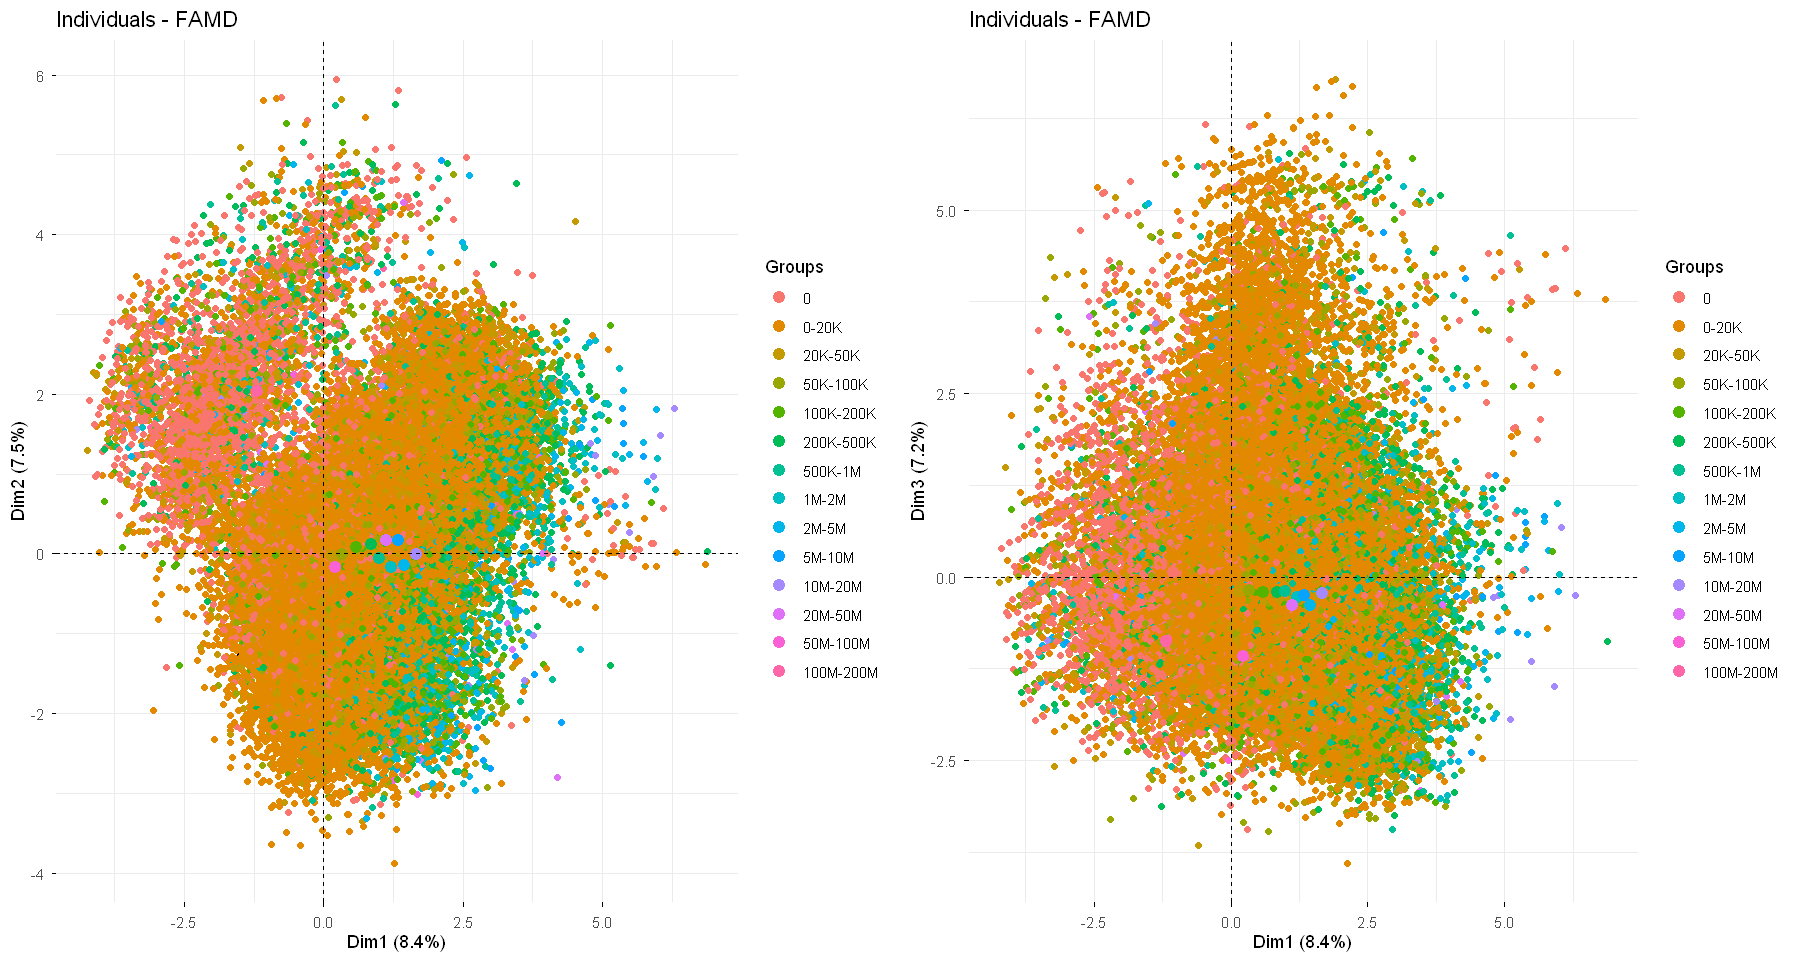

In [102]:
i1<-fviz_famd_ind(res_famd_succes, repel = F,habillage =data_famd_succes$Estimated.owners,label="none",axes=c(1,2))
i2<-fviz_famd_ind(res_famd_succes, repel = F,habillage =data_famd_succes$Estimated.owners,label="none",axes=c(1,3))

grid.arrange(i1,i2,ncol=2)

**Conclusion**: 

Le premier axe d'analyse met en évidence ce qui définit véritablement le succès et l'envergure d'un jeu sur Steam. Visuellement, le graphique des individus révèle une transition : les titres à faible audience (moins de 20 000 joueurs) s'agglutinent sur le côté gauche, tandis que les gros succès commerciaux (de 10 à 200 millions de joueurs) se concentrent systématiquement sur le côté droit. Cette dynamique de réussite, confirmée par le fort volume de recommandations, est directement propulsée par deux éléments concrets : la quantité de langues disponibles et le nombre de contenus additionnels (*DLC*). Cela démontre que l'ampleur du succès dépend bien moins du genre du jeu que de son passage à l'échelle commerciale, rendu possible par une accessibilité internationale et un suivi régulier du contenu.

Le deuxième axe illustre quant à lui le modèle économique et l'effort technique du studio. Il sépare de façon très nette les productions dites "standards" (généralement exclusives à *Windows* et à prix classique) des productions "premium". Ces dernières se démarquent par un prix de vente plus élevé, une infrastructure *Free To Play*, ou encore un effort d'intsallation sur les systèmes *Ma*c et *Linux*. Toutefois, l'analyse montre que cet effort technique et tarifaire sert uniquement à positionner le jeu sur un segment de marché précis. Ce n'est en aucun cas une garantie de ventes : un jeu vendu plus cher ou compatible *Linux* ne se dirige pas automatiquement vers la zone des grands succès commerciaux.

Pour conclure, le jeu à succès type sur Steam n'est pas défini par son genre (*Indie*, *Action* ect..). Il se caractérise avant tout par un investissement massif dans l'internationalisation (beaucoup de langues) et la le nombre l'enrichissement continu du contenu (*DLC*). Le prix de vente et la disponibilité sur Mac ou Linux sont des choix secondaires : ils différencient le jeu des autres, mais ce n'est pas ce qui fait exploser les ventes.


Maintenant que nous avons réussi à trouver que les variables *Language.count* et *LDLC.count* permettaient aux jeux de devenir connus et d'avoir beaucoup d'utilisateurs (*Estimated.owners*) et de bonnes recommendations(*LRecommendations*) et non pas d'un genre en particulier ou bien du prix du jeux, nous allons rentrer dans la deuxième partie de notre étude: c'est à dire, parmi les jeux vidéos ayant du succès, peut-on établir des classes avec des caractéristiques précises par tranches de succès?

## Parmi les jeux à succès, est-il possible d'établir différentes typologies de réussite ?

Dans cette partie, nous allons restreindre notre échantillon aux jeux ayant plus de 50 000 propriétaires estimés, seuil que nous retenons ici comme indicateur de succès. Afin de répondre à cette problématique, nous procéderons en deux étapes : d'abord, nous regrouperons les jeux en clusters à partir des variables quantitatives après avoir effectué une ACP (Analyse par Composantes Principales). Ensuite, nous caractériserons ces groupes en utilisant l'ensemble des variables afin de mettre en lumière les spécificités de chaque profil de succès identifié.

In [103]:
#Création du jeux de données populaire
data.pop <- data_ready %>% filter(!(Estimated.owners %in% c("0", "0-20K","20K-50K")))

In [104]:
dim(data.pop)

[1] 14132    28

Ce sous-ensemble de données contient donc 14 132 jeux.

### Analyse par Composantes Principales

On sélectionne seulement les variables quantitatives afin de réaliser l'ACP.

In [107]:
data.pop.quanti = data.pop %>% dplyr::select(where(is.numeric))

In [108]:
summary(data.pop.quanti)

    Discount      Metacritic.score   User.score        Achievements    
 Min.   :  0.00   Min.   : 0.00    Min.   : 0.00000   Min.   :   0.00  
 1st Qu.:  0.00   1st Qu.: 0.00    1st Qu.: 0.00000   1st Qu.:   0.00  
 Median : 33.50   Median : 0.00    Median : 0.00000   Median :  18.00  
 Mean   : 35.48   Mean   :16.36    Mean   : 0.01521   Mean   :  39.92  
 3rd Qu.: 70.00   3rd Qu.: 0.00    3rd Qu.: 0.00000   3rd Qu.:  39.00  
 Max.   :100.00   Max.   :97.00    Max.   :77.00000   Max.   :9821.00  
 Average.playtime.two.weeks Median.playtime.two.weeks   LPositive     
 Min.   :    0.00           Min.   :    0             Min.   : 0.000  
 1st Qu.:    0.00           1st Qu.:    0             1st Qu.: 5.081  
 Median :    0.00           Median :    0             Median : 6.562  
 Mean   :   96.48           Mean   :  104             Mean   : 6.388  
 3rd Qu.:    0.00           3rd Qu.:    0             3rd Qu.: 7.901  
 Max.   :20088.00           Max.   :20088             Max.   :15.849  

,eigenvalue,percentage of variance,cumulative percentage of variance
comp 1,5.50217195,36.6811463,36.68115
comp 2,1.94063575,12.9375717,49.61872
comp 3,1.04618752,6.9745835,56.59330
comp 4,1.01238677,6.7492451,63.34255
comp 5,0.99346126,6.6230751,69.96562
comp 6,0.96215035,6.4143357,76.37996
comp 7,0.89729851,5.9819900,82.36195
comp 8,0.76216833,5.0811222,87.44307
comp 9,0.71921228,4.7947486,92.23782
comp 10,0.53348540,3.5565693,95.79439


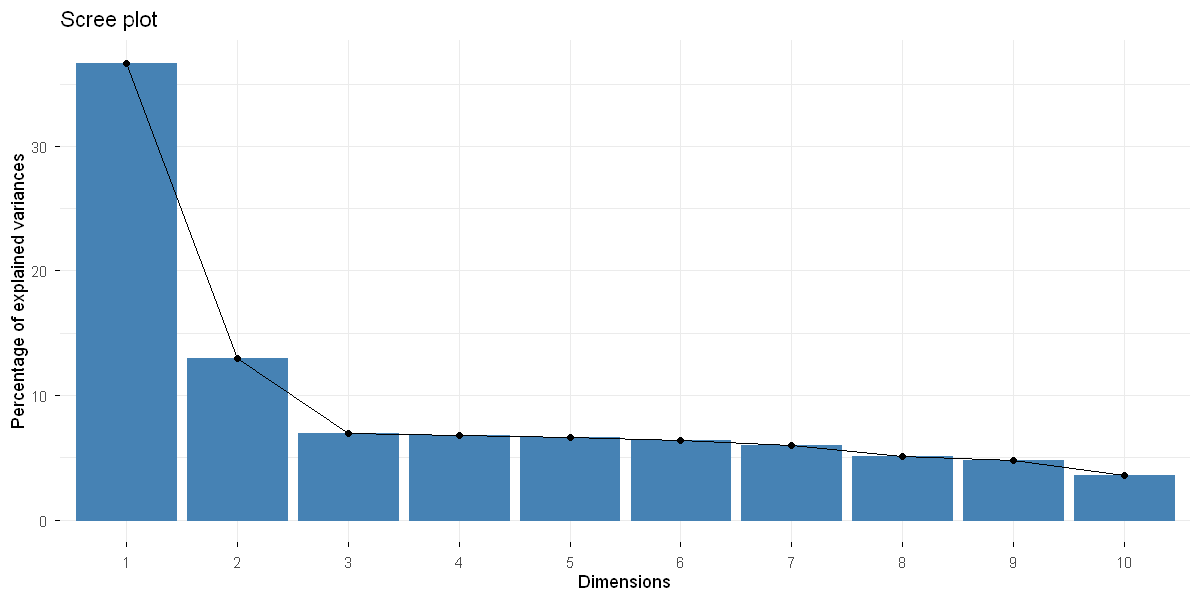

In [109]:
options(repr.plot.width = 10, repr.plot.height = 5)
pca.pop <- PCA(data.pop.quanti,ncp=15, scale.unit = TRUE, graph = FALSE)
fviz_eig(pca.pop)
pca.pop$eig

On observe que la première composante principale explique à elle seule 36 % de la variance, ce qui témoigne d'une forte corrélation entre les variables quantitatives. Pour la suite de l'étude, nous avons choisi de retenir les **7 premières dimensions** ce qui permet d'atteindre un seuil de **80 %** de variance expliquée.

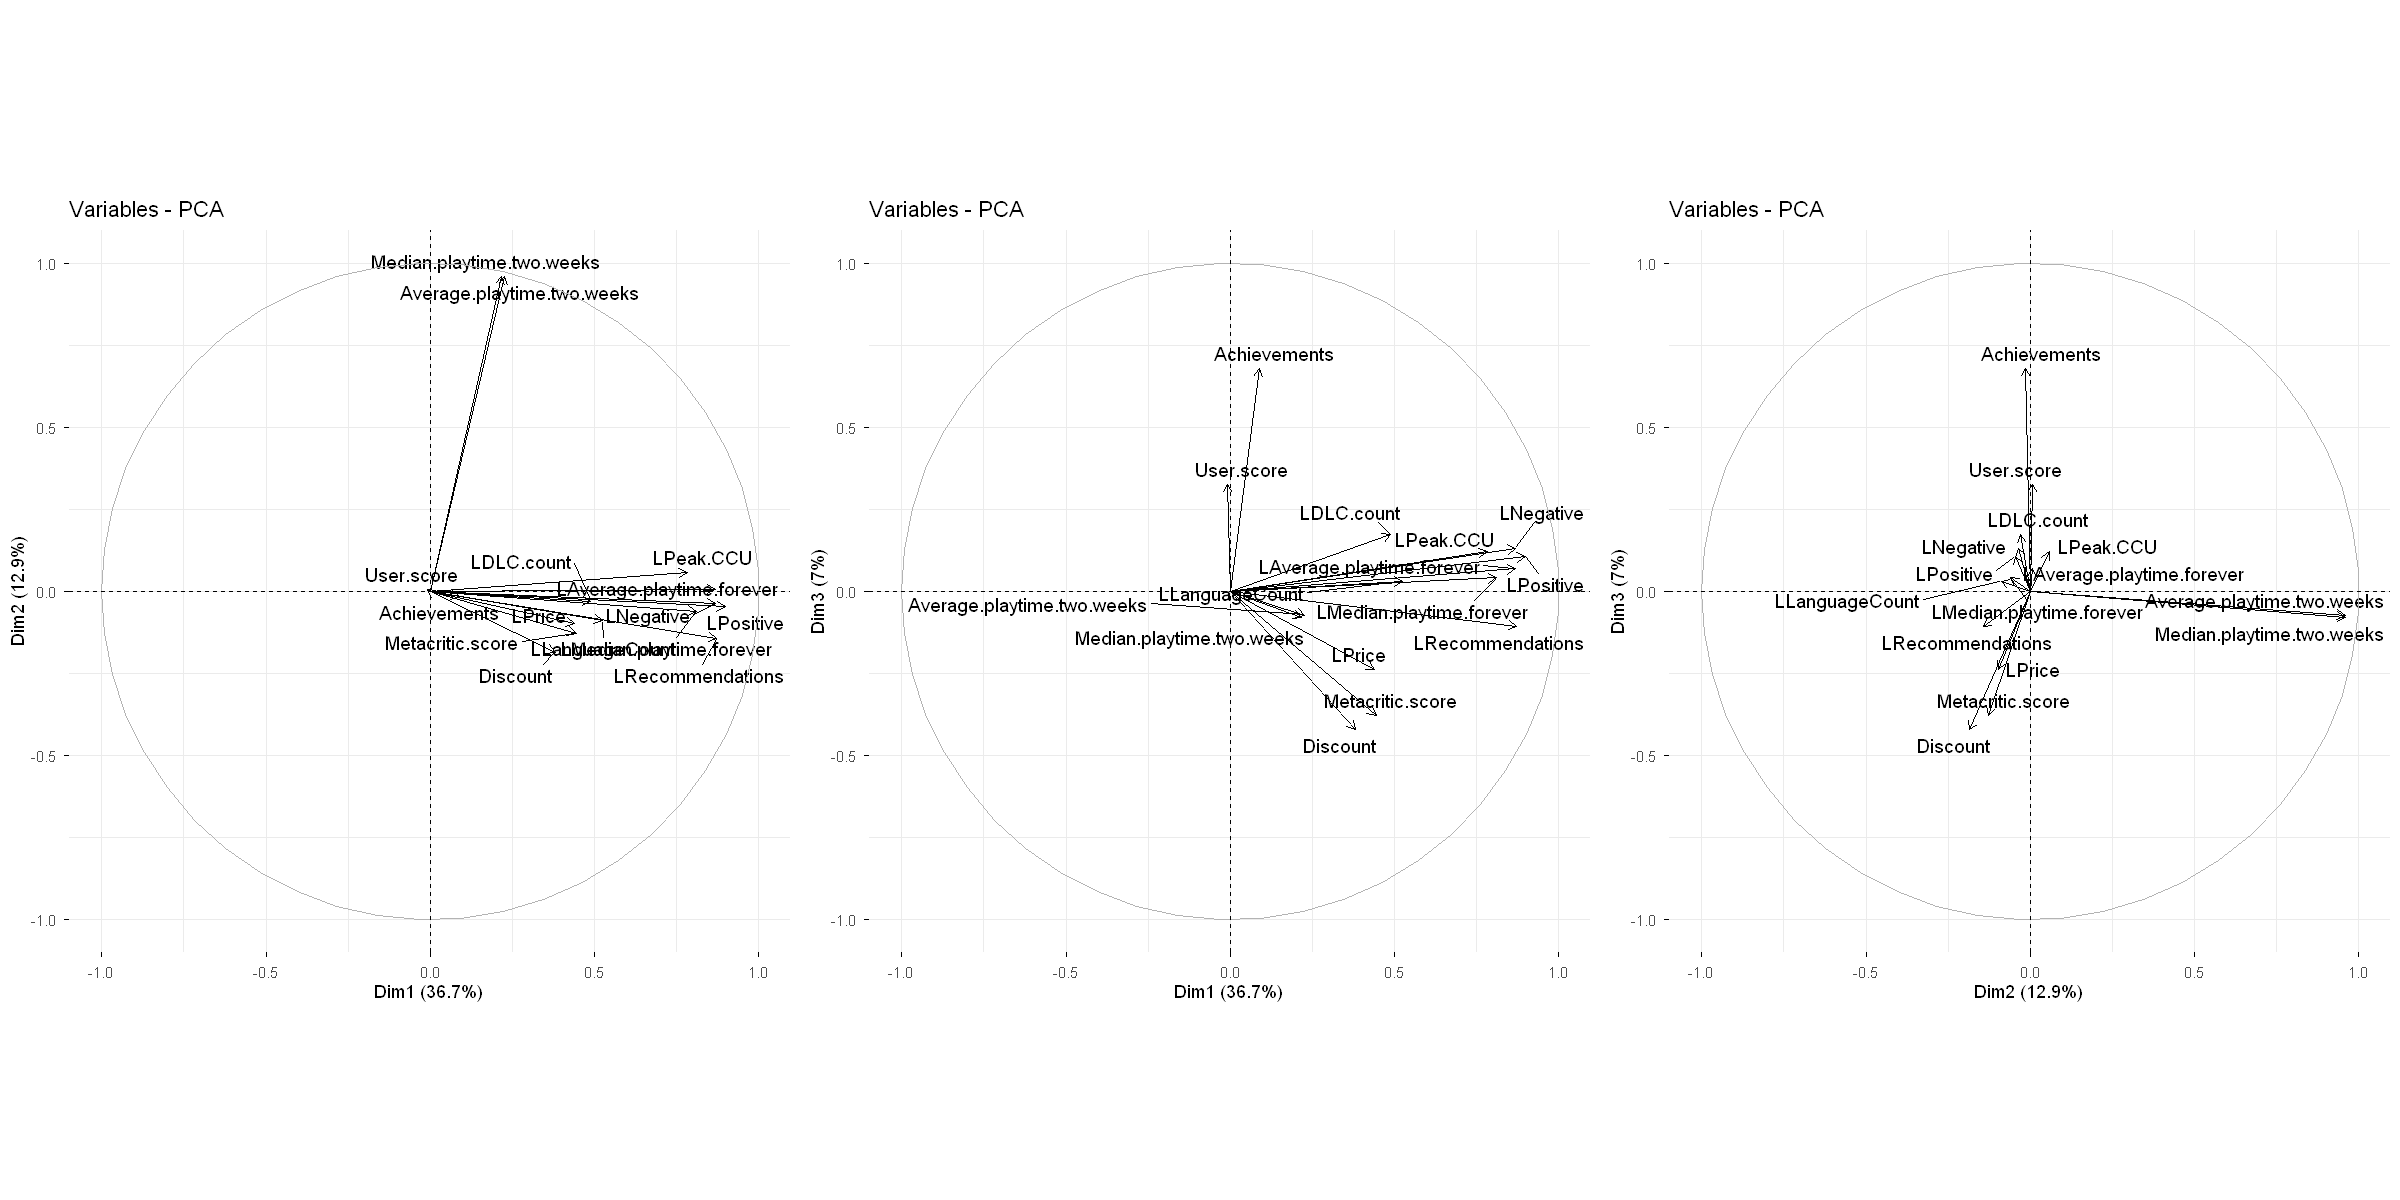

In [110]:
options(repr.plot.width = 20, repr.plot.height = 10)
g1=fviz_pca_var(pca.pop,axes = c(1,2),repel=TRUE)
g2=fviz_pca_var(pca.pop,axes = c(1,3),repel=TRUE)
g3=fviz_pca_var(pca.pop,axes = c(2,3),repel=TRUE)
grid.arrange(g1,g2,g3,ncol=3)

On retrouve des axes semblables à ceux de l'étude sur l'ensemble des jeux (voir notebook_python.ipynb). Cette similarité confirme la stabilité des corrélations entre les variables: la structure du marché reste la même pour les jeux à succès. Plus précisement:
- L'axe 1 semble caractériser le succès. Il traduit l'échelle de notoriété avec les variables *LPeak.CCU*, *LPositive*, *LNegative*, *LRecommendations*, *LAverage.playtime.forever*.
- L'axe 2 caractérise les jeux qui sont actuellement joué avec les variables *Average.playtime.two.weeks* et *Median.playtime.two.weeks*.
- L'axe 3 semble opposer les titres riches en objectifs à débloquer (*Achievements*) et appréciés des utilisateurs (*User.score*), aux jeux ayant une reconnaissance critique (*Metacritic.score*) et de plus de promotions (*Discount*). Notons tout de même que la variable *User.score* ne semble pas très bien représentée (longueur de la flèches) ce qui sera à prendre en compte lors de l'interprétation.

### Clustering

L'objectif de cette étude étant de caractériser les différentes formes de succès sur Steam, nous avons choisi d'utiliser du clustering. Cette segmentation a été réalisée sur les 7 premières composantes principales de notre ACP. Ce choix permet de réduire la dimensionnalité (passant de 15 variables à 7 axes) et de ne conserver que l'information essentielle de nos données en conservant 80 % de l'inertie totale.

#### Choix de la méthode de clustering

En ce qui concerne le choix de la méthode, nous avons écarté l'algorithme de K-means. Cette méthode cherche à construire des groupes autour de centres de gravité, or nos données semblent plutôt non-convexes. De plus, les K-means sont particulièrement sensibles aux valeurs aberrantes. Nous avons donc privilégié le Modèle de Mélange Gaussien (GMM). Cette méthode est moins rigide en terme de forme et de densité. Elle nous semble la plus apte à capturer les nuances de succès qui se chevaucheraient. De plus, nous avons choisi de comparer le GMM à la Classification Ascendante Hiérarchique (CAH). Cependant il faut noter que la CAH dépend du choix de la fonction de lien, avec les lien simple et du lien complet souvent sensiblent au bruit et le critère de Ward ayant une tendance à favoriser des classes sphériques. Nous espérons tout de même que cette double approche nous permettra de vérifier si les profils identifiés sont stables ou s'ils dépendent uniquement de l'algorithme choisi.

In [111]:
set.seed(22)
resBIC = Mclust(pca.pop$ind$coord[,1:7], G=1:10)

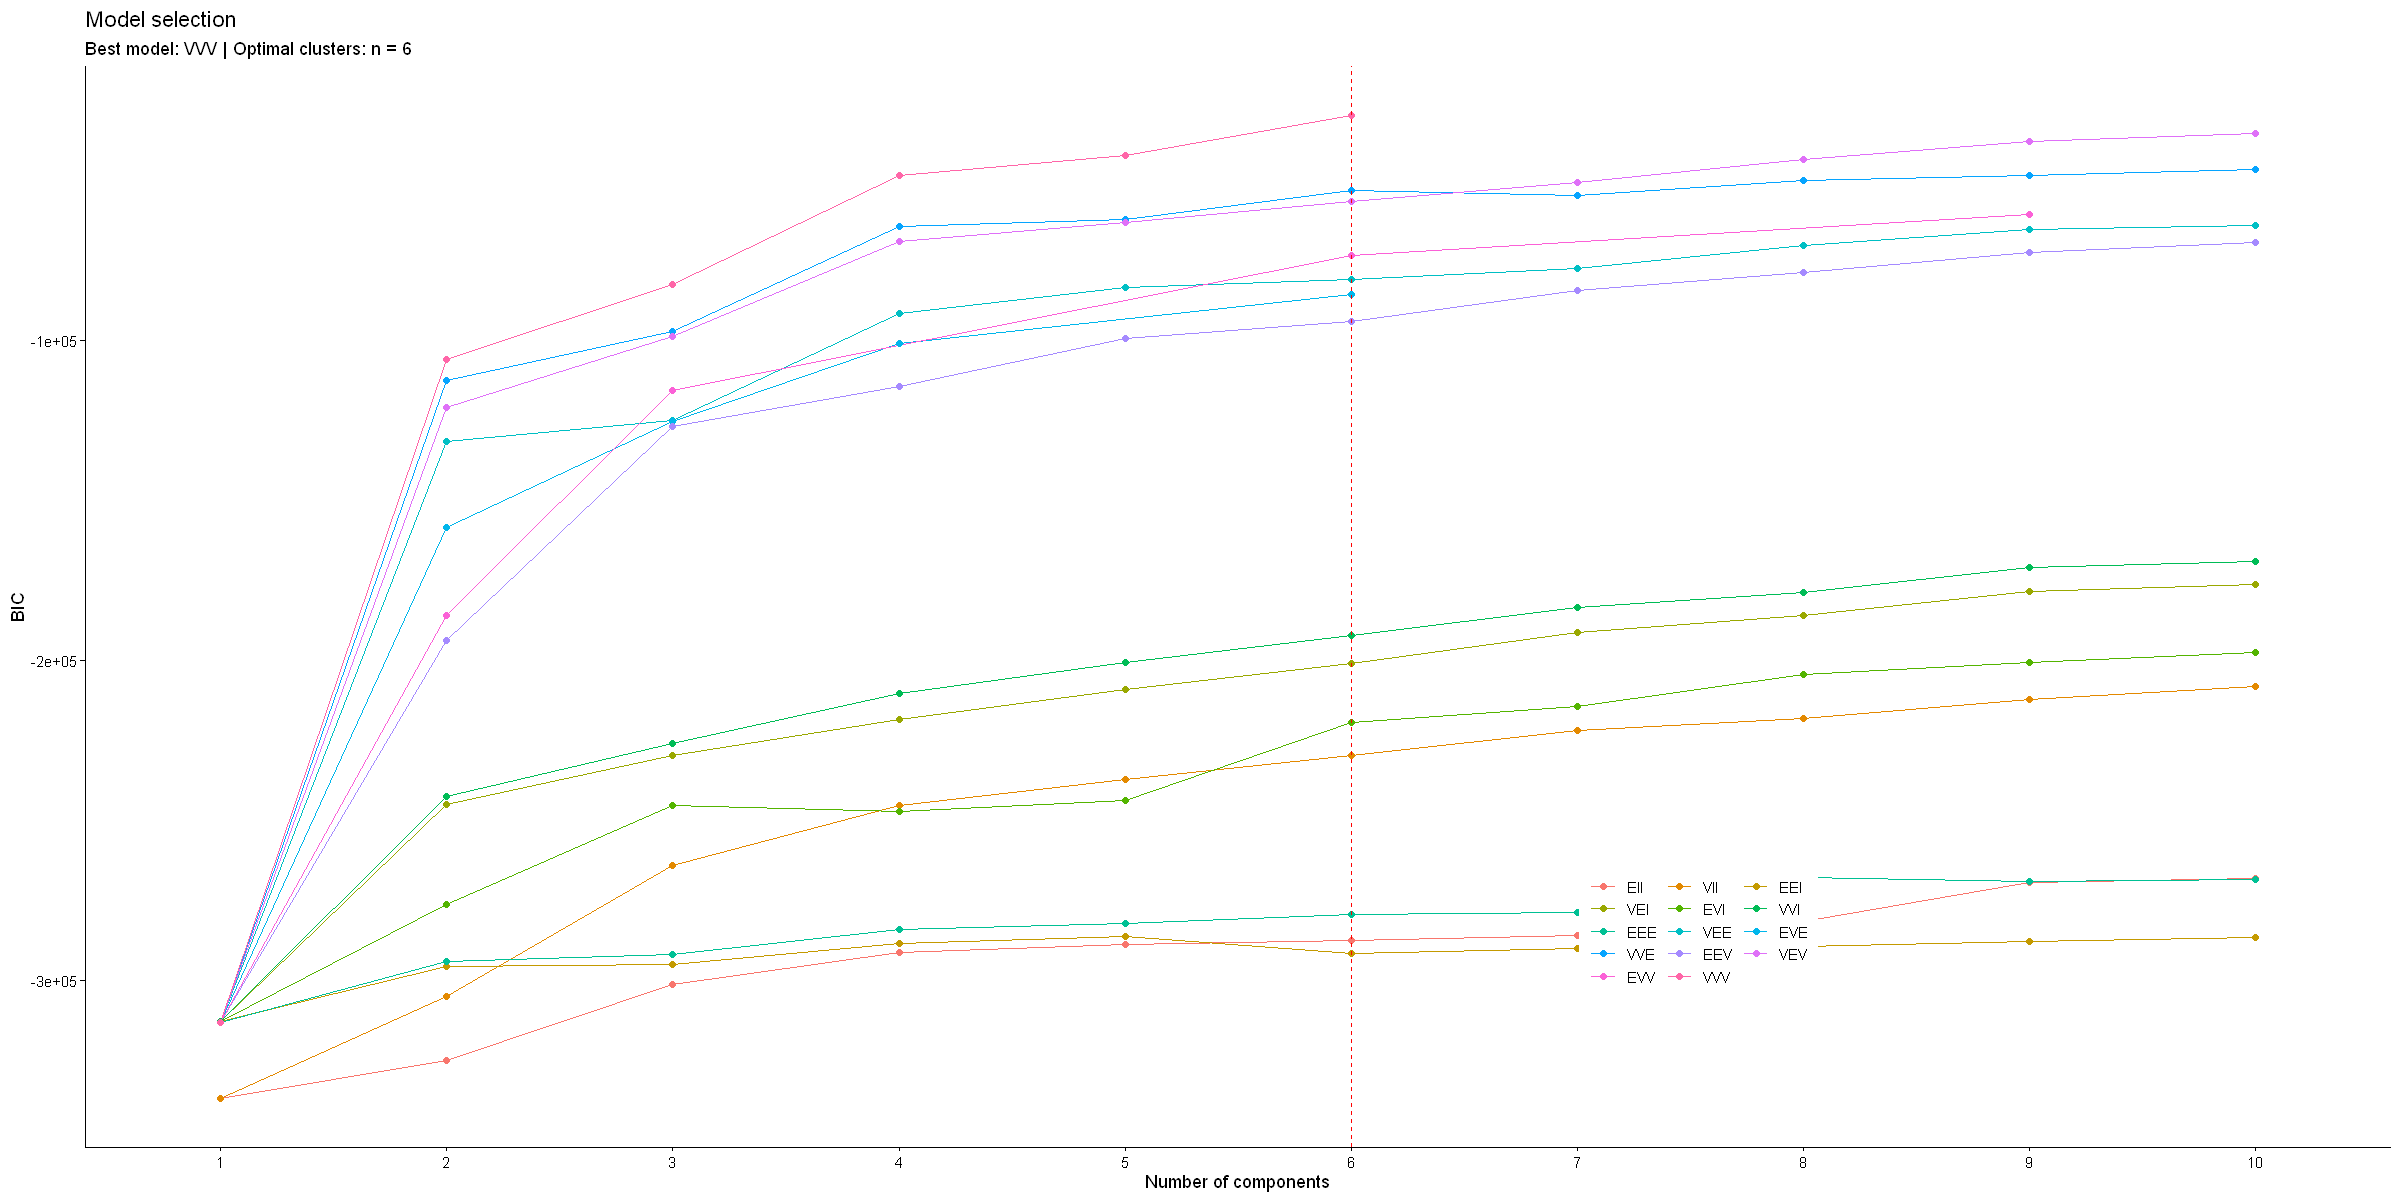

In [112]:
options(repr.plot.width = 20, repr.plot.height =10)
fviz_mclust(resBIC, what="BIC")

Nous avons utilisé le critère BIC lors de séléction de modèle pour le GMM et on obtient le modèle VVV avec 6 clusters. "VVV" (varying volume, shape, and orientation) signifie que l'algorithme autorise chaque cluster à avoir son propre volume, sa propre forme et sa propre orientation spatiale. Ce résultat confirme que les différents types de succès sur Steam ne suivent pas une règle géométrique unique et donc qu'une méthode qui imposerait des clusters sphériques et identiques n'est pas adaptée. 

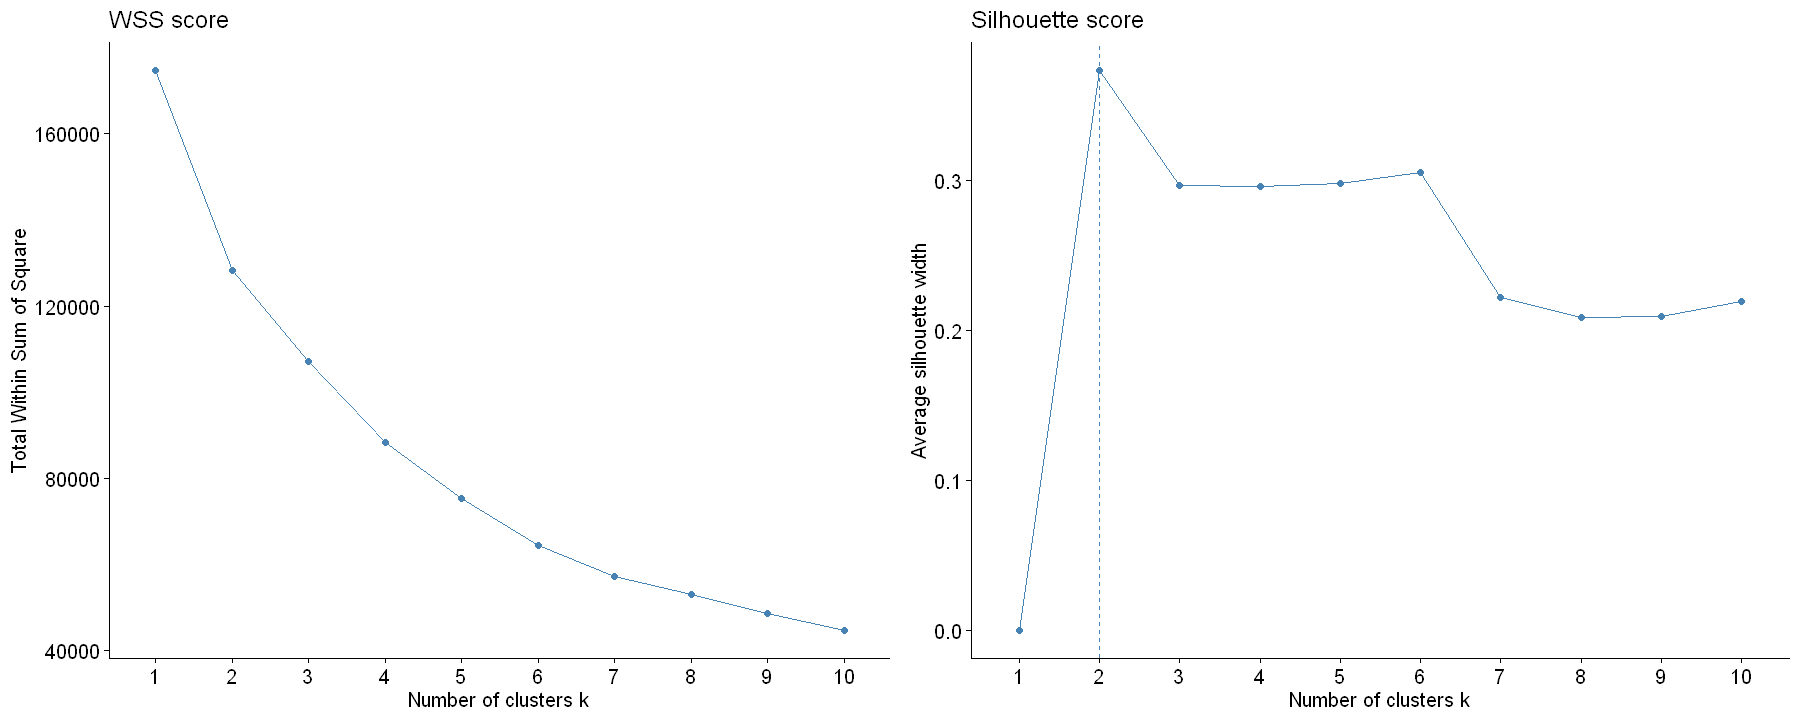

In [150]:
#Nombre de clusters pour CAH
options(repr.plot.width = 15, repr.plot.height = 6)
hcut <- function(x, k, ...) if(k == 1) list(cluster = rep(1, nrow(x))) else factoextra::hcut(x, k, ...)

p1 = fviz_nbclust(pca.pop$ind$coord[,1:7], FUNcluster=hcut, method="wss") + ggtitle("WSS score")
p2 = fviz_nbclust(pca.pop$ind$coord[,1:7], FUNcluster=hcut, method="silhouette") + ggtitle("Silhouette score")
grid.arrange(p1,p2,ncol=2)

Le choix du nombre de cluster pour la CAH n'est pas evident. La courbe du score WSS ne présente pas de "coude" nettement marqué, ce qui suggère une transition graduelle entre les profils de succès. Bien que le score de Silhouette suggère un nombre de 2 clusters, cela semble trop peu pour répondre à notre problématique. Nous optons alors pour un nombre de 6 cluster présente non seulement un pic secondaire de stabilité sur le score Silhouette et nous permettra de comparer les résultats à ceux du GMM.

#### Application des méthodes

On commence par la CAH.

In [122]:
#CAH pour les differents liens
distances = dist(pca.pop$ind$coord[,1:7], method="euclidean")

hclustaverage = hclust(distances, method="average")
hclustward = hclust(distances,method="ward.D")
hclustsingle = hclust(distances, method="single")
hclustcomplete = hclust(distances,method="complete")

K = 6
reshclust_average = cutree(hclustaverage, K)
reshclust_ward = cutree(hclustward, K)
reshclust_complete = cutree(hclustcomplete, K)
reshclust_single = cutree(hclustsingle, K)

In [123]:
cluster_cah_average = data.frame(table(reshclust_average))
cluster_cah_ward = data.frame(table(reshclust_ward))
cluster_cah_complete = data.frame(table(reshclust_complete))
cluster_cah_single= data.frame(table(reshclust_single))

cluster_cah_average
cluster_cah_ward
cluster_cah_complete 
cluster_cah_single


reshclust_average,Freq
<fct>,<int>
1,14067
2,40
3,20
4,3
5,1
6,1


reshclust_ward,Freq
<fct>,<int>
1,2032
2,1216
3,4148
4,2706
5,1735
6,2295


reshclust_complete,Freq
<fct>,<int>
1,14073
2,34
3,20
4,3
5,1
6,1


reshclust_single,Freq
<fct>,<int>
1,14127
2,1
3,1
4,1
5,1
6,1


Les effectifs des clusters sont très déséquilibrés pour les méthodes de lien simple, complet et moyen, qui échouent à structurer le jeu de données en isolant des individus atypiques. Ce phénomène confirme que les données ne sont pas nettement séparables, mais que les individus sont étroitement liés les uns aux autres. On choisit donc de conserver uniquement les clusters obtenues avec la distance ward par la suite.

On passe au clustering avec GMM.

  Var1 Freq
1    1 2683
2    2 1470
3    3 1516
4    4 6212
5    5 2039
6    6  212


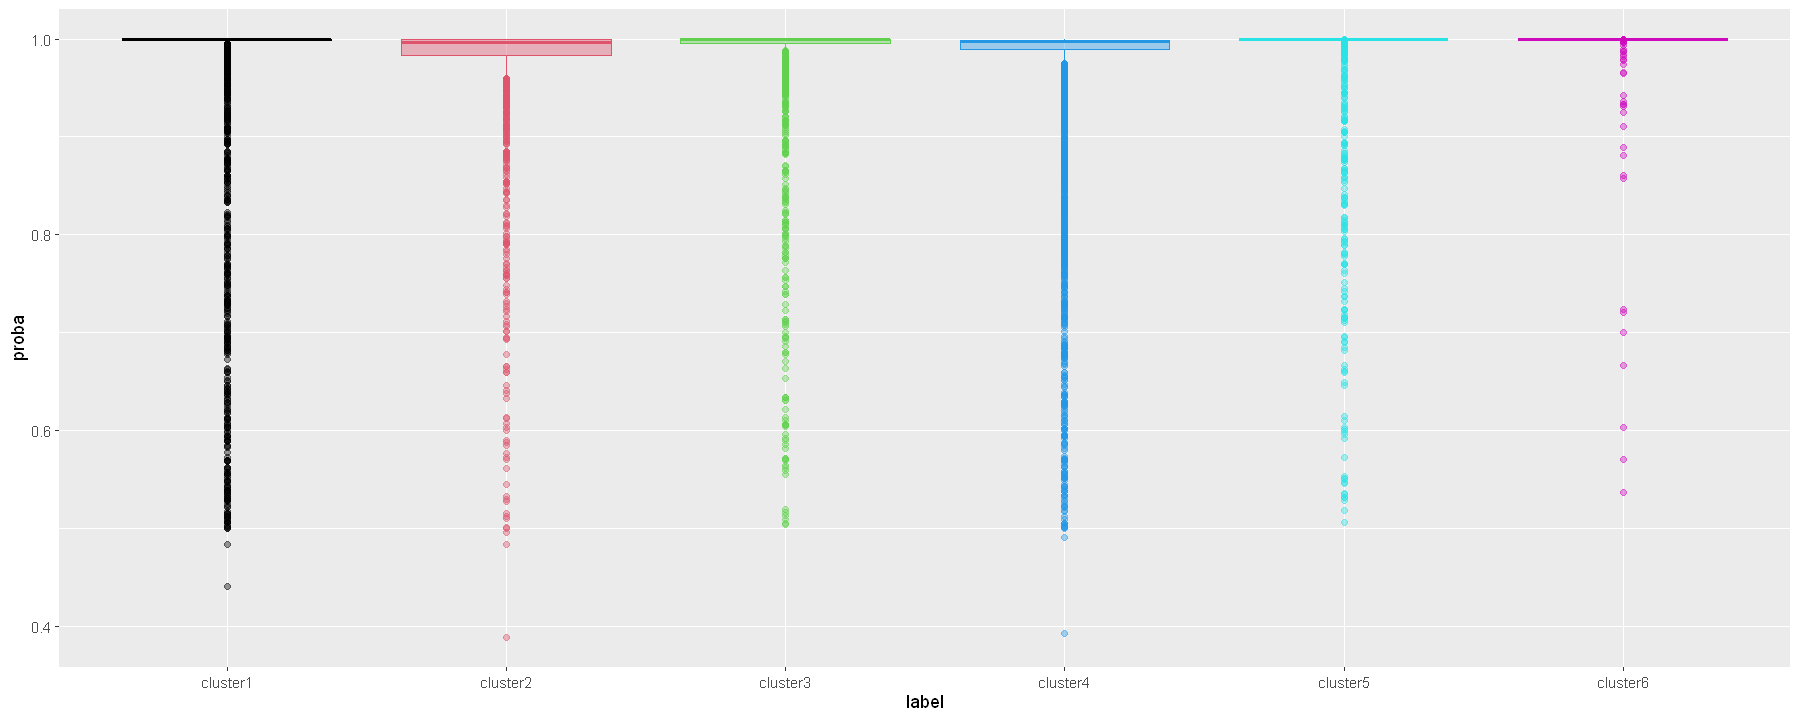

In [151]:
options(repr.plot.width = 15, repr.plot.height = 6)
set.seed(22)
aux = data.frame(
    label = paste("cluster", gmm.pop$classification, sep=""), 
    proba = apply(gmm.pop$z, 1, max))
    
gmm.pop = Mclust(pca.pop$ind$coord[,1:7], G=K, modelNames = "VVV")

ggplot(aux, aes(x=label, y=proba)) + 
    geom_boxplot(colour=1:K, fill=1:K, alpha=.4)

print(data.frame(table(gmm.pop$classification)))


Ce graphique présente les probabilités d'appartenance des jeux à leur cluster assigné. On observe que pour la grande majorité des jeux, la probabilité est proche de 1, ce qui nous conforte dans ce choix de modèle. Quelques points se situent plus bas, ce qui illustre encore le fait que nos jeux ne soient pas parfaitement séparables.

#### Comparaison entre les deux classifications obtenues

On commence par réaliser une CA pour visualiser de façon rapide si les clusters des deux méthodes sont semblables.

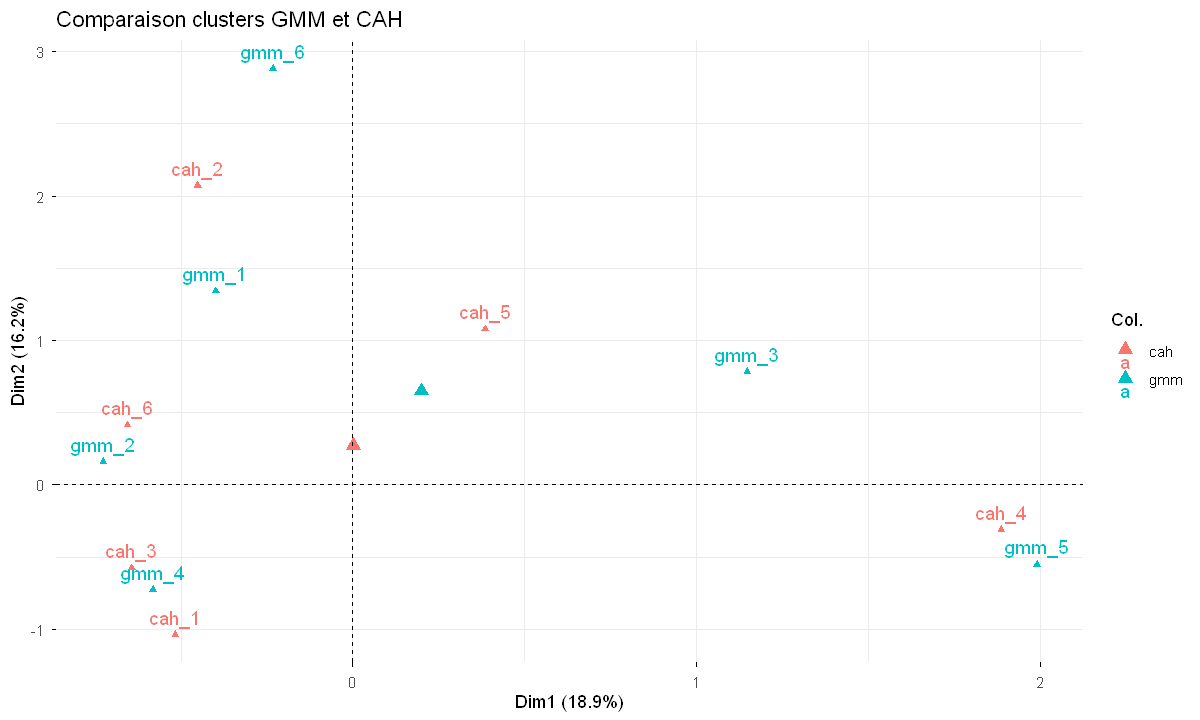

In [125]:
options(repr.plot.width = 10, repr.plot.height = 6)
tbl = data.frame(cah = as.factor(reshclust_ward),
                 gmm = as.factor(gmm.pop$classification))

ca_comp= MCA(tbl[,c('cah','gmm')], graph=FALSE)

fviz_mca_var(ca_comp , col.var = as.factor(rep(c('cah','gmm'), sapply(ca_comp $call$X, nlevels)))) + 
    labs(title = "Comparaison clusters GMM et CAH")

Pour avoir une idée plus précise du nombre de jeux communs entre les clusters on utilise une matrice de confusion.

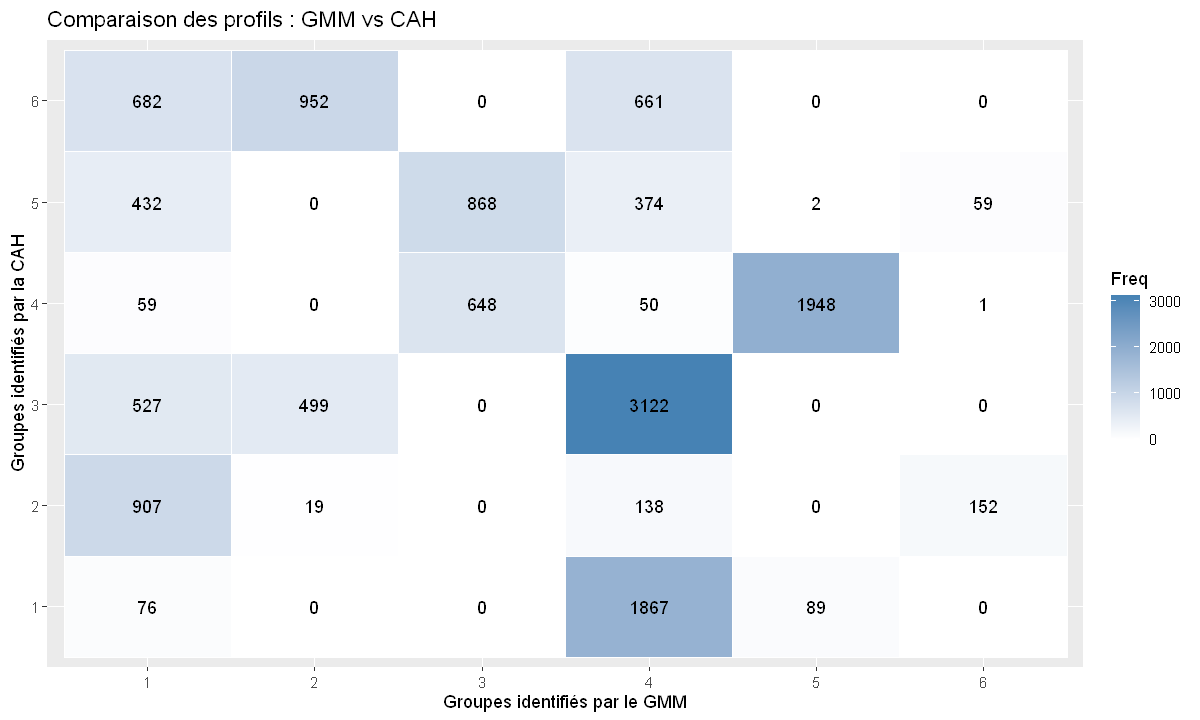

In [126]:
tab_freq <- table(cah = reshclust_ward, gmm = gmm.pop$classification)
df_comp = as.data.frame(tab_freq)

ggplot(df_comp, aes(x = gmm, y = cah, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq)) + 
  scale_fill_gradient(low = "white", high = "steelblue") +
  labs(title = "Comparaison des profils : GMM vs CAH",
       x = "Groupes identifiés par le GMM",
       y = "Groupes identifiés par la CAH") 

L'Analyse des Correspondances (CA) et la table des fréquences donnent le même résultat: les deux classifications sont bien différentes. On identifie tout de même l'intersection entre le cluster 4 du GMM et le cluster 3 de la CAH, que les deux méthodes identifient comme un groupe plutôt homogène. Il y a aussi une intersection entre le groupe 5 du GMM et le groupe 4 de la CAH. Cependant, en dehors de cela, les classifications ne se ressemblent pas. Ce décalage confirme qu'il est dur de trouver une frontière nette entre les profils de succès.


#### Interprétation des clusters

Pour simplifier l'étude, nous choisissons d'interpréter seulement les clusters obtenus avec le GMM. En effet, la sélection du modèle VVV confirme que les clusters ont des tailles variées, alors que le critère de Ward a tendance à favoriser des groupes de tailles similaires (comme nous l'avons observé avec plusieurs clusters autour de 2000 jeux). De plus, la rigidité de la CAH pourrait masquer des profils plus spécifiques à faibles effectifs (comme le cluster 6 du GMM). Enfin, l'analyse des probabilités d'appartenance du GMM montre la robustesse de l'affectation: on rapelle que la grande majorité des jeux présente un score proche de 1.

**Caractérisation par les variables quantitatives**

L'étude des variables quantitatives permet de comprendre la logique de construction des clusters. Nous allons d'abord analyser les moyennes de chaque groupe pour les différentes variables (profils moyens). Cela nous permettra d'isoler les caractéristiques numériques qui définissent chaque type de succès. Pour chaque cluster, nous affichons les écarts à la moyenne, car les calculs sont effectués sur des données centrées et réduites.

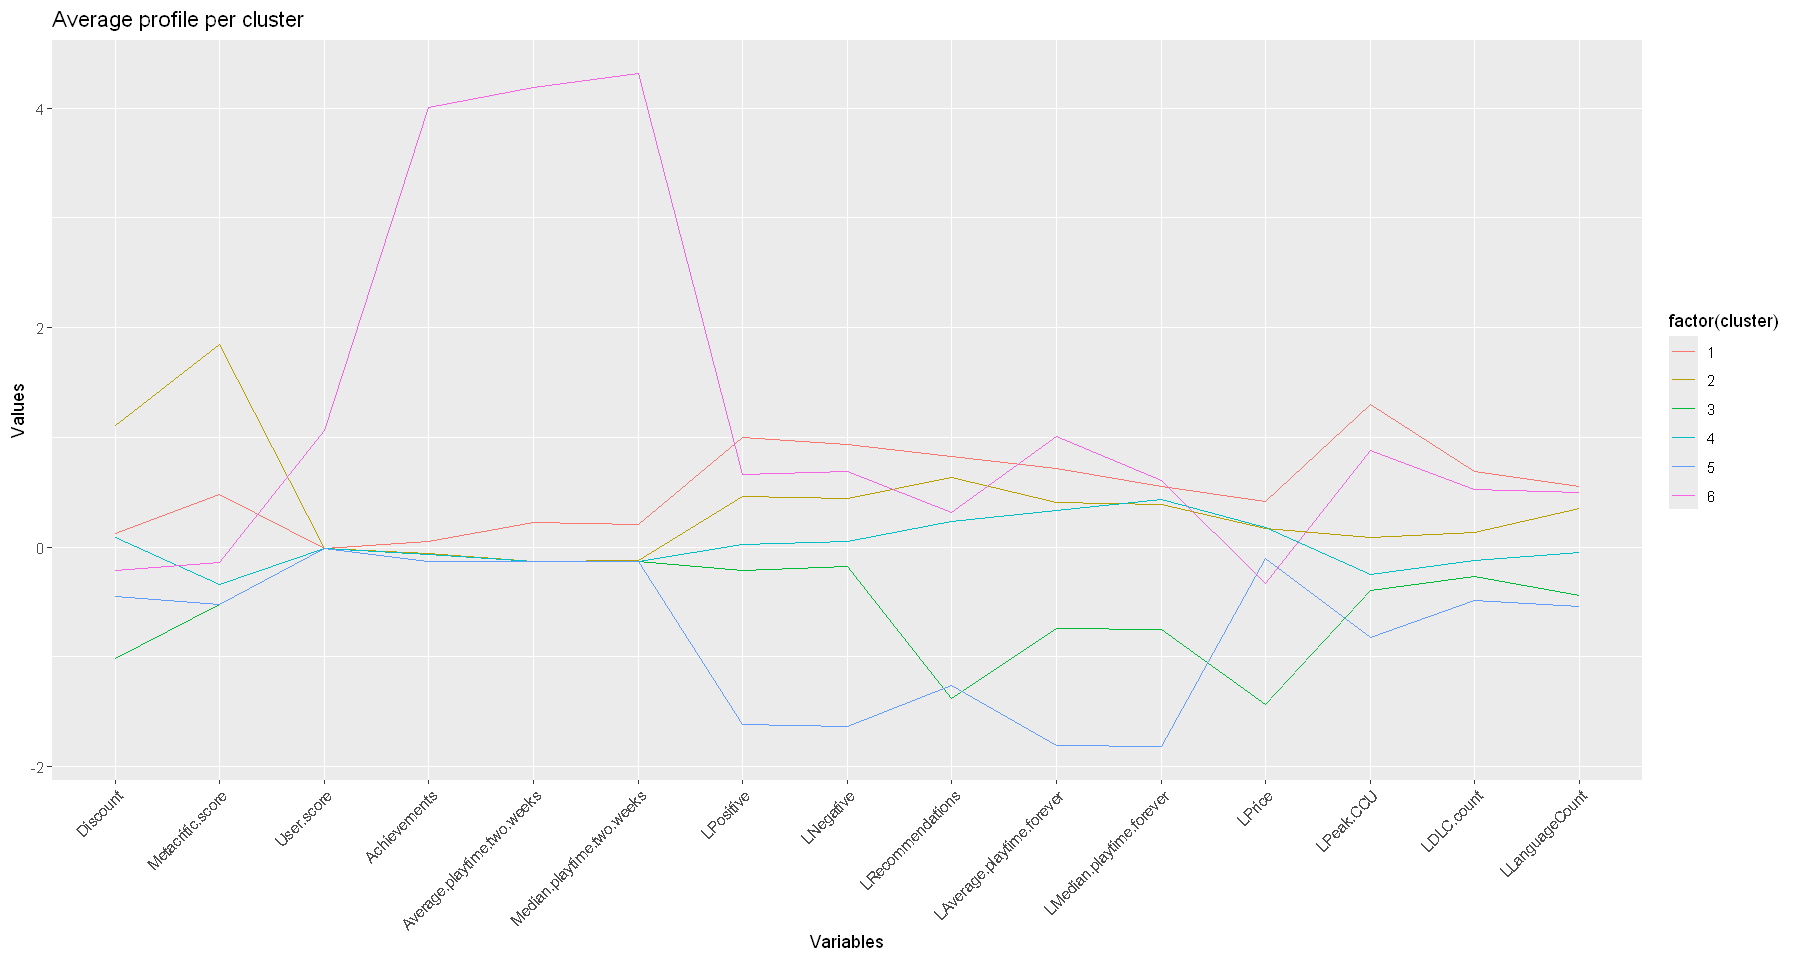

In [127]:
options(repr.plot.width = 15, repr.plot.height = 8)
data.pop.scale <- scale(data.pop.quanti) 

mean_profiles_gmm = aggregate(data.pop.scale, by = list(cluster = gmm.pop$classification), FUN = mean) #Calcule les moyennes par cluster
mean_profiles_gmm = melt(mean_profiles_gmm, id.vars = "cluster") #Transforme le tableau en 3 colonnes (cluster, variable et valeur)

ggplot(mean_profiles_gmm, aes(x = variable, y = value, color = factor(cluster), group = cluster)) +
  geom_line() +  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Average profile per cluster", x = "Variables", y = "Values")

L'examen des profils moyens permet d'identifier plusieurs groupes qui se détachent nettement de la moyenne globale :

- Le cluster 6 (rose) se distingue le plus des autres avec un pic massif sur le nombre d'Achievements et le temps de jeu récent (Playtime two weeks) mais aussi sur le long terme avec le playtime forever. Étonnamment, ce n'est pas le groupe qui obtient les meilleures caractéristiques de succès (recommandations et avis), et son prix reste inférieur à la moyenne.

- Le cluster 2 (vert kaki) se distingue principalement par un Metacritic score bien plus élevé que la moyenne. Toutefois, il ne représente pas les jeux avec le plus de succès, car ses variables de popularité (Recommendations, Positive, Peak CCU) ne sont que légèrement supérieures à la moyenne.

- Le cluster 1 (orange) semble représenter les jeux qui suscitent le plus d'engagement. Il possède le nombre de recommandations et d'avis le plus élevé, un temps de jeu supérieur à la moyenne et le Peak CCU le plus important du dataset. C'est sûrement les jeux au plus grand succès.

- Le cluster 5 (bleu foncé) regroupe les jeux les moins joués et les moins recommandés. On remarque cependant que leur prix reste proche de la moyenne, étant même supérieur à celui du cluster 6.

- Le cluster 3 (vert) est également en dessous de la moyenne pour l'ensemble des variables, ce groupe est tout de même plus joué que le précédent et suscite davantage d'avis (positifs comme négatifs). Son prix est, en revanche, bien plus bas que la moyenne.

En conclusion, il semble y avoir différents types de succès avec le succès classique représenté par le cluster 1. C'est le profil le plus complet avec des jeux qui sont appréciés et beaucoup joués. Puis il y a un succès basé sur le contenu (cluster 6). Le nombre élevé d'Achievements semble pousser les joueurs à passer énormément de temps sur le jeu pour les débloquer. Enfin, il y a le succès Metacritic avec le cluster 2.

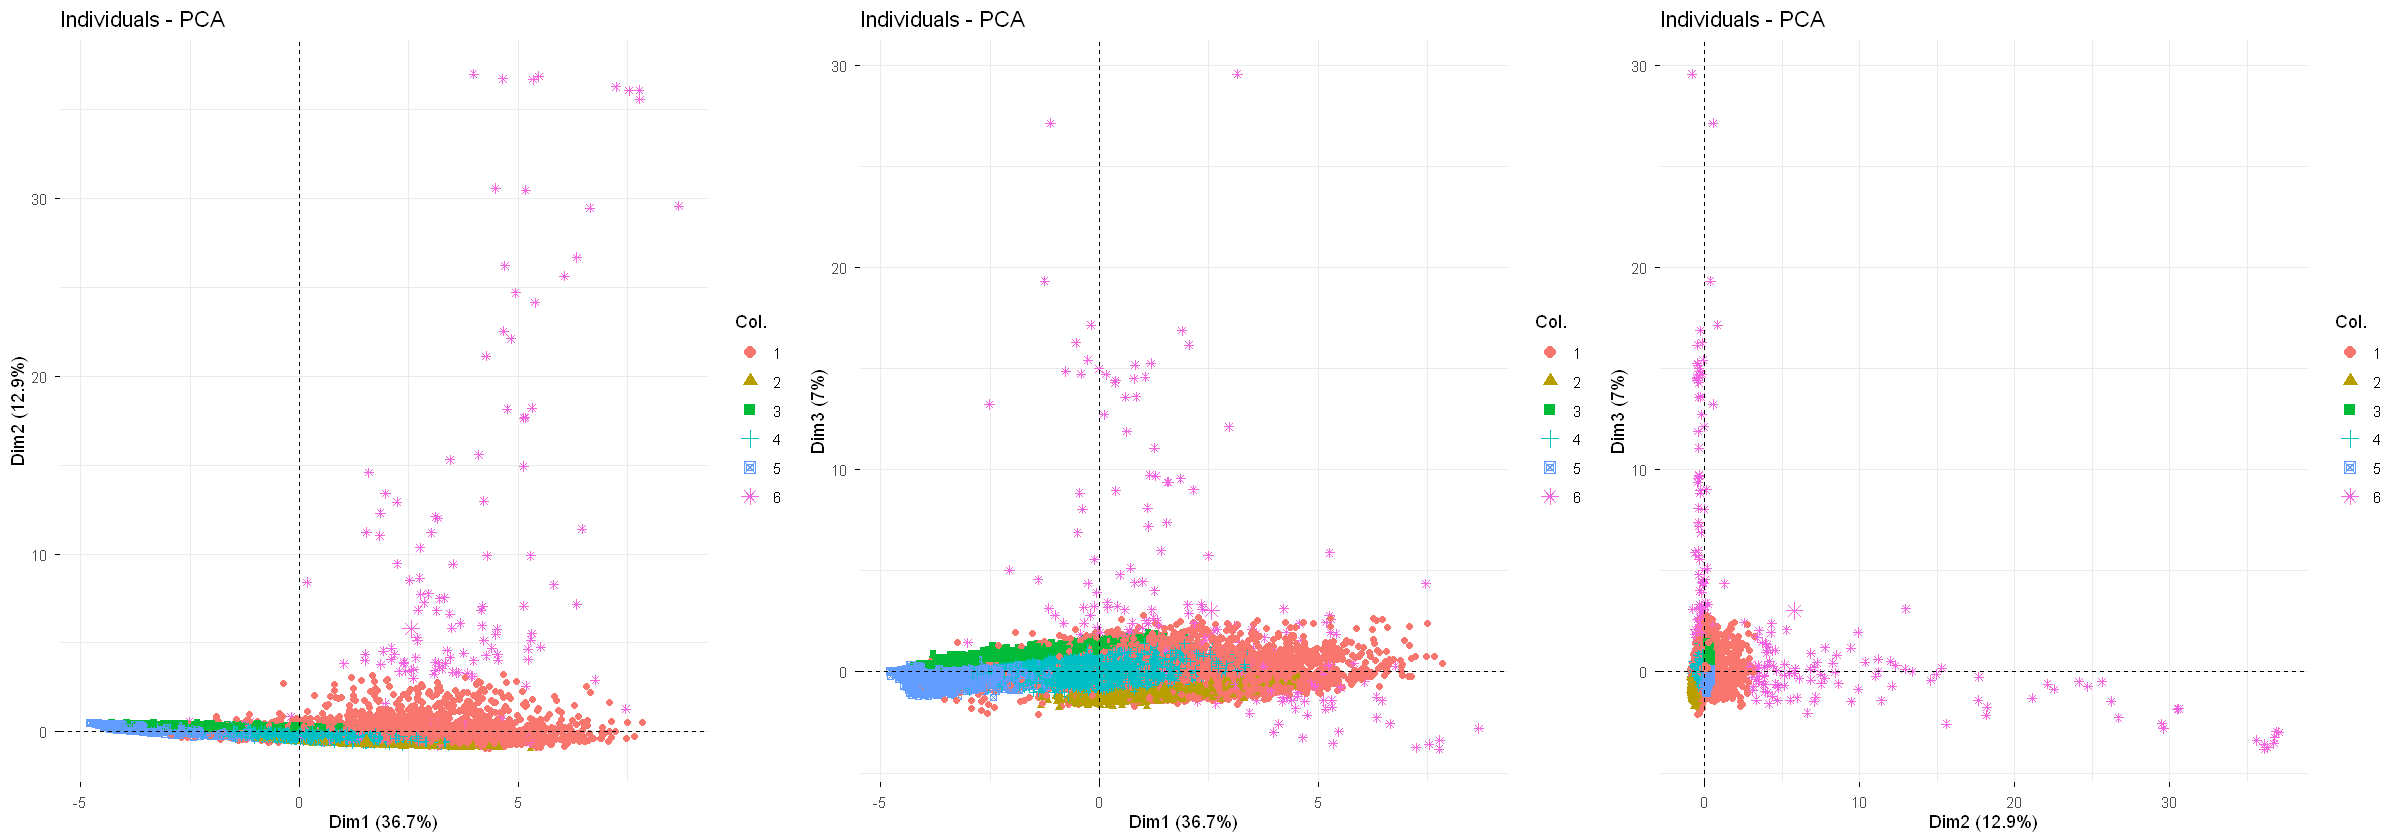

In [128]:
options(repr.plot.width = 20, repr.plot.height = 7)

grid.arrange(
    fviz_pca_ind(pca.pop, axes=c(1,2), geom = c("point"), col.ind=as.factor(gmm.pop$classification)),
    fviz_pca_ind(pca.pop, axes=c(1,3), geom=c("point"), col.ind=as.factor(gmm.pop$classification)),
    fviz_pca_ind(pca.pop, axes=c(2,3), geom=c("point"), col.ind=as.factor(gmm.pop$classification)),
    ncol=3)

En affichant les clusters sur les espaces de l'ACP des trois premières dimensions, on retrouve les mêmes conclusions, ce qui est rassurant. En effet, on rappelle que l'axe 1 (vers la droite) caractérise le succès avec les variables *LPeak.CCU*, *LPositive*, *LNegative*, *LRecommendations* et *LAverage.playtime.forever*. L'axe 2 est caractérisé par les temps de jeu récents (deux semaines précédant la collecte des données) et l'axe 3 est principalement expliqué par la variable *Achievements*.

On remarque alors que le cluster 1 est bien le plus à droite sur l'axe 1 (le plus de succès), tandis que le cluster 5 est le plus à gauche (moins de succès). On observe également que le cluster 6 s'étend sur les dimensions 2 et 3, ce qui est cohérent avec notre analyse précédente basée sur les profils moyens.

**Caractérisation par les variables qualitatives**

Nous allons maintenant chercher à interpréter les clusters à l'aide des variables qualitatives. Ces dernières n'ont pas été utilisées lors de la construction des groupes, elles servent donc ici de variables d'illustration pour enrichir notre compréhension des profils identifiés. Pour ce faire on reprend les regroupements des Genres du début de ce notebook.

In [129]:
#Création du jeux de données populaire des variables qualitatives
data.pop.quali <- data_quali_new %>% filter(!(Estimated.owners %in% c("0", "0-20K","20K-50K")))
summary(data.pop.quali)

    Release.date   Estimated.owners  Required.age    Windows         Mac      
 1997-2013:1424   50K-100K :5349    0      :13369   False:    2   False:9978  
 2016     :1361   100K-200K:3450    17     :  580   True :14130   True :4154  
 2021     :1293   200K-500K:2845    13     :   95                             
 2020     :1284   500K-1M  :1150    18     :   49                             
 2017     :1149   1M-2M    : 720    16     :   21                             
 2023     :1149   2M-5M    : 400    10     :   10                             
 (Other)  :6472   (Other)  : 218    (Other):    8                             
   Linux       Genres_Accounting Genres_Early Access Genres_Action
 False:11307   0:14127           0:13201             0:7619       
 True : 2825   1:    5           1:  931             1:6513       
                                                                  
                                                                  
                                 

On remarque que les genres Mature, Video et Accounting concernent chacun moins de 50 jeux, ce qui s'explique par la taille de notre échantillon. Nous décidons donc de les retirer de l'étude car ils ne sont pas représentatifs. De plus, nous ajoutons une variable *is_AAA*, qui indique si le publisher du jeu est un studio majeur ou non (selon le site Gamalytic https://gamalytic.com/publisher-list). Enfin, nous incluons la variable indiquant le numéro du cluster auquel appartient chaque jeu afin de pouvoir croiser ces informations.

In [130]:
data.pop.quali = data.pop.quali %>% dplyr::select(-c(Genre_Mature,Genres_Accounting))


publishers_aaa <- c("Valve", "Electronic Arts", "EA ", "Ubisoft", "Bandai Namco", 
                    "Capcom", "Xbox Game Studios", "Microsoft", "Bethesda", 
                    "2K", "SEGA", "Activision", "PlayStation Publishing", 
                    "Warner Bros", "Square Enix", "Rockstar Games", "KRAFTON, Inc")

data.pop.quali$is_AAA <- ifelse(grepl(paste(publishers_aaa, collapse = "|"), 
                                data.pop$Publisher, ignore.case = TRUE), 1, 0)

data.pop.quali$is_AAA <- as.factor(data.pop.quali$is_AAA)

data.pop.quali$cluster <- as.factor(gmm.pop$classification)

summary(data.pop.quali)

    Release.date   Estimated.owners  Required.age    Windows         Mac      
 1997-2013:1424   50K-100K :5349    0      :13369   False:    2   False:9978  
 2016     :1361   100K-200K:3450    17     :  580   True :14130   True :4154  
 2021     :1293   200K-500K:2845    13     :   95                             
 2020     :1284   500K-1M  :1150    18     :   49                             
 2017     :1149   1M-2M    : 720    16     :   21                             
 2023     :1149   2M-5M    : 400    10     :   10                             
 (Other)  :6472   (Other)  : 218    (Other):    8                             
   Linux       Genres_Early Access Genres_Action Genres_Adventure Genres_Casual
 False:11307   0:13201             0:7619        0:8166           0:10140      
 True : 2825   1:  931             1:6513        1:5966           1: 3992      
                                                                               
                                                

**Interprétation des clusters quant aux variables de genres**

Pour analyser la composition de nos clusters, nous affichons les fréquences normalisées des genres par groupes. Cette méthode permet de gommer l'effet de masse des genres très fréquents pour ne faire ressortir que les particularités de chaque cluster.

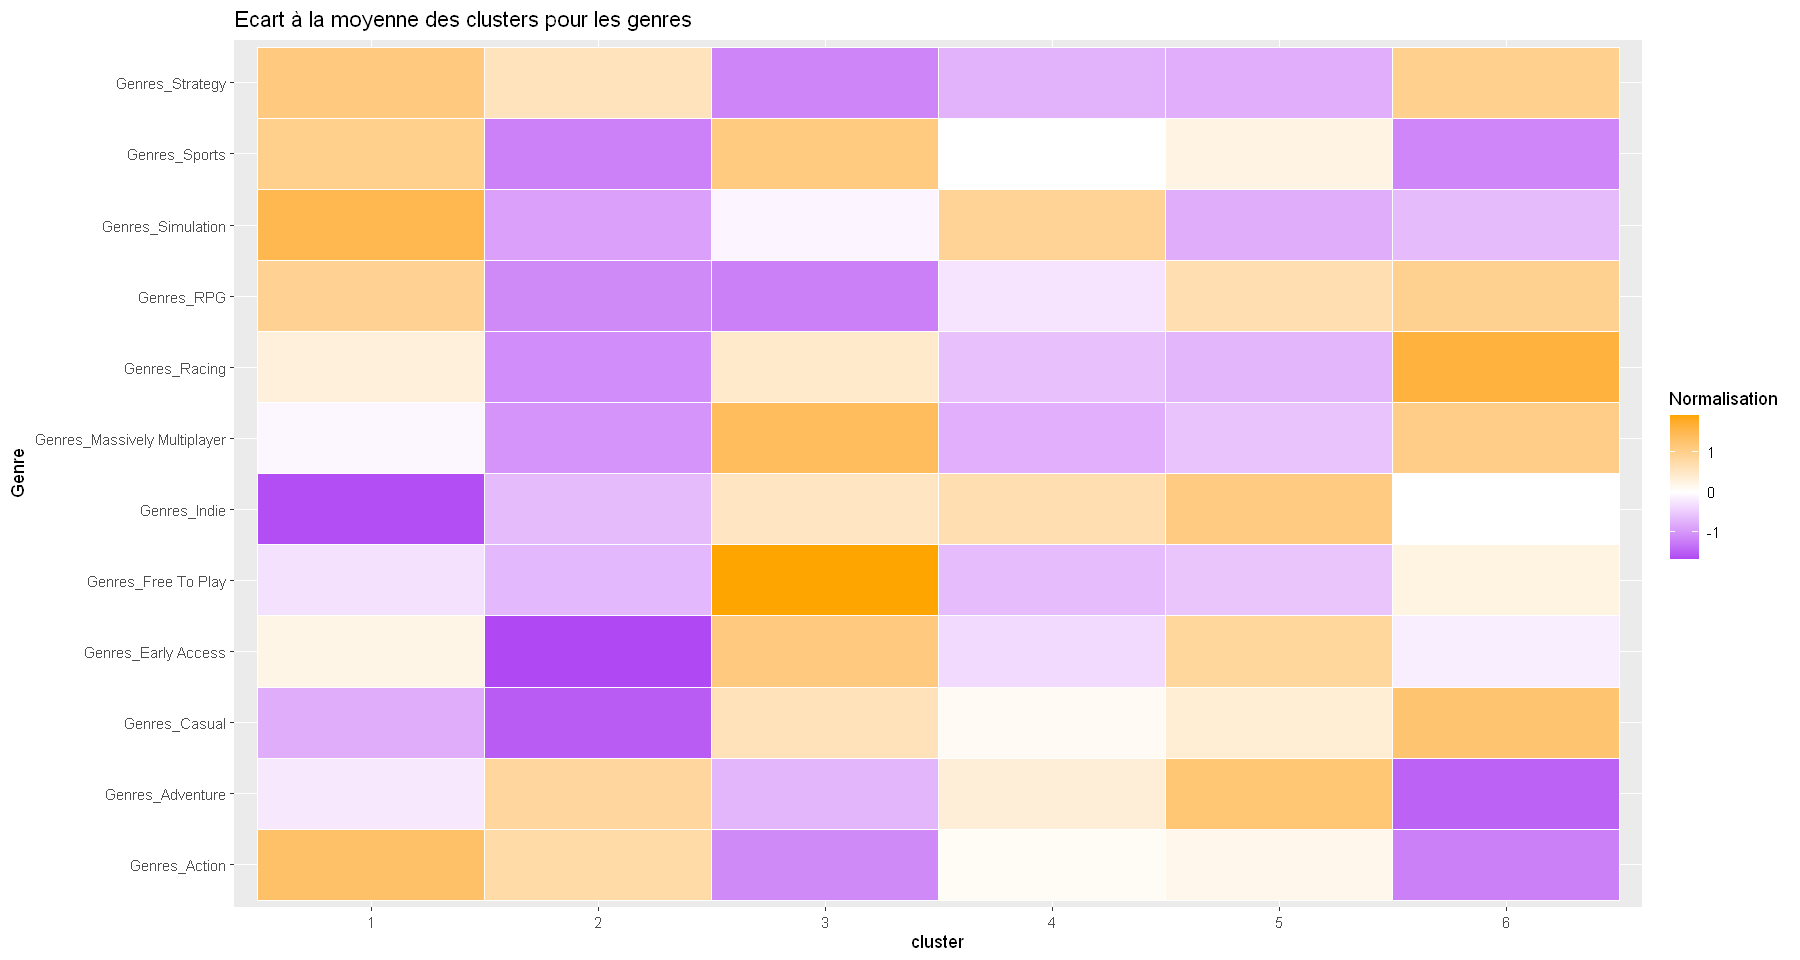

In [131]:
options(repr.plot.width = 15, repr.plot.height = 8)
heatmap <- data.pop.quali %>%
  group_by(cluster) %>%
  summarise(across(starts_with("Genres_"), ~ mean(as.numeric(as.character(.x)), na.rm = TRUE))) #Calcul fréquence des genres pour chaque cluster

heatmap_norm <- heatmap %>%
  mutate(across(-cluster, ~ as.numeric(scale(.)))) %>% #on normalise les fréquences des genres par clusters par rapport à la fréquence des genres pour l'entièreté des jeux
  pivot_longer(cols = -cluster, names_to = "Genre", values_to = "Normalisation")  #pour que ggplot puisse le lire

ggplot(heatmap_norm, aes(x = cluster, y = Genre, fill = Normalisation)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(low = "purple", mid = "white", high = "orange", midpoint = 0) +
  labs(title = "Ecart à la moyenne des clusters pour les genres")

Ce graphique contient beaucoup d'informations, voici ce que l'on retient:

Les genres *Action*, *Simulation* et *Statégie* sont nettement plus présents dans le cluster 1 que dans la moyenne du marché. À l'inverse, le genre *Indie* y est très sous-représenté, ce qui confirme que ce groupe caractérise le succès massif souvent porté par de gros éditeurs.

Le cluster 3 est fortement marqué par le genre *Free To Play*, qui y est bien plus présent que dans les autres groupes. Cette observation est cohérente avec le fait que ce cluster affiche le prix moyen le plus faible de l'échantillon. On remarque également une forte concentration de jeux *Massively Multiplayer*, soulignant une orientation vers des titres accessibles.

Le cluster 6 se positionne presque à l'opposé du cluster 1 avec une faible représentation des genres Aventure, Action et Sports. Ce groupe rassemble principalement des jeux de *Racing*, de *Strategy* et de *Casual*. Ces genres, particulièrement le *Racing* et la *Stratégie*, sont connus pour proposer un très grand nombre d'achievements liés à la progression technique et aux nombreux défis à collectionner. Cela explique mécaniquement le pic d'engagement et le volume de succès observés précédemment pour ce profil de joueurs passionnés.

**Interprétation des clusters par rapport à la variable is_AAA**

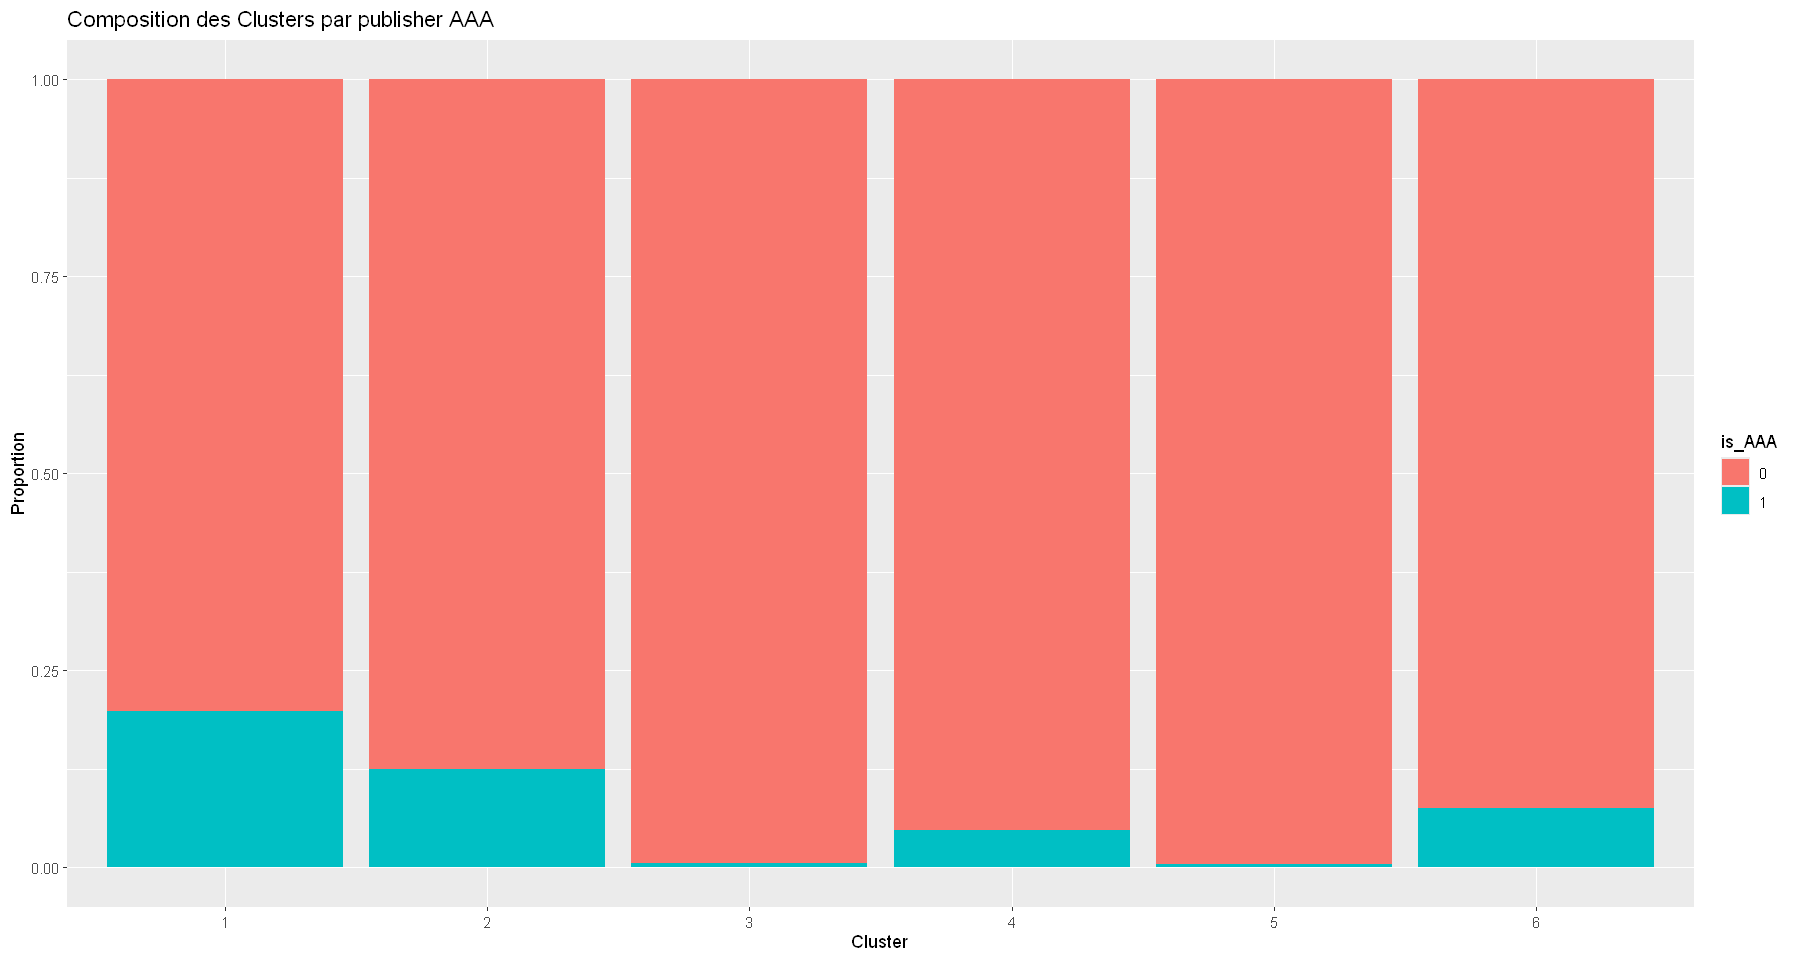

In [132]:
ggplot(data.pop.quali, aes(x = cluster, fill = is_AAA)) +
  geom_bar(position = "fill") + 
  labs(title = "Composition des Clusters par publisher AAA",
       y = "Proportion",
       x = "Cluster")

Ce graphique fait sens car le cluster 1, qui représente les jeux à gros succès, possède une proportion de studios majeurs plus élevée que les autres. À l'inverse, les clusters 3 et 5, qui regroupent les jeux ayant le moins de succès, ont une proportion très faible de jeux publiés par un studio AAA.

Il est cependant étonnant de constater que ces studios sont plus présents dans le cluster 2 que dans le cluster 6. En effet, le cluster 2 est principalement caractérisé par son score Metacritic, alors que le cluster 6 représente plutôt un fort succès d'engagement. Cela pourrait indiquer que les scores Metacritic favorisent les studios AAA. On peut en conclure que ces grands studios ont plus de facilité, et sûrement plus de budget, pour développer des jeux qui rencontrent un véritable succès, qu'il soit populaire ou critique.

**Interprétation des clusters par rapport à la tranche de propriétaires estimés**

Pour identifier quel profil domine chaque niveau de réussite, nous utilisons une heatmap de proportions calculée par tranche de propriétaires. Cette approche est indispensable pour compenser le déséquilibre des effectifs car les jeux à très fort succès sont rares, ils seraient sous-représentés si nous analysions les données globalement. En normalisant par ligne, on s'assure que chaque niveau de succès pèse autant visuellement, ce qui permet de savoir quel cluster capture les jeux au plus gros succès.

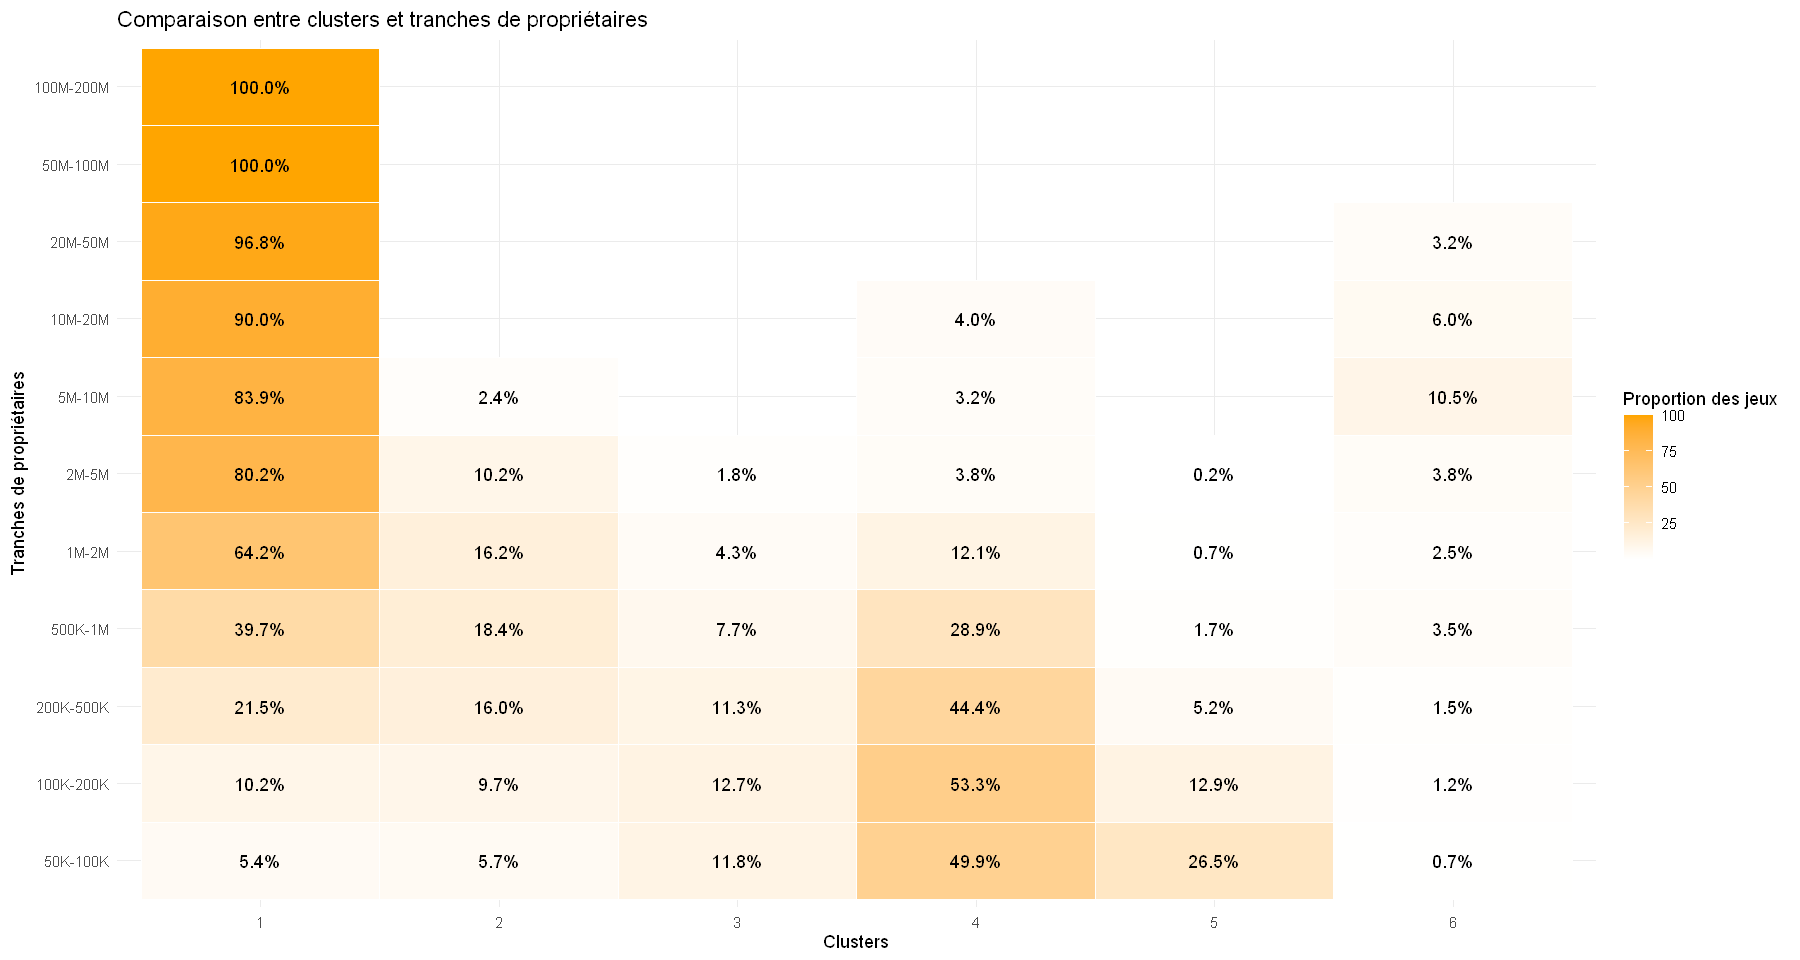

In [133]:
plot_data <- data.pop.quali %>%
  group_by(Estimated.owners, cluster) %>%
  tally() %>%
  group_by(Estimated.owners) %>% #Pour calculer la proportion par tranche de propriétaires
  mutate(pourcentage = (n / sum(n)) * 100)

ggplot(plot_data, aes(x = cluster, y = Estimated.owners, fill = pourcentage)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.1f%%", pourcentage)), color = "black") +
  scale_fill_gradient(low = "white", high = "orange") +
  labs(title = "Comparaison entre clusters et tranches de propriétaires",
       x = "Clusters",
       y = "Tranches de propriétaires",
       fill = "Proportion des jeux" ) +
  theme_minimal()

Cette heatmap confirme nos conclusions sur le cluster 1 en révélant qu'il contient la totalité des jeux dépassant les 50 millions de propriétaires, ainsi que la grande majorité des titres populaires ayant franchi le seuil du million. Cela démontre que les variables de succès (*LPeak.CCU*, *LPositive*, *LNegative*, *LRecommendations*) sont des indicateurs robustes et que les jeux rencontrant un succès massif partagent des caractéristiques communes très marquées.

Il convient toutefois de rester attentif à l'effectif total de chaque groupe. Le cluster 6 ne compte que 212 individus, tandis que le cluster 4 en regroupe plus de 6 000. Cette différence explique pourquoi le cluster 4 affiche des pourcentages élevés dans les tranches basses (50k - 200k): il absorbe la masse des jeux moyens de ce dataset. On remarque d'ailleurs que les jeux ayant les volumes de propriétaires les plus faibles se partagent principalement entre les clusters 3, 4 et 5, ce qui est cohérent avec nos analyses précédentes les définissant comme des groupes à faible visibilité.

Malgré son faible effectif, le cluster 6 possède des parts non négligeables (10,5 % et 6 %) des tranches allant de 5 à 20 millions de propriétaires. Cela prouve que les jeux les plus intensément pratiqués récemment (Playtime two weeks) ne sont pas nécessairement ceux qui comptent le plus grand nombre d'utilisateurs total.

Enfin, le cluster 2 confirme son statut d'entre-deux. S'il ne capte pas les records de vente du cluster 1, il maintient une présence stable dans les tranches de succès modéré (entre 500k et 5M de probriétaires), ce qui corrobore son profil de succès critique.

**Interprétation des clusters par rapport à la date de sortie des jeux**

Pour affiner notre compréhension de la structure des clusters, nous analysons leur composition selon les périodes de sortie des jeux. Voici, leurs effectifs.

In [134]:
data.frame(table(data.pop.quali$Release.date))

Var1,Freq
<fct>,<int>
1997-2013,1424
2014,838
2015,999
2016,1361
2017,1149
2018,1050
2019,919
2020,1284
2021,1293


Contrairement à l'analyse par année, nous choisissons ici de normaliser les données par cluster: chaque colonne totalise 100 %. Nous faisons ce choix car nos groupes ont des effectifs globaux assez équilibrés. Elle permet d'identifier si certains profils de succès (clusters) sont "datés" ou si, au contraire, ils comportent une majorité de jeux plus récents.

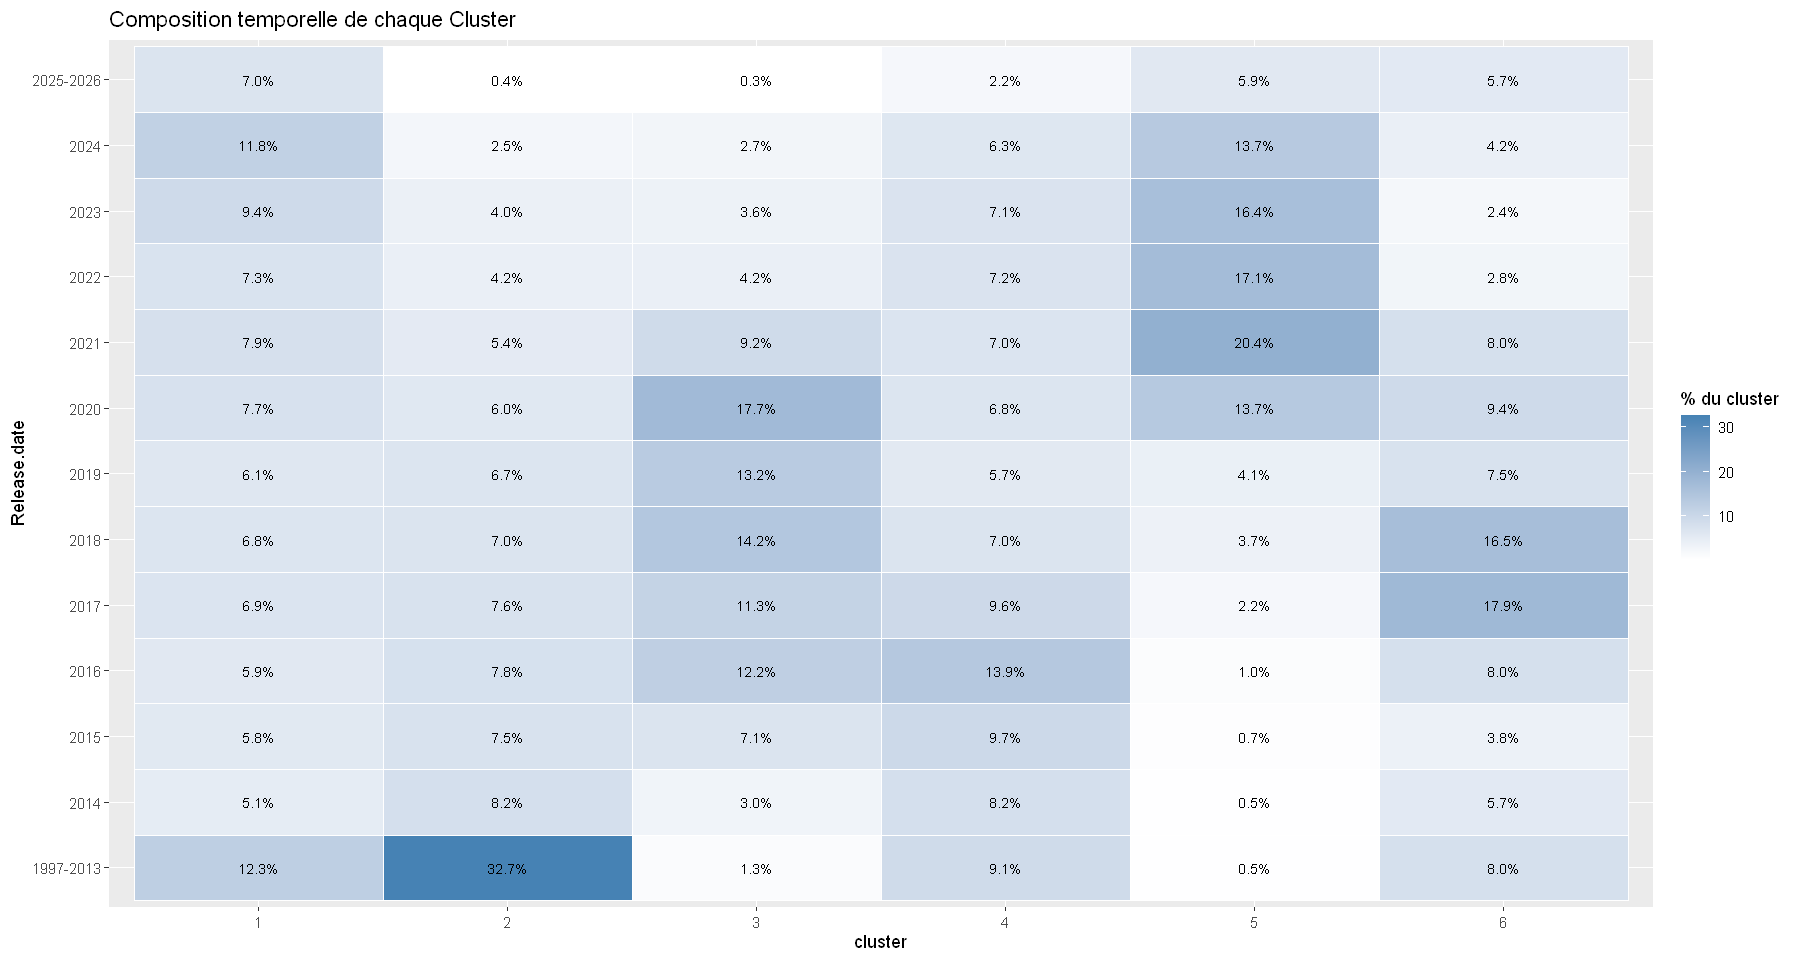

In [135]:
plot_date<- data.pop.quali %>%
  group_by(cluster, Release.date) %>%
  tally() %>%
  group_by(cluster) %>% # On calcule le % au sein de chaque cluster
  mutate(percentage = (n / sum(n)) * 100)

ggplot(plot_date, aes(x = cluster, y = Release.date, fill = percentage)) +
  geom_tile(color = "white") +
  geom_text(aes(label = sprintf("%.1f%%", percentage)), size = 3) +
  scale_fill_gradient(low = "white", high = "steelblue") +
  labs(title = "Composition temporelle de chaque Cluster",
       fill = "% du cluster")

Ce qui ressort le plus c'est l'ancinennté du cluster 2 avec plus d'un tiers de ses jeux sont sortis avant 2013. On peut alors se demander si ce n'était pas plus simple à cette époque d'avoir un score Metacritic. À l'opposé, le clusters 5 apparait comme un groupe très contemporain, avec plus de 85 % de son effectif sortis entre 2020 et 2024. Cette concentration massive dans les années récentes témoigne de la difficulté croissante pour les nouveaux jeux à obtenir un succès massif.

Le cluster 1, qui représente le succès massif, affiche une répartition plus équilibrée à travers le temps, ce qui indique que les jeux les plus populaires viennent de périodes différentes.

#### Conclusion

On rappelle que les deux méthodes testées initialement, la CAH et le GMM, ne construisaient pas les mêmes groupes, ce qui indiquait que nos données n'étaient pas nettement séparables. Néanmoins, en sélectionnant l'approche par GMM, nous avons pu définir des clusters dont les interprétations sont cohérentes. Au final, nous concluons qu'il existe trois types de succès distincts sur Steam :

Le succès massif (Cluster 1): Il regroupe les jeux les plus recommandés, avec un volume d'avis et un nombre de joueurs simultanés record. Paradoxalement, ce ne sont pas les titres affichant le plus long temps de jeu. Ce profil est dominé par de gros studios (AAA) et des genres porteurs comme l'Action, la Simulation et le Sport.

Le succès de temps de jeu (Cluster 6): Ce groupe domine très fortement par son temps de jeu très élevé. Cela s'explique par la nature des jeux qui le composent, principalement de la Stratégie et du Racing, qui possèdent un grand nombre d'achievements et poussent ainsi les joueurs à s'investir sur le long terme.

Le succès médiatique (Cluster 2): Caractérisé par un score Metacritic bien supérieur à la moyenne, ce cluster ne bénéficie pas forcément d'un succès populaire massif. Il rassemble les jeux les plus anciens de la plateforme, souvent publiés par des éditeurs AAA, illustrant un modèle de réussite basé sur la reconnaissance critique historique.

À l'opposé de ces réussites, les autres clusters (3, 4 et 5) illustrent la réalité de la tranche moyenne de la plateforme: des jeux souvent plus récents, majoritairement indépendants, qui peinent à émerger et à obtenir une visibilité suffisante face à la saturation du marché.

## Quel est le profil d'un jeu évalué par la presse spécialisée (le score Metacritic) ?

Le score Métacritic est une note sur 100 représentant la moyenne pondérée des avis de journalistes et médias professionnels. Il accorde plus d'importance aux critiques les plus détaillées et prestigieuses. L'étude 1 sur les types de succès à montré que le cluster 2 est caractérisé par un score métacritic beaucoup plus élevé que la moyenne. Mais, étonnamment ce cluster n'est pas celui le plus marqué par les variables de succès (*Recommendation*, *Positive*, *Negative*, *PeakCCU*). En s'intéressant plus en détail aux jeux avec le plus de propriaitaires estimés n'ont même pas tous un score métacritic (valeur de la variable à 0), seulement 5 jeux sur les 13 ayant de plus 50 millions de propriétaires ont un score. Dans cette partie, en se demander si certaines de nos variables peuvent indiquer la présence de ce score.

**Quelles variables influencent la probabilité pour un jeu d'obtenir une évaluation Metacritic ?**

Pour répondre à cette problématique, on utilise d'abord une régression logistique qui va nous permettre de déterminer des variables explicatives.

Nous nous occupons mainenant de créér le jeu de donnés pour la régression.On choisit de garder des variables qui ne sont pas redondantes comme les *playtimes* (seulement LAverage.playtime.forever) et qui n'ont pas trop de modalités comme *Genres*, *Tags*, *Categories*. On exclut aussi la variable *Window* car seulement 44 jeux ne l'ont pas.

In [137]:
# Création de la variable binaire A_un_score
data_ready <- data_ready %>% mutate(A_un_score = if_else(Metacritic.score > 0, 1, 0))

data_ready$A_un_score <- as.factor(data_ready$A_un_score)

# Sélection des variables explicatives que l'on choisit
data_reglog<- data_ready %>% dplyr::select(A_un_score, LPrice, LLanguageCount, Achievements, Estimated.owners, LPositive, LNegative, Release.date, Required.age, LAverage.playtime.forever, LPeak.CCU, LDLC.count, Discount,Mac, Linux)

### Régression logistique

In [138]:
# On lance le modèle complet
modele_complet <- glm(A_un_score ~ LPrice + LLanguageCount + Achievements + 
                      LDLC.count + LPositive + LNegative + LPeak.CCU  +LAverage.playtime.forever + Estimated.owners
                      + Required.age + Release.date + Discount + Mac+ Linux,
                      data = data_reglog, family = binomial)

Pour sélectionner le modèle optimal, nous avons privilégié le critère BIC. Ce dernier pénalise plus fortement la complexité du modèle, un choix pertinent au vu de notre grand nombre de variables et du grand nombre de modalités pour certaines variables.

In [139]:
# Procédure BIC
modele_BIC <- step(modele_complet, k = log(nrow(data_reglog)),direction = "backward")

Start:  AIC=19187.29
A_un_score ~ LPrice + LLanguageCount + Achievements + LDLC.count + 
    LPositive + LNegative + LPeak.CCU + LAverage.playtime.forever + 
    Estimated.owners + Required.age + Release.date + Discount + 
    Mac + Linux

                            Df Deviance   AIC
- Estimated.owners          13    18641 19083
- Required.age              14    18654 19085
- Linux                      1    18593 19176
- LNegative                  1    18594 19176
<none>                            18593 19187
- Achievements               1    18605 19188
- Mac                        1    18622 19205
- LDLC.count                 1    18676 19259
- LAverage.playtime.forever  1    18690 19272
- LPeak.CCU                  1    18767 19349
- LLanguageCount             1    18867 19450
- Discount                   1    18982 19565
- LPositive                  1    18985 19567
- LPrice                     1    19076 19658
- Release.date              12    20645 21099

Step:  AIC=19083.09
A_u

In [140]:
summary(modele_BIC)


Call:
glm(formula = A_un_score ~ LPrice + LLanguageCount + Achievements + 
    LDLC.count + LPositive + LPeak.CCU + LAverage.playtime.forever + 
    Release.date + Discount + Mac, family = binomial, data = data_reglog)

Coefficients:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -5.5079807  0.1050402 -52.437  < 2e-16 ***
LPrice                     0.5549265  0.0251012  22.108  < 2e-16 ***
LLanguageCount             0.4652300  0.0260724  17.844  < 2e-16 ***
Achievements              -0.0007039  0.0002621  -2.686  0.00724 ** 
LDLC.count                 0.2603240  0.0282443   9.217  < 2e-16 ***
LPositive                  0.5450458  0.0163030  33.432  < 2e-16 ***
LPeak.CCU                 -0.2570629  0.0164927 -15.586  < 2e-16 ***
LAverage.playtime.forever  0.1353100  0.0118636  11.406  < 2e-16 ***
Release.date2014          -1.6296730  0.0917209 -17.768  < 2e-16 ***
Release.date2015          -1.9898622  0.0884644 -22.493  < 2e-16 ***
Releas

On remarque que la variable *Estimated.owners* n'a pas été retenu par la sélection de modèle ce qui confirme notre constat initial (les jeux avec le plus de propriétaires n'ont pas forcément un score).

Les coefficients de la régression expriment l'effet de chaque variable sur les chances que l'événement se produise (ici, avoir un score Metacritic), toutes choses égales par ailleurs. Un coefficient positif indique que la variable augmente la probabilité de présence d'un score, tandis qu'un coefficient négatif la diminue.

De ce fait, on remarque que les variables suivantes ont un effet positif sur la présence d'un score:
- LPrice (0.55): Plus le prix est élevé, plus le jeu a de chances d'être noté.
- LPositive (0.54): Plus un jeu a de reviews positives sur Steam, plus il a de chances d'avoir attiré l'attention de la presse.
- LLanguageCount (0.45): Un jeu traduit en beaucoup de langues est plus susceptible d'être évalué. C'est aussi un indicateur de l'investissement et du budget par l'éditeur, car la localisation d'un titre représente un coût financier important.


On observe aussi des freins:
- Release.date (Tous négatifs et très forts): La modalité de référence est la période la plus ancienne: 1997-2013. Le fait que tous les coefficients soient négatifs et de plus en plus intenses signifie que plus on avance dans le temps, moins un jeu a de chances d'avoir un score Metacritic. On peut potentiellement expliquer cela par l'explosion du nombre de jeux sur Steam au fil des années qui intensifie donc la concurrence pour obtenir une note. Cela rendrait l'obtention d'une note de plus en plus sélective au fil des années.
- Le coefficient négatif de LPeak.CCU (-0,27) suggère que les jeux avec des pics de joueurs simultanés très élevés ne sont pas forcément les cibles privilégiées des critiques.

In [141]:
cbind(Odds_Ratio = exp(modele_BIC$coefficients))

,Odds_Ratio
(Intercept),0.004054286
LPrice,1.741813023
LLanguageCount,1.592380374
Achievements,0.999296364
LDLC.count,1.297350404
LPositive,1.724687353
LPeak.CCU,0.773319600
LAverage.playtime.forever,1.144891665
Release.date2014,0.195993648
Release.date2015,0.136714266


L'analyse des Odds Ratios permet de quantifier l'impact réel des variables sur la probabilité pour un jeu d'obtenir un score Metacritic. Puisque les variables de performance et de prix sont exprimées en échelle logarithmique, une unité supplémentaire correspond ici à une multiplication de la valeur réelle par environ 2,7.

L'effet le plus puissant est temporel : le simple fait de sortir un jeu en 2024 divise les chances d'obtenir un score par près de 50 ($OR \approx 0,02$) par rapport à la période de référence.

L'effet positif le plus marqué parmi les variables est celui de LPrice, avec un ratio de 1,74. Concrètement, cela signifie qu'à caractéristiques égales, chaque multiplication du nombre de reviews positives par 2,71 (augmentation de une unité sur $Log(Price)$) entraîne une multiplication des chances d'obtenir un score Metacritic par 1,74 (soit une hausse de 74 %). Les variables LLanguageCount et LPositive ont aussi un fort effet positif sur les chances d'obtenir un score Metacritic.



### Prédiction par LDA

Nous décidons aussi d'utiliser une LDA pour prédire si oui ou non un jeu possède un score Metacritic. Il s'agit de la seule méthode supervisée étudiée cette année.

La méthode étant supervisée, il est nécessaire de séparer en train et tester le dataset. Ici, notre target sera donc si Metacritic a attribué une note au jeu (ou pas).

In [148]:
LDA_train_test <- function(data_lda) {
  set.seed(42)
  
  n <- nrow(data_lda)
  train_index <- sample(seq_len(n), size = floor(0.7 * n)) # split train test
  
  train_data <- data_lda[train_index, ]
  test_data  <- data_lda[-train_index, ]
  
  clf <- lda(A_un_score ~ ., data = train_data)
  
  train_pred <- predict(clf, train_data)$class
  test_pred  <- predict(clf, test_data)$class
  
  train_accuracy <- mean(train_pred == train_data[["A_un_score"]])
  test_accuracy  <- mean(test_pred == test_data[["A_un_score"]])
  
  cat("--- Linear Discriminant Analysis ---\n\n")
  cat(sprintf("Train accuracy: %.2f%%\n", train_accuracy * 100))
  cat(sprintf("Test accuracy:  %.2f%%\n\n", test_accuracy * 100))
  
  cm <- confusionMatrix(test_pred, test_data[["A_un_score"]], positive = "1")
  
  print(cm$table)
}

In [149]:
data_lda <- data_reglog

LDA_train_test(data_lda = data_lda)

--- Linear Discriminant Analysis ---

Train accuracy: 96.07%
Test accuracy:  96.02%

          Reference
Prediction     0     1
         0 32340   636
         1   731   647


La prédiction ici est très intéressante, le modèle n'est pas overfit (accuracy similaire sur train et test) mais la précision est hétérogène.

La précision globale (96%) est trompeuse à cause du fort déséquilibre des données (96% des jeux n'ont pas de score Metacritic), cependant l'analyse du score de la classe minoritaire (les jeux avec un score) est importante car, si les variables de notre dataset n'avaient aucune influence, le modèle n'aurait détecté au hasard que 4% des jeux notés. 

Ici, il parvient à en identifier correctement la moitié (647 sur 1283, soit une précision de 50,4%). Cela prouve que le modèle à bien réussi à extraire une partie de l'information et fait mieux que de l'aléatoire pur. Le modèle n'est cependant pas meilleur qu'un lancer de pièce lorsqu'il prédit qu'un jeu possède un score Metacritic. 